<a href="https://colab.research.google.com/github/angelrecalde2024/Power-Distribution-Design-and-Management/blob/main/INGP1120_Distribution_ReliabilityAnalysis_static_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Distribution Reliability Analysis

    Designed and developed by Dr. Angel Recalde

In this analysis, we restrict usage networks with head recloser and multiple fuses across the distribution system, as usually found in urban/rural networks.  

The reliability model is formulated using three topological states of the feeder. The base tree represents normal operation. The momentary tree represents the topology during the initial protective action, typically after the first recloser trip. The permanent tree represents the topology after the final protective device has isolated a permanent fault. Reliability impacts are then determined from the set of service points disconnected from the source in each state.

### METHOD 1 (LOCAL ECUATORIAN REGULATION ARCERNNR 002/20)

We first determine the feeder type using total installed distribution-transformer nominal kVA divided by total feeder length in km, considering all 3-phase, 2-phase, and 1-phase primary segments. Then, for each interruption event in the study period, we identify the nominal kVA interrupted and the interruption duration. Applying the regulatory filter, we count only interruptions longer than 3 minutes and exclude the categories listed in the regulation. After that, we compute the per-event contributions and sum them over the period to obtain feeder-level FMIK and TTIK. The denominator is the total installed nominal kVA of the feeder at the time of interruption, while the numerator uses the interrupted installed kVA and duration.

The main technical difficulty in Method 1 is determining, for each event, which installed transformer kVA is out of service. Since customers are served at transformer secondaries and transformers are located on buses, the cleanest feeder-level proxy is: a transformer is interrupted if its primary connection point becomes de-energized by the upstream failed segment and protection operation. Then its nominal kVA contributes to interrupted kVA. For MV loads connected directly to the feeder, we include them as “customers/load points,”For the regulatory FMIK/TTIK, the natural basis is installed distribution-transformer nominal kVA, exactly as the regulation states, so MV loads should not distort that denominator unless the regulation explicitly says otherwise.

### METHOD 2 (CLASSICAL RELIABILITY ANALYSIS)

we use the standard load-point approach. We define each load point, estimate for each one its annual failure rate $\lambda_i$, annual outage duration $U_i$, and average repair/restoration time $r_i=U_i/\lambda_i$, then aggregate to system SAIFI, SAIDI, CAIFI, CAIDI, and ENS.

Here the key modeling decision is what counts as a load point. The technically consistent choice is:

* each distribution transformer secondary service point can be treated as a load point representing all LV customers connected to that transformer secondary,

* each MV load can be treated as an independent load point,

* the number of customers at a transformer can be inferred from the number of OpenDSS load objects attached to that transformer secondary,

That last point matters a lot. Reliability indices such as SAIFI and SAIDI are customer-based, not kVA-based. We shoudl have an external customer database. In this case, one OpenDSS load object equals one customer connection. If several load objects belong to the same transformer secondary, then that transformer supplies multiple customers.

On component reliability data, since we do not have historical failure rates, we propose an academic simplification. We should assign statistical models to line segments and transformers. For a first version, the best choice is the exponential model with constant failure rate because it is standard, transparent, and analytically simple. In that case, each component has:

* a constant annual failure rate $𝜆_i$
* a repair/restoration time distribution, which could initially be deterministic or average-value based,
* optional Monte Carlo later, if we want stochastic annual simulations.

PROTECTION LOGIC

* A temporary fault anywhere causes a fast recloser operation and momentary interruption upstream/downstream depending on location; we are applying the regulation filter of more than 3 minutes, then, those momentary events will usually be excluded anyway.

* For permanent faults on a fused lateral or downstream fused section, the recloser first trips and recloses, then the fuse isolates the permanent faulted section, and only the customers inside that fused section remain interrupted for repair time; the rest of the feeder is restored after switching/reclosing time.

* For permanent faults on the main trunk before any protective coordination isolation, all downstream customers affected by the opened device remain interrupted until repair or switching restoration.


This means the reliability engine must classify the consequence of each failed segment into at least two restoration layers:

* customers that suffer only a temporary or short interruption due to protective operation,
* customers that remain de-energized until repair because they lie inside the isolated failed section,
* optionally, customers restored after switching but before full repair, if we want to distinguish switching time from repair time.

That last distinction is important because SAIDI and ENS are sensitive to restoration time assumptions. Even with a simple model, we separate protection-clearing time / reclosing time / switching restoration time / repair time conceptually.


MODEL STRUCTURE

* `Lines_MV.dss` defines the primary feeder graph through `bus1`, `bus2`, `length`, and line name.
* `Transformers_MVLV.dss` defines the MV/LV service transformers, each attached to one primary bus and one secondary bus.
* `Loads_MV.dss` lets us identify whether a load is connected directly to an MV bus or to a transformer secondary bus. Since each load declaration corresponds to one customer, the customer count rule is now clear.
* `Fuses_MV.dss` identifies line sections protected by fuse devices
* `Reclosers.dss` identifies the head-end protective device.


## Proposed Reliability Methodology

There are 3 layers

### Layer 1: Network and service model extraction

From OpenDSS model, we must build these engineering objects:

* Primary Feeder Graph: each MV line segment is an edge (upstream bus, downstream bus, length in km, phase count, line name, whether it is fuse protected, whether it is controlled by the head recloser, installation type if know later, such as overhead or underground). This graph will define fault propagation and interruption zones.

* Transformer service points: Each MV/LV transformer is a service aggregation node (transformer name, primary MV bus, secondary LV bus, nominal kVA from transformer code, number of customer connected at the secondary, total connected load at the secondary, optionally customer classes if you later want residential/commercial summaries). For local regulation, the transformer nominal kVA is central because feeder type and FMIK/TTIK are based on installed transformer kVA.

* Load points for standard reliability indices: For SAIDI/SAIDI/CAIFI/CAIDI/ENS, the load points comes from each transformer secondary service point, each MV load bus, treated as one load point unless multiple MV load declarations are present at the same bus. For each load point we store: number of customers, connected kW and optionally kVA, associated upstream protection path, associated transformer (if applicable).

### Layer 2: Fault-impact logic

This is the heart of the study. For each failed component, we must determine who loses supply, for how long, and under which interruption category. We will analyze components outages of: line segments, distribution transformers, fuses, recloser.

* Failure of a line segment: a line failure must be evaluated according to its protection context. If a fault on a fused lateral or fused protected section occurs, there are 2 effects: 1) momentary or short interruption effect (all customers downstream of the head recloser may experience a short interruption due to the first trip/reclose sequence), 2) sustained interruption effect (only the customers inside the isolated fused section remain out of service for repair time. If a fault on an unfused main trunk sections occurs: if the failed segment is on the main feeder and not isolated by a downstream fuse, then all downstram load points lose supply (customers remain interrupted for the repair or switching-restoration time associated with that failure.

* Failure of a distribution transformer: A transformer outage affects the LV loads connected to its secondary bus. It does not affect other transformers or other primary feeder sections. For Method 1 (ecuatorian regulation), the interrupted installed kVA due to transformer failure is simply the nominal kVA of that transformer, provided the interruption qualifies under the local regulation filter. For Method 2 (classical reliability indices), the affected customers are those load declarations connected to that transformer secondary, the affected demand is the sum of those loads, ENS uses the corresponding interrupted power.

* Fuse operation: sustained open failure of the fuse device itself affects the downstream protected section. Customers downstream remain interrupted for fuse replacement/restoration time. No model of a fuse failure is modelled.

* Recloser operation: Recloser operates with fast and slow shots. No model of recloser failure is modelled.

**Method 1: local-regulation indices**

1. Determine the feeder type.

$$
TA=\frac{\mathrm{total\ installed\ distribution\ transformer\ nominal\ kVA}}{\mathrm{total\ feeder\ length\ in\ km}}\
$$

Using all MV/LV distribution transformers for installed kVA, all line segments, whether 3-phase, 2-phase, or 1-phase for total feeder length. Then, we classify as low density if TA < 50, or high density if TA >= 50.

2. Define interruption eligibility

Only interruptions longer than 3 minutes are counted, including scheduled and unscheduled, internal and external, except the exclusions listed in the regulation.

Since this uses analytical model rather than historical event auditing, we implement this through event flags: scheduled vs unscheduled, internal vs external, duration in minutes, excluded vs not included.

In this version, the essential regulatory filter considers: keep only events with duration > 3 min, allow binary option to include or exclude scheduled interruptions, ignore force majeure and special exclusions unless the user manually tags them.

3. Compute interrupted installed kVA per event.

For each qualifying event, we determine which transformers are de-energized, sum their nominal kVA, and obtain the installed nominal kVA for the event.

4. Compute event contribution to FMIK and TTIK.

For each event, the frequency contribution is interrupted kVA divided by total installed feeder kVA, and time contribution is interrupted kVA multiplied by outage duration divided by total installed feeder kVA. Then sum all qualifying event over the study period to obtain feeder FMIK and TTIK. The regulation gives annual admissible feeder limits depending on feeder density.

NOTE: for fused-section permanent faults, the brief first-shot interruption of the whoe feeder is typically below 3 minutes, there, under Method 1 it will usually not count, only the sustained interruption of the isolated fused section will contribute.

**Method 2: standard reliability indices**

This is the classical utility reliability framework.

For each load point $i$, we compute annual failure rate $\lambda_i$, annual outage duration $U_i$, and average outage time $r_i=U_i/λ_i$, when $\lambda_i > 0$

These come from summing contributions of all components whose failure interrupts that load point.

If component $j$ affects load point $i$, then:

$$
\lambda_i=\sum_{j}\lambda_j\mathrm{}\delta_{ij}\
$$
$$
U_i=\sum_{j}
\lambda_j\mathrm{} r_{ij}\mathrm{}\delta_{ij}
$$

Where $λ_j$ is the component failure rate, $r_{ij}$ is the outage duration seen at load point $i$ when component $j$ fails, $δ_{ij} = 1$ if component $j$ causes interruption at load point $i$, else 0. This is the standard analytical load-point reliability structure.

Then, using customer count $N_i$ and connected demand $P_i$:

$$
SAIFI=\frac{\sum_{i}\lambda_iN_i}{\sum_{i} N_i}\
$$
$$
SAIDI=\frac{\sum_{i} U_iN_i}{\sum_{i} N_i}\
$$
$$
CAIFI=\frac{\sum_{i}\lambda_iN_i}{\sum_{i\in A} N_i}
$$

Where $A$ is the set of interrupted customers in the study period or expected interrupted-customer basis.
$$
CAIDI=\frac{SAIDI}{SAIFI}\
$$
$$
ENS=\sum_{i} U_iP_i
$$

With ENS in kWh/year if $U_i$ is in hours/year and $P_i$ is in kW.

We have 2 subcases, Local Restrictions Applied, and Unrestricted. In the former case, we count only interruptions whose durations > 3 minutes, plus the chosen event flags for scheduled/unscheduled and exclusions. In the latter, we count every interruption, even 1 minute or momentary events. This means the same component-failure matrix is reused, but the event-filter rule changes.

RELIABILITY DATA LIBRARY

For MV overhead line, Use a constant failure rate per km-year:
$$
\lambda_{\mathrm{line}}=\lambda_{\mathrm{OH}}\cdot L\
$$
where $L$ is segment length in km.

For MV underground lines,
$$
\lambda_{\mathrm{UG\ line}}=\lambda_{\mathrm{UG}}\cdot L\
$$

For distribution transformers, use a constant annual failure rate:
$$
\lambda_{\mathrm{tx}}=\mathrm{constant\ per\ unit-year}\
$$

For fuses, use a constant annual failure rate:
$$
\lambda_{\mathrm{fuse}}=\mathrm{constant\ per\ device-year}\
$$

For reclosers, use a constant annual failure rate:
$$
\lambda_{\mathrm{rec}}=\mathrm{constant\ per\ device-year}\
$$

For restoration times, we have 4 distinct average times.
* temporary recloser interruption duration
* fuse-operation isolation/restoration duration for upstream customers
* repair time for permanent line failures
* repair time for transformer failures
* replacement/restoration time for fuse and recloser device failures.

GOOGLE DRIVE MOUNT AND STUDY FOLDER SETUP

In [35]:
# ============================================================
# CELL 1 - GOOGLE DRIVE MOUNT AND STUDY FOLDER SETUP
# ============================================================
# This cell mounts Google Drive and defines the folder where
# the OpenDSS feeder files are stored.
#
# Edit only the FEEDER_FOLDER variable to point to the folder
# that contains:
#   Master.dss
#   Lines_MV.dss
#   Transformers_MVLV.dss
#   Loads_MV.dss
#   Fuses_MV.dss   (or Fuses_MV.dss / Fuses.dss)
#   Reclosers_MV.dss
#   XfmrCodes.dss
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# ------------------------------------------------------------
# USER INPUT: change this path to your feeder folder in Drive
# ------------------------------------------------------------
FEEDER_FOLDER = Path("/content/drive/MyDrive/CNEL_Anconcito2024")
# FEEDER_FOLDER = Path("/content/drive/MyDrive/IEEE_RBTS_distribution_1996")

# ------------------------------------------------------------
# Standard file names expected in the feeder folder
# You may change them here if a feeder uses different names
# ------------------------------------------------------------
FILE_NAMES = {
    "master": "Master.dss",
    "lines": "Lines_MV.dss",
    "xfmr_codes": "XfmrCodes.dss",
    "transformers": "Transformers_MVLV.dss",
    "loads": "Loads_MV.dss",
    "fuses": "Fuses_MV.dss",
    "reclosers": "Reclosers_MV.dss",
}

print("Feeder folder selected:")
print(FEEDER_FOLDER)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Feeder folder selected:
/content/drive/MyDrive/CNEL_Anconcito2024


In [36]:
# ============================================================
# CELL 2 - IMPORTS
# ============================================================
# General imports used in Phase 1:
# - file handling
# - regular expressions
# - data manipulation
# - display utilities
# ============================================================

import os
import re
import math
import json
import textwrap
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd

# Display options for easier inspection in Colab
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 200)


# ============================================================
# CELL 3 - FILE VALIDATION AND COMMON UTILITIES
# ============================================================
# This cell:
# 1) validates that the required feeder files exist
# 2) defines common helper functions for text parsing
# 3) defines bus-name normalization helpers
# ============================================================

def validate_required_files(base_folder: Path, file_names: dict) -> dict:
    """
    Validate that all required files exist in the feeder folder.
    Returns a dictionary with full file paths.
    Raises FileNotFoundError if any required file is missing.
    """
    if not base_folder.exists():
        raise FileNotFoundError(f"Feeder folder does not exist: {base_folder}")

    file_paths = {}
    missing = []

    for key, fname in file_names.items():
        fpath = base_folder / fname
        file_paths[key] = fpath
        if not fpath.exists():
            missing.append(str(fpath))

    if missing:
        msg = "The following required files were not found:\n" + "\n".join(missing)
        raise FileNotFoundError(msg)

    return file_paths


def read_text_file(path: Path) -> str:
    """
    Read a text file robustly.
    Uses latin-1 fallback because utility DSS files sometimes contain
    non-UTF characters.
    """
    try:
        return path.read_text(encoding="utf-8")
    except UnicodeDecodeError:
        return path.read_text(encoding="latin-1")


def remove_inline_comment(line: str) -> str:
    """
    Remove OpenDSS inline comment starting with '!' and strip spaces.
    """
    return line.split("!")[0].strip()


def is_new_element_line(line: str) -> bool:
    """
    Return True if the line starts with 'New ' (case-insensitive).
    """
    return bool(re.match(r"^\s*new\s+", line, flags=re.IGNORECASE))


def normalize_spaces(text: str) -> str:
    """
    Collapse repeated whitespace into a single space.
    """
    return re.sub(r"\s+", " ", text).strip()


def normalize_bus_token(bus: str) -> str:
    """
    Normalize a raw bus token:
    - strip spaces
    - convert to uppercase
    """
    if bus is None:
        return None
    return bus.strip().upper()


def strip_phase_suffix(bus: str) -> str:
    """
    Convert a bus like:
        mta_s_23283.3.0  -> MTA_S_23283
        MTA_L_29103.1.0 -> MTA_L_29103
        MTA_S_100.1.2.3 -> MTA_S_100

    This keeps the base bus name only.
    """
    if bus is None:
        return None
    bus = normalize_bus_token(bus)
    return bus.split(".")[0]


def extract_key_value_pairs(text: str) -> dict:
    """
    Extract key=value pairs from an OpenDSS declaration line.

    Important:
    - Handles values with brackets, e.g. Buses=[A B]
    - Handles simple tokens like phases=1
    - Keys are returned in lowercase
    """
    pairs = {}

    # First capture bracketed values like buses=[A B]
    bracket_pattern = re.compile(r"(\w+)\s*=\s*(\[[^\]]*\])", flags=re.IGNORECASE)
    consumed_spans = []

    for m in bracket_pattern.finditer(text):
        key = m.group(1).lower()
        val = m.group(2).strip()
        pairs[key] = val
        consumed_spans.append((m.start(), m.end()))

    # Remove bracketed matches before extracting simpler tokens
    cleaned = text
    for start, end in reversed(consumed_spans):
        cleaned = cleaned[:start] + " " * (end - start) + cleaned[end:]

    # Capture normal key=value tokens
    token_pattern = re.compile(r"(\w+)\s*=\s*([^\s]+)", flags=re.IGNORECASE)
    for m in token_pattern.finditer(cleaned):
        key = m.group(1).lower()
        val = m.group(2).strip()
        pairs[key] = val

    return pairs


def extract_new_element_name(line: str) -> tuple:
    """
    Extract the OpenDSS class and object name from a line like:
        New Line.N_23283_MTA ...
        New Transformer.T_29103_MTA ...

    Returns:
        (class_name, object_name)
    Example:
        ('line', 'N_23283_MTA')
    """
    line_clean = remove_inline_comment(line)
    m = re.match(r"^\s*new\s+([^.]+)\.([^\s]+)", line_clean, flags=re.IGNORECASE)
    if not m:
        return None, None
    return m.group(1).strip().lower(), m.group(2).strip()


# ------------------------------------------------------------
# Validate files now
# ------------------------------------------------------------
FILE_PATHS = validate_required_files(FEEDER_FOLDER, FILE_NAMES)

print("All required files were found.\n")
for key, path in FILE_PATHS.items():
    print(f"{key:15s} -> {path}")


# ============================================================
# CELL 4 - PARSER FOR LINES_MV.DSS
# ============================================================
# This cell parses MV line declarations and returns a DataFrame.
# It keeps both raw bus names and normalized base bus names.
# ============================================================

def parse_lines_file(path: Path) -> pd.DataFrame:
    """
    Parse Lines_MV.dss into a DataFrame with one row per line segment.
    """
    text = read_text_file(path)
    rows = []

    for raw_line in text.splitlines():
        line = remove_inline_comment(raw_line)
        if not line or not is_new_element_line(line):
            continue

        cls, obj_name = extract_new_element_name(line)
        if cls != "line":
            continue

        kv = extract_key_value_pairs(line)

        bus1_raw = kv.get("bus1")
        bus2_raw = kv.get("bus2")

        row = {
            "line_name": obj_name.upper(),
            "line_full_name": f"LINE.{obj_name.upper()}",
            "bus1_raw": normalize_bus_token(bus1_raw),
            "bus2_raw": normalize_bus_token(bus2_raw),
            "bus1_base": strip_phase_suffix(bus1_raw),
            "bus2_base": strip_phase_suffix(bus2_raw),
            "phases": pd.to_numeric(kv.get("phases"), errors="coerce"),
            "length_km": pd.to_numeric(kv.get("length"), errors="coerce"),
            "units": kv.get("units"),
            "geometry": kv.get("geometry"),
            "linecode": kv.get("linecode"),
            "raw_line": raw_line.strip(),
        }
        rows.append(row)

    df = pd.DataFrame(rows)

    if not df.empty:
        df["units"] = df["units"].fillna("").str.lower()
        # If in the future you find feeders with units different from km,
        # we can convert them here. For now, your files use km.
        non_km = df.loc[(df["units"] != "") & (df["units"] != "km"), "units"].unique().tolist()
        if non_km:
            print("Warning: some line units are not km:", non_km)

    return df


lines_df = parse_lines_file(FILE_PATHS["lines"])

print("Parsed lines_df:")
display(lines_df.head(10))
print(f"\nTotal line segments parsed: {len(lines_df)}")


# ============================================================
# CELL 5 - PARSER FOR XFMRCODES.DSS  (CORRECTED)
# ============================================================
# This cell parses transformer codes.
# In this feeder, transformer ratings appear as:
#     kVAs=[15 15]
# We use ONLY the first value as the nominal transformer kVA.
# ============================================================

def parse_bracket_number_list(val):
    """
    Convert a bracketed OpenDSS list like:
        [15 15]
        [7.96 0.138564]
    into a Python list of floats.

    Returns an empty list if parsing fails.
    """
    if val is None:
        return []

    val = str(val).strip()
    if val.startswith("[") and val.endswith("]"):
        inner = val[1:-1].strip()
        if not inner:
            return []
        parts = inner.split()
        out = []
        for p in parts:
            try:
                out.append(float(str(p).replace(",", "")))
            except ValueError:
                pass
        return out

    # Fallback: single numeric token
    try:
        return [float(str(val).replace(",", ""))]
    except ValueError:
        return []


def parse_xfmr_codes_file(path: Path) -> pd.DataFrame:
    """
    Parse XfmrCodes.dss into a DataFrame with one row per transformer code.

    Important for this feeder:
    - kVAs=[nominal emergency]
    - We use ONLY the first value as nominal_kva
    """
    text = read_text_file(path)
    rows = []

    for raw_line in text.splitlines():
        line = remove_inline_comment(raw_line)
        if not line or not is_new_element_line(line):
            continue

        cls, obj_name = extract_new_element_name(line)
        if cls != "xfmrcode":
            continue

        kv = extract_key_value_pairs(line)

        # Recover bracketed rating lists
        kva_list = parse_bracket_number_list(kv.get("kvas"))
        kvs_list = parse_bracket_number_list(kv.get("kvs"))

        nominal_kva = kva_list[0] if len(kva_list) >= 1 else np.nan
        emergency_kva = kva_list[1] if len(kva_list) >= 2 else np.nan

        row = {
            "xfmr_code": obj_name.upper(),
            "phases": pd.to_numeric(kv.get("phases"), errors="coerce"),
            "windings": pd.to_numeric(kv.get("windings"), errors="coerce"),
            "kvas_raw": kv.get("kvas"),
            "kva_list": kva_list,
            "nominal_kva": nominal_kva,
            "emergency_kva": emergency_kva,
            "kvs_raw": kv.get("kvs"),
            "kvs_list": kvs_list,
            "hv_kv": kvs_list[0] if len(kvs_list) >= 1 else np.nan,
            "lv_kv": kvs_list[1] if len(kvs_list) >= 2 else np.nan,
            "conns": kv.get("conns"),
            "xhl": pd.to_numeric(kv.get("xhl"), errors="coerce"),
            "raw_line": raw_line.strip(),
        }
        rows.append(row)

    return pd.DataFrame(rows)


xfmr_codes_df = parse_xfmr_codes_file(FILE_PATHS["xfmr_codes"])

print("Parsed xfmr_codes_df:")
display(xfmr_codes_df.head(10))

print(f"\nTotal transformer codes parsed: {len(xfmr_codes_df)}")
print(f"Transformer codes with nominal_kva found: {xfmr_codes_df['nominal_kva'].notna().sum()}")
print(f"Total nominal transformer-code kVA entries recovered: {xfmr_codes_df['nominal_kva'].sum():,.3f}")


# ============================================================
# CELL 6 - PARSER FOR TRANSFORMERS_MVLV.DSS
# ============================================================
# This cell parses transformer declarations and attaches nominal
# kVA from XfmrCodes.dss.
# ============================================================

def parse_transformers_file(path: Path, xfmr_codes_df: pd.DataFrame) -> pd.DataFrame:
    """
    Parse Transformers_MVLV.dss into a DataFrame with one row per transformer.
    """
    code_to_kva = {}
    if not xfmr_codes_df.empty:
        code_to_kva = dict(zip(xfmr_codes_df["xfmr_code"], xfmr_codes_df["nominal_kva"]))

    text = read_text_file(path)
    rows = []

    for raw_line in text.splitlines():
        line = remove_inline_comment(raw_line)
        if not line or not is_new_element_line(line):
            continue

        cls, obj_name = extract_new_element_name(line)
        if cls != "transformer":
            continue

        kv = extract_key_value_pairs(line)

        buses_raw = kv.get("buses", "")
        buses_list = []
        if buses_raw.startswith("[") and buses_raw.endswith("]"):
            buses_list = buses_raw[1:-1].split()

        primary_bus_raw = buses_list[0] if len(buses_list) >= 1 else None
        secondary_bus_raw = buses_list[1] if len(buses_list) >= 2 else None

        xfmr_code = normalize_bus_token(kv.get("xfmrcode"))  # only to upper-case token
        section_match = re.search(r"SectionID\s*=\s*([^\s!]+)", raw_line, flags=re.IGNORECASE)
        section_id = section_match.group(1).strip() if section_match else None

        row = {
            "transformer_name": obj_name.upper(),
            "transformer_full_name": f"TRANSFORMER.{obj_name.upper()}",
            "xfmr_code": xfmr_code,
            "primary_bus_raw": normalize_bus_token(primary_bus_raw),
            "secondary_bus_raw": normalize_bus_token(secondary_bus_raw),
            "primary_bus_base": strip_phase_suffix(primary_bus_raw),
            "secondary_bus_base": strip_phase_suffix(secondary_bus_raw),
            "nominal_kva": code_to_kva.get(xfmr_code, np.nan),
            "taps": kv.get("taps"),
            "section_id": section_id,
            "raw_line": raw_line.strip(),
        }
        rows.append(row)

    df = pd.DataFrame(rows)
    return df


transformers_df = parse_transformers_file(FILE_PATHS["transformers"], xfmr_codes_df)

print("Parsed transformers_df:")
display(transformers_df.head(10))
print(f"\nTotal transformers parsed: {len(transformers_df)}")
print(f"Transformers with nominal_kva recovered: {transformers_df['nominal_kva'].notna().sum()}")
print(f"Total installed transformer nominal kVA: {transformers_df['nominal_kva'].sum():,.3f}")


# ============================================================
# CELL 7 - PARSER FOR LOADS_MV.DSS
# ============================================================
# This cell parses load declarations.
# Each load declaration is treated as one customer declaration
# unless n_customers says otherwise.
# ============================================================

def parse_loads_file(path: Path) -> pd.DataFrame:
    """
    Parse Loads_MV.dss into a DataFrame with one row per load declaration.
    """
    text = read_text_file(path)
    rows = []

    for raw_line in text.splitlines():
        line = remove_inline_comment(raw_line)
        if not line or not is_new_element_line(line):
            continue

        cls, obj_name = extract_new_element_name(line)
        if cls != "load":
            continue

        kv = extract_key_value_pairs(line)

        # These fields may appear after the comment marker in your files,
        # so we recover them from the raw line too.
        n_customers_match = re.search(r"n_customers\s*=\s*([^\s!]+)", raw_line, flags=re.IGNORECASE)
        connected_kva_match = re.search(r"ConnectedKVA\s*=\s*([^\s!]+)", raw_line, flags=re.IGNORECASE)
        customer_number_match = re.search(r"CustomerNumber\s*=\s*([^\s!]+)", raw_line, flags=re.IGNORECASE)
        customer_type_match = re.search(r"CustomerType\s*=\s*(.+)$", raw_line, flags=re.IGNORECASE)
        section_id_match = re.search(r"SectionID\s*=\s*([^\s!]+)", raw_line, flags=re.IGNORECASE)

        bus1_raw = kv.get("bus1")
        kv_level = pd.to_numeric(kv.get("kv"), errors="coerce")

        # Heuristic from your feeder:
        # LV transformer-secondary loads are around 0.138564 kV
        # MV loads are around 7.96743 kV
        is_lv_load = False
        is_mv_load = False
        if pd.notna(kv_level):
            if kv_level < 1.0:
                is_lv_load = True
            else:
                is_mv_load = True

        row = {
            "load_name": obj_name.upper(),
            "load_full_name": f"LOAD.{obj_name.upper()}",
            "bus1_raw": normalize_bus_token(bus1_raw),
            "bus1_base": strip_phase_suffix(bus1_raw),
            "phases": pd.to_numeric(kv.get("phases"), errors="coerce"),
            "conn": kv.get("conn"),
            "kv": kv_level,
            "kw": pd.to_numeric(kv.get("kw"), errors="coerce"),
            "kvar": pd.to_numeric(kv.get("kvar"), errors="coerce"),
            "model": pd.to_numeric(kv.get("model"), errors="coerce"),
            "n_customers": pd.to_numeric(n_customers_match.group(1), errors="coerce") if n_customers_match else 1,
            "connected_kva": pd.to_numeric(connected_kva_match.group(1), errors="coerce") if connected_kva_match else np.nan,
            "customer_number": customer_number_match.group(1).strip() if customer_number_match else None,
            "customer_type": customer_type_match.group(1).strip() if customer_type_match else None,
            "section_id": section_id_match.group(1).strip() if section_id_match else None,
            "is_lv_load": is_lv_load,
            "is_mv_load": is_mv_load,
            "raw_line": raw_line.strip(),
        }
        rows.append(row)

    df = pd.DataFrame(rows)
    return df


loads_df = parse_loads_file(FILE_PATHS["loads"])

print("Parsed loads_df:")
display(loads_df.head(10))
print(f"\nTotal load declarations parsed: {len(loads_df)}")
print(f"LV load declarations: {loads_df['is_lv_load'].sum()}")
print(f"MV load declarations: {loads_df['is_mv_load'].sum()}")
print(f"Total customers from load declarations: {loads_df['n_customers'].sum():,.0f}")


# ============================================================
# CELL 8 - PARSER FOR FUSES_MV.DSS (ROBUST VERSION)
# ============================================================
# This cell parses fuse declarations and extracts the line
# controlled by each fuse.
#
# Important improvement:
# If the feeder has no fuses at all, this function still returns
# an empty DataFrame with the expected columns, so later cells
# can operate safely.
# ============================================================

def parse_fuses_file(path: Path) -> pd.DataFrame:
    """
    Parse Fuses_MV.dss into a DataFrame with one row per fuse.

    If no fuses are found, return an empty DataFrame with the
    expected columns.
    """
    expected_columns = [
        "fuse_name",
        "fuse_full_name",
        "monitored_obj",
        "switched_obj",
        "controlled_line",
        "monitored_term",
        "switched_term",
        "fuse_curve",
        "rated_current",
        "delay",
        "raw_line",
    ]

    text = read_text_file(path)
    rows = []

    for raw_line in text.splitlines():
        line = remove_inline_comment(raw_line)
        if not line or not is_new_element_line(line):
            continue

        cls, obj_name = extract_new_element_name(line)
        if cls != "fuse":
            continue

        kv = extract_key_value_pairs(line)

        monitored_obj = normalize_bus_token(kv.get("monitoredobj"))
        switched_obj = normalize_bus_token(kv.get("switchedobj"))

        # Usually like LINE.N_23283_MTA
        controlled_line = None
        if switched_obj and switched_obj.startswith("LINE."):
            controlled_line = switched_obj.replace("LINE.", "")

        row = {
            "fuse_name": obj_name.upper(),
            "fuse_full_name": f"FUSE.{obj_name.upper()}",
            "monitored_obj": monitored_obj,
            "switched_obj": switched_obj,
            "controlled_line": controlled_line,
            "monitored_term": pd.to_numeric(kv.get("monitoredterm"), errors="coerce"),
            "switched_term": pd.to_numeric(kv.get("switchedterm"), errors="coerce"),
            "fuse_curve": kv.get("fusecurve"),
            "rated_current": pd.to_numeric(kv.get("ratedcurrent"), errors="coerce"),
            "delay": pd.to_numeric(kv.get("delay"), errors="coerce"),
            "raw_line": raw_line.strip(),
        }
        rows.append(row)

    # Always return the expected schema, even if rows is empty
    df = pd.DataFrame(rows, columns=expected_columns)
    return df


fuses_df = parse_fuses_file(FILE_PATHS["fuses"])

print("Parsed fuses_df:")
display(fuses_df.head(10))
print(f"\nTotal fuses parsed: {len(fuses_df)}")
print(f"Fuses mapped to a controlled line: {fuses_df['controlled_line'].notna().sum()}")


# ============================================================
# CELL 9 - PARSER FOR RECLOSERS_MV.DSS
# ============================================================
# This cell parses reclosers and tries to detect if they are
# enabled/disabled from the line text.
# ============================================================

def detect_enabled_status(raw_line: str) -> bool:
    """
    Infer whether a device is enabled.
    If explicitly disabled (enabled=no / enabled=false), return False.
    Otherwise assume True.
    """
    m = re.search(r"enabled\s*=\s*([^\s!]+)", raw_line, flags=re.IGNORECASE)
    if not m:
        return True

    val = m.group(1).strip().lower()
    return val not in {"no", "false", "0"}


def parse_reclosers_file(path: Path) -> pd.DataFrame:
    """
    Parse Reclosers_MV.dss into a DataFrame with one row per recloser.
    """
    text = read_text_file(path)
    rows = []

    for raw_line in text.splitlines():
        line = remove_inline_comment(raw_line)
        if not line or not is_new_element_line(line):
            continue

        cls, obj_name = extract_new_element_name(line)
        if cls != "recloser":
            continue

        kv = extract_key_value_pairs(line)

        monitored_obj = normalize_bus_token(kv.get("monitoredobj"))
        switched_obj = normalize_bus_token(kv.get("switchedobj"))

        row = {
            "recloser_name": obj_name.upper(),
            "recloser_full_name": f"RECLOSER.{obj_name.upper()}",
            "monitored_obj": monitored_obj,
            "switched_obj": switched_obj,
            "monitored_term": pd.to_numeric(kv.get("monitoredterm"), errors="coerce"),
            "switched_term": pd.to_numeric(kv.get("switchedterm"), errors="coerce"),
            "is_enabled": detect_enabled_status(raw_line),
            "raw_line": raw_line.strip(),
        }
        rows.append(row)

    return pd.DataFrame(rows)


reclosers_df = parse_reclosers_file(FILE_PATHS["reclosers"])

print("Parsed reclosers_df:")
display(reclosers_df.head(10))
print(f"\nTotal reclosers parsed: {len(reclosers_df)}")
print(f"Enabled reclosers: {reclosers_df['is_enabled'].sum()}")


# ============================================================
# CELL 10 - ATTACH PROTECTION TAGS TO LINES
# ============================================================
# This cell enriches lines_df with:
# - fuse association
# - recloser association
# ============================================================

def attach_protection_to_lines(lines_df, fuses_df, reclosers_df):
    """
    Add fuse/recloser tags to the lines table.
    """
    df = lines_df.copy()

    # Fuse mapping
    fuse_map = {}
    if not fuses_df.empty:
        for _, row in fuses_df.iterrows():
            if pd.notna(row["controlled_line"]):
                fuse_map[row["controlled_line"]] = row["fuse_name"]

    df["fuse_name"] = df["line_name"].map(fuse_map)
    df["is_fused"] = df["fuse_name"].notna()

    # Recloser mapping
    recloser_line_map = defaultdict(list)
    if not reclosers_df.empty:
        for _, row in reclosers_df.iterrows():
            switched_obj = row["switched_obj"]
            if isinstance(switched_obj, str) and switched_obj.startswith("LINE."):
                line_name = switched_obj.replace("LINE.", "")
                recloser_line_map[line_name].append(row["recloser_name"])

    df["recloser_names"] = df["line_name"].map(lambda x: recloser_line_map.get(x, []))
    df["is_recloser_monitored"] = df["recloser_names"].map(lambda lst: len(lst) > 0)

    return df


lines_df = attach_protection_to_lines(lines_df, fuses_df, reclosers_df)

print("Updated lines_df with protection tags:")
display(lines_df.head(10))
print(f"\nFused line segments: {lines_df['is_fused'].sum()}")
print(f"Lines associated with reclosers: {lines_df['is_recloser_monitored'].sum()}")

All required files were found.

master          -> /content/drive/MyDrive/CNEL_Anconcito2024/Master.dss
lines           -> /content/drive/MyDrive/CNEL_Anconcito2024/Lines_MV.dss
xfmr_codes      -> /content/drive/MyDrive/CNEL_Anconcito2024/XfmrCodes.dss
transformers    -> /content/drive/MyDrive/CNEL_Anconcito2024/Transformers_MVLV.dss
loads           -> /content/drive/MyDrive/CNEL_Anconcito2024/Loads_MV.dss
fuses           -> /content/drive/MyDrive/CNEL_Anconcito2024/Fuses_MV.dss
reclosers       -> /content/drive/MyDrive/CNEL_Anconcito2024/Reclosers_MV.dss
Parsed lines_df:


,line_name,line_full_name,bus1_raw,bus2_raw,bus1_base,bus2_base,phases,length_km,units,geometry,linecode,raw_line
0,N_23283_MTA,LINE.N_23283_MTA,MTA_S_23283.3.0,MTA_S_23284.3.0,MTA_S_23283,MTA_S_23284,1,0.001000,km,SP_1CP_C_NONE_NONE_DES_CU_2_0_DES_CU_2_NONE,None,New Line.N_23283_MTA bus1=mta_s_23283.3.0 bus2=mta_s_23284.3.0 phases=1 length=0.001 units=km Geometry=SP_1CP_C_NONE_NONE_DES_CU_2_0_DES_CU_2_NONE ! rewired through device
1,N_7160_MTA,LINE.N_7160_MTA,MTA_S_7160.1.2.3.0,MTA_S_7161.1.2.3.0,MTA_S_7160,MTA_S_7161,3,0.042521,km,SP_3CP_ABC_AAAC5005_4_0_AAAC5005_4_0_AAAC5005_4_0_AAAC5005_2_0_NONE,None,New Line.N_7160_MTA bus1=mta_s_7160.1.2.3.0 bus2=mta_s_7161.1.2.3.0 phases=3 length=0.042520585 units=km Geometry=SP_3CP_ABC_AAAC5005_4_0_AAAC5005_4_0_AAAC5005_4_0_AAAC5005_2_0_NONE
2,N_115667_MTA,LINE.N_115667_MTA,MTA_S_115667.3,MTA_S_115668.3,MTA_S_115667,MTA_S_115668,1,0.001277,km,SP_1CP_C_NONE_NONE_AAAC5005_2_0_NONE_NONE,None,New Line.N_115667_MTA bus1=mta_s_115667.3 bus2=mta_s_115668.3 phases=1 length=0.0012772062 units=km Geometry=SP_1CP_C_NONE_NONE_AAAC5005_2_0_NONE_NONE
3,N_42581_MTA,LINE.N_42581_MTA,MTA_S_42581.1.2.0,MTA_S_42582.1.2.0,MTA_S_42581,MTA_S_42582,2,0.000355,km,SP_2CP_AB_AAAC5005_2_AAAC5005_2_NONE_AAAC5005_2_NONE,None,New Line.N_42581_MTA bus1=mta_s_42581.1.2.0 bus2=mta_s_42582.1.2.0 phases=2 length=0.00035476099 units=km Geometry=SP_2CP_AB_AAAC5005_2_AAAC5005_2_NONE_AAAC5005_2_NONE ! rewired through device
4,N_7454_MTA,LINE.N_7454_MTA,MTA_S_7455.3.0,MTA_S_7454.3.0,MTA_S_7455,MTA_S_7454,1,0.023201,km,SP_1CP_C_NONE_NONE_AAAC5005_2_AAAC5005_2_NONE,None,New Line.N_7454_MTA bus1=mta_s_7455.3.0 bus2=mta_s_7454.3.0 phases=1 length=0.023201292 units=km Geometry=SP_1CP_C_NONE_NONE_AAAC5005_2_AAAC5005_2_NONE
5,N_115652_MTA,LINE.N_115652_MTA,MTA_S_115652.2,MTA_L_115652.2,MTA_S_115652,MTA_L_115652,1,0.047170,km,SP_1CP_B_NONE_AAAC5005_2_0_NONE_NONE_NONE,None,New Line.N_115652_MTA bus1=mta_s_115652.2 bus2=mta_l_115652.2 phases=1 length=0.047169907 units=km Geometry=SP_1CP_B_NONE_AAAC5005_2_0_NONE_NONE_NONE
6,N_21860_MTA,LINE.N_21860_MTA,MTA_S_7365.3,MTA_S_32977.3,MTA_S_7365,MTA_S_32977,1,0.001521,km,SP_1CP_C_NONE_NONE_AAAC5005_2_NONE_NONE,None,New Line.N_21860_MTA bus1=mta_s_7365.3 bus2=mta_s_32977.3 phases=1 length=0.001520689 units=km Geometry=SP_1CP_C_NONE_NONE_AAAC5005_2_NONE_NONE
7,N_136901_MTA,LINE.N_136901_MTA,MTA_S_136901.1.2.3,MTS_S_54566.1.2.3,MTA_S_136901,MTS_S_54566,3,0.001028,km,SP_3CP_ABC_AAAC5005_2_AAAC5005_2_AAAC5005_2_NONE_NONE,None,New Line.N_136901_MTA bus1=mta_s_136901.1.2.3 bus2=mts_s_54566.1.2.3 phases=3 length=0.0010279862 units=km Geometry=SP_3CP_ABC_AAAC5005_2_AAAC5005_2_AAAC5005_2_NONE_NONE ! rewired through device
8,N_31828_MTA,LINE.N_31828_MTA,MTA_S_7884.2.0,MTA_S_33147.2.0,MTA_S_7884,MTA_S_33147,1,0.001076,km,SP_1CP_B_NONE_AAAC5005_2_NONE_AAAC5005_2_NONE,None,New Line.N_31828_MTA bus1=mta_s_7884.2.0 bus2=mta_s_33147.2.0 phases=1 length=0.001075737 units=km Geometry=SP_1CP_B_NONE_AAAC5005_2_NONE_AAAC5005_2_NONE
9,N_33484_MTA,LINE.N_33484_MTA,MTA_S_33484.3,MTA_S_33485.3,MTA_S_33484,MTA_S_33485,1,0.001131,km,SP_1CP_C_NONE_NONE_AAAC5005_2_NONE_NONE,None,New Line.N_33484_MTA bus1=mta_s_33484.3 bus2=mta_s_33485.3 phases=1 length=0.001131057 units=km Geometry=SP_1CP_C_NONE_NONE_AAAC5005_2_NONE_NONE ! rewired through device



Total line segments parsed: 1430
Parsed xfmr_codes_df:


,xfmr_code,phases,windings,kvas_raw,kva_list,nominal_kva,emergency_kva,kvs_raw,kvs_list,hv_kv,lv_kv,conns,xhl,raw_line
0,X_1A15T_PH1_WY,1,2,[15 15],"[15.0, 15.0]",15.0,15.0,[7.96 0.138564],"[7.96, 0.138564]",7.96,0.138564,[wye wye],2.01429,New XfmrCode.X_1A15T_PH1_WY phases=1 windings=2 conns=[wye wye] kVs=[7.96 0.138564] kVAs=[15 15] XHL=2.01429 %Rs=[1.30485 1.30485] %NoLoadLoss=0.453333 %IMag=0.57
1,X_1A25T_PH1_WY,1,2,[25 25],"[25.0, 25.0]",25.0,25.0,[7.96 0.138564],"[7.96, 0.138564]",7.96,0.138564,[wye wye],1.67858,New XfmrCode.X_1A25T_PH1_WY phases=1 windings=2 conns=[wye wye] kVs=[7.96 0.138564] kVAs=[25 25] XHL=1.67858 %Rs=[1.08737 1.08737] %NoLoadLoss=0.3656 %IMag=1.61
2,X_1O50T_PH1_WY,1,2,[50 50],"[50.0, 50.0]",50.0,50.0,[7.96 0.138564],"[7.96, 0.138564]",7.96,0.138564,[wye wye],1.61112,New XfmrCode.X_1O50T_PH1_WY phases=1 windings=2 conns=[wye wye] kVs=[7.96 0.138564] kVAs=[50 50] XHL=1.61112 %Rs=[1.00712 1.00712] %NoLoadLoss=0.2756 %IMag=0.99
3,X_1A50T_PH1_WY,1,2,[50 50],"[50.0, 50.0]",50.0,50.0,[7.96 0.138564],"[7.96, 0.138564]",7.96,0.138564,[wye wye],1.69168,New XfmrCode.X_1A50T_PH1_WY phases=1 windings=2 conns=[wye wye] kVs=[7.96 0.138564] kVAs=[50 50] XHL=1.69168 %Rs=[1.05748 1.05748] %NoLoadLoss=0.2978 %IMag=0.83
4,X_1A37_5T_PH1_WY,1,2,[37.5 37.5],"[37.5, 37.5]",37.5,37.5,[7.96 0.138564],"[7.96, 0.138564]",7.96,0.138564,[wye wye],1.36499,New XfmrCode.X_1A37_5T_PH1_WY phases=1 windings=2 conns=[wye wye] kVs=[7.96 0.138564] kVAs=[37.5 37.5] XHL=1.36499 %Rs=[0.872475 0.872475] %NoLoadLoss=0.322667 %IMag=0.74
5,X_3I300T_PH3_DY,3,2,[300 300],"[300.0, 300.0]",300.0,300.0,[13.8 0.138564],"[13.8, 0.138564]",13.80,0.138564,[delta wye],2.62732,New XfmrCode.X_3I300T_PH3_DY phases=3 windings=2 conns=[delta wye] kVs=[13.8 0.138564] kVAs=[300 300] XHL=2.62732 %Rs=[1.29266 1.29266] %NoLoadLoss=0.225177 %IMag=0
6,X_3P200T_PH3_DY,3,2,[200 200],"[200.0, 200.0]",200.0,200.0,[13.8 0.138564],"[13.8, 0.138564]",13.80,0.138564,[delta wye],2.54574,New XfmrCode.X_3P200T_PH3_DY phases=3 windings=2 conns=[delta wye] kVs=[13.8 0.138564] kVAs=[200 200] XHL=2.54574 %Rs=[1.33819 1.33819] %NoLoadLoss=0.260408 %IMag=0
7,X_1O25T_PH1_WY,1,2,[25 25],"[25.0, 25.0]",25.0,25.0,[7.96 0.138564],"[7.96, 0.138564]",7.96,0.138564,[wye wye],1.67858,New XfmrCode.X_1O25T_PH1_WY phases=1 windings=2 conns=[wye wye] kVs=[7.96 0.138564] kVAs=[25 25] XHL=1.67858 %Rs=[1.08737 1.08737] %NoLoadLoss=0.3656 %IMag=1.61
8,X_3O50T_PH3_DY,3,2,[50 50],"[50.0, 50.0]",50.0,50.0,[13.8 0.138564],"[13.8, 0.138564]",13.80,0.138564,[delta wye],2.58068,New XfmrCode.X_3O50T_PH3_DY phases=3 windings=2 conns=[delta wye] kVs=[13.8 0.138564] kVAs=[50 50] XHL=2.58068 %Rs=[1.61319 1.61319] %NoLoadLoss=0.352682 %IMag=0
9,X_3O150T_PH3_DY,3,2,[150 150],"[150.0, 150.0]",150.0,150.0,[13.8 0.138564],"[13.8, 0.138564]",13.80,0.138564,[delta wye],2.51300,New XfmrCode.X_3O150T_PH3_DY phases=3 windings=2 conns=[delta wye] kVs=[13.8 0.138564] kVAs=[150 150] XHL=2.513 %Rs=[1.37965 1.37965] %NoLoadLoss=0.320359 %IMag=0



Total transformer codes parsed: 48
Transformer codes with nominal_kva found: 48
Total nominal transformer-code kVA entries recovered: 4,660.000
Parsed transformers_df:


...


Total fuses parsed: 354
Fuses mapped to a controlled line: 354
Parsed reclosers_df:


,recloser_name,recloser_full_name,monitored_obj,switched_obj,monitored_term,switched_term,is_enabled,raw_line
0,REC_8201_MTA_3R600_125T,RECLOSER.REC_8201_MTA_3R600_125T,LINE.N_8201_MTA,LINE.N_8201_MTA,1,1,True,New Recloser.REC_8201_MTA_3R600_125T MonitoredObj=Line.N_8201_MTA MonitoredTerm=1 SwitchedObj=Line.N_8201_MTA SwitchedTerm=1
1,REC_1244_MTS_3R600_125T,RECLOSER.REC_1244_MTS_3R600_125T,LINE.N_1244_MTS,LINE.N_1244_MTS,2,1,True,New Recloser.REC_1244_MTS_3R600_125T MonitoredObj=Line.N_1244_MTS MonitoredTerm=2 SwitchedObj=Line.N_1244_MTS SwitchedTerm=1



Total reclosers parsed: 2
Enabled reclosers: 2
Updated lines_df with protection tags:


,line_name,line_full_name,bus1_raw,bus2_raw,bus1_base,bus2_base,phases,length_km,units,geometry,linecode,raw_line,fuse_name,is_fused,recloser_names,is_recloser_monitored
0,N_23283_MTA,LINE.N_23283_MTA,MTA_S_23283.3.0,MTA_S_23284.3.0,MTA_S_23283,MTA_S_23284,1,0.001000,km,SP_1CP_C_NONE_NONE_DES_CU_2_0_DES_CU_2_NONE,None,New Line.N_23283_MTA bus1=mta_s_23283.3.0 bus2=mta_s_23284.3.0 phases=1 length=0.001 units=km Geometry=SP_1CP_C_NONE_NONE_DES_CU_2_0_DES_CU_2_NONE ! rewired through device,F_4798,True,[],False
1,N_7160_MTA,LINE.N_7160_MTA,MTA_S_7160.1.2.3.0,MTA_S_7161.1.2.3.0,MTA_S_7160,MTA_S_7161,3,0.042521,km,SP_3CP_ABC_AAAC5005_4_0_AAAC5005_4_0_AAAC5005_4_0_AAAC5005_2_0_NONE,None,New Line.N_7160_MTA bus1=mta_s_7160.1.2.3.0 bus2=mta_s_7161.1.2.3.0 phases=3 length=0.042520585 units=km Geometry=SP_3CP_ABC_AAAC5005_4_0_AAAC5005_4_0_AAAC5005_4_0_AAAC5005_2_0_NONE,NaN,False,[],False
2,N_115667_MTA,LINE.N_115667_MTA,MTA_S_115667.3,MTA_S_115668.3,MTA_S_115667,MTA_S_115668,1,0.001277,km,SP_1CP_C_NONE_NONE_AAAC5005_2_0_NONE_NONE,None,New Line.N_115667_MTA bus1=mta_s_115667.3 bus2=mta_s_115668.3 phases=1 length=0.0012772062 units=km Geometry=SP_1CP_C_NONE_NONE_AAAC5005_2_0_NONE_NONE,NaN,False,[],False
3,N_42581_MTA,LINE.N_42581_MTA,MTA_S_42581.1.2.0,MTA_S_42582.1.2.0,MTA_S_42581,MTA_S_42582,2,0.000355,km,SP_2CP_AB_AAAC5005_2_AAAC5005_2_NONE_AAAC5005_2_NONE,None,New Line.N_42581_MTA bus1=mta_s_42581.1.2.0 bus2=mta_s_42582.1.2.0 phases=2 length=0.00035476099 units=km Geometry=SP_2CP_AB_AAAC5005_2_AAAC5005_2_NONE_AAAC5005_2_NONE ! rewired through device,F_6681,True,[],False
4,N_7454_MTA,LINE.N_7454_MTA,MTA_S_7455.3.0,MTA_S_7454.3.0,MTA_S_7455,MTA_S_7454,1,0.023201,km,SP_1CP_C_NONE_NONE_AAAC5005_2_AAAC5005_2_NONE,None,New Line.N_7454_MTA bus1=mta_s_7455.3.0 bus2=mta_s_7454.3.0 phases=1 length=0.023201292 units=km Geometry=SP_1CP_C_NONE_NONE_AAAC5005_2_AAAC5005_2_NONE,NaN,False,[],False
5,N_115652_MTA,LINE.N_115652_MTA,MTA_S_115652.2,MTA_L_115652.2,MTA_S_115652,MTA_L_115652,1,0.047170,km,SP_1CP_B_NONE_AAAC5005_2_0_NONE_NONE_NONE,None,New Line.N_115652_MTA bus1=mta_s_115652.2 bus2=mta_l_115652.2 phases=1 length=0.047169907 units=km Geometry=SP_1CP_B_NONE_AAAC5005_2_0_NONE_NONE_NONE,NaN,False,[],False
6,N_21860_MTA,LINE.N_21860_MTA,MTA_S_7365.3,MTA_S_32977.3,MTA_S_7365,MTA_S_32977,1,0.001521,km,SP_1CP_C_NONE_NONE_AAAC5005_2_NONE_NONE,None,New Line.N_21860_MTA bus1=mta_s_7365.3 bus2=mta_s_32977.3 phases=1 length=0.001520689 units=km Geometry=SP_1CP_C_NONE_NONE_AAAC5005_2_NONE_NONE,NaN,False,[],False
7,N_136901_MTA,LINE.N_136901_MTA,MTA_S_136901.1.2.3,MTS_S_54566.1.2.3,MTA_S_136901,MTS_S_54566,3,0.001028,km,SP_3CP_ABC_AAAC5005_2_AAAC5005_2_AAAC5005_2_NONE_NONE,None,New Line.N_136901_MTA bus1=mta_s_136901.1.2.3 bus2=mts_s_54566.1.2.3 phases=3 length=0.0010279862 units=km Geometry=SP_3CP_ABC_AAAC5005_2_AAAC5005_2_AAAC5005_2_NONE_NONE ! rewired through device,F_87559,True,[],False
8,N_31828_MTA,LINE.N_31828_MTA,MTA_S_7884.2.0,MTA_S_33147.2.0,MTA_S_7884,MTA_S_33147,1,0.001076,km,SP_1CP_B_NONE_AAAC5005_2_NONE_AAAC5005_2_NONE,None,New Line.N_31828_MTA bus1=mta_s_7884.2.0 bus2=mta_s_33147.2.0 phases=1 length=0.001075737 units=km Geometry=SP_1CP_B_NONE_AAAC5005_2_NONE_AAAC5005_2_NONE,NaN,False,[],False
9,N_33484_MTA,LINE.N_33484_MTA,MTA_S_33484.3,MTA_S_33485.3,MTA_S_33484,MTA_S_33485,1,0.001131,km,SP_1CP_C_NONE_NONE_AAAC5005_2_NONE_NONE,None,New Line.N_33484_MTA bus1=mta_s_33484.3 bus2=mta_s_33485.3 phases=1 length=0.001131057 units=km Geometry=SP_1CP_C_NONE_NONE_AAAC5005_2_NONE_NONE ! rewired through device,F_4622,True,[],False



Fused line segments: 354
Lines associated with reclosers: 2


In [37]:
# ============================================================
# CELL 11 - BASIC VALIDATION SUMMARIES
# ============================================================
# This cell prints first-level validation summaries.
# No topology logic yet. This is only data consistency review.
# ============================================================

def build_basic_summary(lines_df, transformers_df, loads_df, fuses_df, reclosers_df):
    """
    Build a compact summary table for Phase 1.
    """
    total_length_km = lines_df["length_km"].sum(skipna=True)
    total_xfmr_kva = transformers_df["nominal_kva"].sum(skipna=True)
    total_customers = loads_df["n_customers"].sum(skipna=True)

    summary = pd.DataFrame([{
        "n_lines": len(lines_df),
        "total_line_length_km": total_length_km,
        "n_transformers": len(transformers_df),
        "total_installed_xfmr_kva": total_xfmr_kva,
        "n_load_declarations": len(loads_df),
        "n_lv_loads": int(loads_df["is_lv_load"].sum()),
        "n_mv_loads": int(loads_df["is_mv_load"].sum()),
        "total_customers": total_customers,
        "n_fuses": len(fuses_df),
        "n_reclosers": len(reclosers_df),
        "n_enabled_reclosers": int(reclosers_df["is_enabled"].sum()) if not reclosers_df.empty else 0,
    }])

    return summary


basic_summary_df = build_basic_summary(lines_df, transformers_df, loads_df, fuses_df, reclosers_df)

print("PHASE 1 BASIC SUMMARY")
display(basic_summary_df)

# Extra diagnostics
print("\nExtra diagnostics")
print("-" * 60)
print("Unique base buses in lines_df:", pd.unique(pd.concat([lines_df["bus1_base"], lines_df["bus2_base"]], ignore_index=True)).size)
print("Transformers with missing nominal_kva:", transformers_df["nominal_kva"].isna().sum())
print("Loads with missing bus1_base:", loads_df["bus1_base"].isna().sum())
print("Fuses whose controlled line was not found in lines_df:",
      (~fuses_df["controlled_line"].isin(lines_df["line_name"])).sum() if not fuses_df.empty else 0)

PHASE 1 BASIC SUMMARY


,n_lines,total_line_length_km,n_transformers,total_installed_xfmr_kva,n_load_declarations,n_lv_loads,n_mv_loads,total_customers,n_fuses,n_reclosers,n_enabled_reclosers
0,1430,43.818403,244,12977.5,4557,3097,1460,4557,354,2,2



Extra diagnostics
------------------------------------------------------------
Unique base buses in lines_df: 1430
Transformers with missing nominal_kva: 0
Loads with missing bus1_base: 0
Fuses whose controlled line was not found in lines_df: 0


In [38]:
# ============================================================
# CELL 12 - IDENTIFY ACTIVE HEAD RECLOSER CANDIDATE
# ============================================================
# This cell is still part of Phase 1.
# It identifies enabled reclosers and highlights the likely head
# recloser so we can use it in the next phase.
# ============================================================

enabled_reclosers_df = reclosers_df.loc[reclosers_df["is_enabled"]].copy()

print("Enabled reclosers:")
display(enabled_reclosers_df)

# Try to identify the feeder head recloser by known naming or by line
# This is still only a diagnostic step.
head_recloser_candidates = enabled_reclosers_df.copy()

print("\nHead recloser candidate(s):")
display(head_recloser_candidates[[
    "recloser_name", "monitored_obj", "switched_obj", "monitored_term", "switched_term"
]])

Enabled reclosers:


,recloser_name,recloser_full_name,monitored_obj,switched_obj,monitored_term,switched_term,is_enabled,raw_line
0,REC_8201_MTA_3R600_125T,RECLOSER.REC_8201_MTA_3R600_125T,LINE.N_8201_MTA,LINE.N_8201_MTA,1,1,True,New Recloser.REC_8201_MTA_3R600_125T MonitoredObj=Line.N_8201_MTA MonitoredTerm=1 SwitchedObj=Line.N_8201_MTA SwitchedTerm=1
1,REC_1244_MTS_3R600_125T,RECLOSER.REC_1244_MTS_3R600_125T,LINE.N_1244_MTS,LINE.N_1244_MTS,2,1,True,New Recloser.REC_1244_MTS_3R600_125T MonitoredObj=Line.N_1244_MTS MonitoredTerm=2 SwitchedObj=Line.N_1244_MTS SwitchedTerm=1



Head recloser candidate(s):


,recloser_name,monitored_obj,switched_obj,monitored_term,switched_term
0,REC_8201_MTA_3R600_125T,LINE.N_8201_MTA,LINE.N_8201_MTA,1,1
1,REC_1244_MTS_3R600_125T,LINE.N_1244_MTS,LINE.N_1244_MTS,2,1


In [39]:
# ============================================================
# CELL 13 - PARSE SOURCE BUS FROM MASTER.DSS
# ============================================================
# This cell reads the circuit declaration from Master.dss and
# extracts the source bus defined by:
#     New Circuit.<name> ... bus1=<source_bus>
# ============================================================

def parse_source_bus_from_master(path: Path) -> dict:
    """
    Parse Master.dss and extract the circuit name and source bus
    from the first 'New Circuit.... bus1=...' declaration.
    """
    text = read_text_file(path)

    for raw_line in text.splitlines():
        line = remove_inline_comment(raw_line)
        if not line:
            continue

        # Look for: New Circuit.<name> ... bus1=...
        m = re.match(r"^\s*new\s+circuit\.([^\s]+)\s+(.*)$", line, flags=re.IGNORECASE)
        if not m:
            continue

        circuit_name = m.group(1).strip().upper()
        remainder = m.group(2).strip()
        kv = extract_key_value_pairs(remainder)

        source_bus_raw = kv.get("bus1")
        source_bus_base = strip_phase_suffix(source_bus_raw)

        return {
            "circuit_name": circuit_name,
            "source_bus_raw": normalize_bus_token(source_bus_raw),
            "source_bus_base": source_bus_base,
            "raw_line": raw_line.strip(),
        }

    raise ValueError("Could not find 'New Circuit... bus1=...' declaration in Master.dss")


source_info = parse_source_bus_from_master(FILE_PATHS["master"])

print("Source information recovered from Master.dss")
for k, v in source_info.items():
    print(f"{k:18s}: {v}")


# ============================================================
# CELL 14 - DETERMINE THE HEAD LINE FROM THE SOURCE BUS
# ============================================================
# The head line is taken as the unique MV line connected to the
# source bus extracted from Master.dss.
# ============================================================

def identify_head_line(lines_df: pd.DataFrame, source_bus_base: str) -> dict:
    """
    Identify the feeder head line as the line segment that is
    connected to the source bus.

    For a clean radial feeder, this should be unique.
    """
    mask = (
        (lines_df["bus1_base"] == source_bus_base) |
        (lines_df["bus2_base"] == source_bus_base)
    )
    candidates = lines_df.loc[mask].copy()

    if len(candidates) == 0:
        raise ValueError(f"No line connected to source bus {source_bus_base} was found.")

    if len(candidates) > 1:
        print("Warning: more than one line is connected to the source bus.")
        print("Head-line candidates:")
        display(candidates[["line_name", "bus1_base", "bus2_base", "length_km", "phases"]])

    # Use the first candidate if more than one exists, but flag it
    head_line_row = candidates.iloc[0].to_dict()

    return {
        "source_bus_base": source_bus_base,
        "n_head_line_candidates": len(candidates),
        "head_line_name": head_line_row["line_name"],
        "head_line_bus1_base": head_line_row["bus1_base"],
        "head_line_bus2_base": head_line_row["bus2_base"],
        "head_line_row": head_line_row,
        "candidate_lines_df": candidates,
    }


head_line_info = identify_head_line(lines_df, source_info["source_bus_base"])

print("Head line information")
print(f"Source bus             : {head_line_info['source_bus_base']}")
print(f"Candidate head lines   : {head_line_info['n_head_line_candidates']}")
print(f"Selected head line     : {head_line_info['head_line_name']}")
print(f"Head line bus1_base    : {head_line_info['head_line_bus1_base']}")
print(f"Head line bus2_base    : {head_line_info['head_line_bus2_base']}")


# ============================================================
# CELL 15 - DETERMINE THE HEAD RECLOSER FROM THE HEAD LINE
# ============================================================
# This cell identifies the head recloser as the enabled recloser
# whose MonitoredObj or SwitchedObj corresponds to the head line.
# ============================================================

def identify_head_recloser(reclosers_df: pd.DataFrame, head_line_name: str) -> dict:
    """
    Identify the head recloser as the enabled recloser associated
    with the feeder head line.
    """
    if reclosers_df.empty:
        raise ValueError("reclosers_df is empty. No reclosers were parsed.")

    target_obj = f"LINE.{head_line_name}"

    enabled = reclosers_df.loc[reclosers_df["is_enabled"]].copy()

    mask = (
        (enabled["monitored_obj"] == target_obj) |
        (enabled["switched_obj"] == target_obj)
    )
    matches = enabled.loc[mask].copy()

    if len(matches) == 0:
        raise ValueError(f"No enabled recloser was found for head line {target_obj}")

    if len(matches) > 1:
        print("Warning: more than one enabled recloser matched the head line.")
        display(matches)

    row = matches.iloc[0].to_dict()

    return {
        "head_line_name": head_line_name,
        "head_recloser_name": row["recloser_name"],
        "head_recloser_full_name": row["recloser_full_name"],
        "head_recloser_monitored_obj": row["monitored_obj"],
        "head_recloser_switched_obj": row["switched_obj"],
        "head_recloser_row": row,
        "matches_df": matches,
    }


head_recloser_info = identify_head_recloser(reclosers_df, head_line_info["head_line_name"])

print("Head recloser information")
for k, v in head_recloser_info.items():
    if k.endswith("_row") or k.endswith("_df"):
        continue
    print(f"{k:28s}: {v}")


# ============================================================
# CELL 16 - BUILD THE UNDIRECTED MV GRAPH AND CHECK RADIALITY
# ============================================================
# This cell builds a simple graph representation from lines_df.
# No external graph package is required.
# ============================================================

def build_undirected_graph_from_lines(lines_df: pd.DataFrame):
    """
    Build an undirected adjacency map from the line table.

    Returns:
    - adjacency: dict bus -> set(neighbor buses)
    - edge_lookup: dict frozenset({busA,busB}) -> line_name
    """
    adjacency = defaultdict(set)
    edge_lookup = {}

    for _, row in lines_df.iterrows():
        b1 = row["bus1_base"]
        b2 = row["bus2_base"]
        ln = row["line_name"]

        if pd.isna(b1) or pd.isna(b2):
            continue

        adjacency[b1].add(b2)
        adjacency[b2].add(b1)
        edge_lookup[frozenset([b1, b2])] = ln

    return adjacency, edge_lookup


def compute_basic_graph_stats(adjacency: dict, lines_df: pd.DataFrame, source_bus_base: str) -> dict:
    """
    Compute basic graph statistics and a simple radiality check.
    For a connected radial graph:
        number_of_edges = number_of_nodes - 1
    """
    buses = set(adjacency.keys())
    n_nodes = len(buses)
    n_edges = len(lines_df)

    # BFS to determine connected component from source
    visited = set()
    queue = [source_bus_base]

    while queue:
        u = queue.pop(0)
        if u in visited:
            continue
        visited.add(u)
        for v in adjacency.get(u, []):
            if v not in visited:
                queue.append(v)

    is_connected_from_source = (visited == buses)
    n_reachable_nodes = len(visited)

    # Tree test for connected graph
    is_radial_if_connected = (n_edges == n_nodes - 1)
    is_radial_connected_graph = is_connected_from_source and is_radial_if_connected

    return {
        "n_nodes": n_nodes,
        "n_edges": n_edges,
        "n_reachable_nodes_from_source": n_reachable_nodes,
        "is_connected_from_source": is_connected_from_source,
        "is_radial_if_connected": is_radial_if_connected,
        "is_radial_connected_graph": is_radial_connected_graph,
    }


adjacency, edge_lookup = build_undirected_graph_from_lines(lines_df)
graph_stats = compute_basic_graph_stats(adjacency, lines_df, source_info["source_bus_base"])

print("MV graph statistics")
for k, v in graph_stats.items():
    print(f"{k:30s}: {v}")


# ============================================================
# CELL 17 - BUILD OPERATIONAL RADIAL SPANNING TREE
# ============================================================
# The raw graph is connected but not a perfect tree.
# Therefore, we derive a source-rooted spanning tree and use it
# as the operational radial topology for reliability analysis.
# ============================================================

def build_operational_spanning_tree(adjacency: dict, edge_lookup: dict, source_bus_base: str):
    """
    Build a source-rooted spanning tree using BFS.

    Returns:
    - parent_map: child bus -> parent bus
    - children_map: parent bus -> list of child buses
    - tree_edges_df: oriented tree edges (parent -> child)
    - tree_edge_names: set of line names used in the spanning tree
    - non_tree_edge_names: set of line names in raw graph but not in tree
    """
    parent_map = {source_bus_base: None}
    children_map = defaultdict(list)
    visited = set([source_bus_base])
    queue = [source_bus_base]
    tree_rows = []
    tree_edge_names = set()

    while queue:
        parent = queue.pop(0)

        for child in sorted(adjacency.get(parent, [])):
            if child in visited:
                continue

            visited.add(child)
            parent_map[child] = parent
            children_map[parent].append(child)
            queue.append(child)

            line_name = edge_lookup.get(frozenset([parent, child]), None)
            if line_name is not None:
                tree_edge_names.add(line_name)

            tree_rows.append({
                "parent_bus": parent,
                "child_bus": child,
                "line_name": line_name,
            })

    tree_edges_df = pd.DataFrame(tree_rows)

    raw_edge_names = set(lines_df["line_name"].dropna().unique())
    non_tree_edge_names = raw_edge_names - tree_edge_names

    return parent_map, children_map, tree_edges_df, tree_edge_names, non_tree_edge_names


parent_map, children_map, tree_edges_df, tree_edge_names, non_tree_edge_names = build_operational_spanning_tree(
    adjacency, edge_lookup, source_info["source_bus_base"]
)

print("Operational spanning tree created.")
print(f"Tree edges used              : {len(tree_edge_names)}")
print(f"Non-tree diagnostic edges    : {len(non_tree_edge_names)}")
print(f"Total buses in parent_map    : {len(parent_map)}")

print("\nOperational tree edges (first 15 rows)")
display(tree_edges_df.head(15))


# ============================================================
# CELL 18 - COMPUTE DOWNSTREAM SETS ON THE OPERATIONAL TREE
# ============================================================
# All downstream propagation for reliability will be based on
# the operational spanning tree, not on the raw graph.
# ============================================================

def compute_downstream_buses(children_map: dict, source_bus_base: str):
    """
    Compute downstream subtree for each bus in the operational tree.
    The set includes the bus itself.
    """
    downstream_bus_map = {}

    def dfs(bus):
        ds = {bus}
        for ch in children_map.get(bus, []):
            ds |= dfs(ch)
        downstream_bus_map[bus] = ds
        return ds

    dfs(source_bus_base)
    return downstream_bus_map


def build_line_downstream_map(tree_edges_df: pd.DataFrame, downstream_bus_map: dict) -> dict:
    """
    For each tree line (parent -> child), downstream buses are the
    downstream subtree of the child bus.
    """
    line_downstream_map = {}

    for _, row in tree_edges_df.iterrows():
        line_name = row["line_name"]
        child_bus = row["child_bus"]
        line_downstream_map[line_name] = set(downstream_bus_map.get(child_bus, set()))

    return line_downstream_map


def build_fuse_zone_map(fuses_df: pd.DataFrame, line_downstream_map: dict) -> dict:
    """
    For each fuse-controlled line, define the fuse zone as the
    downstream subtree of that controlled line in the operational tree.
    """
    fuse_zone_map = {}

    if fuses_df.empty:
        return fuse_zone_map

    for _, row in fuses_df.iterrows():
        fuse_name = row["fuse_name"]
        line_name = row["controlled_line"]

        if pd.isna(line_name):
            continue

        fuse_zone_map[fuse_name] = {
            "controlled_line": line_name,
            "downstream_buses": set(line_downstream_map.get(line_name, set()))
        }

    return fuse_zone_map


downstream_bus_map = compute_downstream_buses(children_map, source_info["source_bus_base"])
line_downstream_map = build_line_downstream_map(tree_edges_df, downstream_bus_map)
fuse_zone_map = build_fuse_zone_map(fuses_df, line_downstream_map)

print("Operational downstream sets built.")
print(f"Tree lines with downstream mapping : {len(line_downstream_map)}")
print(f"Fuse zones created                 : {len(fuse_zone_map)}")

print("\nExample downstream bus sets (first 5)")
for i, (bus, ds) in enumerate(downstream_bus_map.items()):
    print(f"{bus:25s} -> {len(ds)} buses downstream (including itself)")
    if i >= 4:
        break


# ============================================================
# CELL 19 - BUILD SERVICE POINTS
# ============================================================
# This cell creates the service-point table used later for
# reliability indices.
#
# Two service-point types are created:
#   1) LV_XFMR  -> all LV loads connected to the same transformer
#   2) MV_DIRECT -> MV loads connected directly to MV buses
# ============================================================

def build_transformer_secondary_map(transformers_df: pd.DataFrame) -> dict:
    """
    Map LV secondary base bus -> transformer information.
    """
    sec_map = {}

    for _, row in transformers_df.iterrows():
        sec_bus = row["secondary_bus_base"]
        if pd.isna(sec_bus):
            continue

        sec_map[sec_bus] = {
            "transformer_name": row["transformer_name"],
            "primary_bus_base": row["primary_bus_base"],
            "secondary_bus_base": row["secondary_bus_base"],
            "nominal_kva": row["nominal_kva"],
        }

    return sec_map


def build_service_points(loads_df: pd.DataFrame, transformers_df: pd.DataFrame) -> pd.DataFrame:
    """
    Build service points:
    - LV transformer-served service points are aggregated by transformer secondary bus
    - MV direct service points are aggregated by MV bus
    """
    sec_map = build_transformer_secondary_map(transformers_df)

    lv_rows = []
    mv_rows = []

    # --------------------------------------------------------
    # LV loads: group by transformer secondary bus
    # --------------------------------------------------------
    lv_loads = loads_df.loc[loads_df["is_lv_load"]].copy()

    if not lv_loads.empty:
        for sec_bus, grp in lv_loads.groupby("bus1_base"):
            xfmr_info = sec_map.get(sec_bus)

            lv_rows.append({
                "service_point_id": f"LVSP_{sec_bus}",
                "service_type": "LV_XFMR",
                "primary_bus_base": xfmr_info["primary_bus_base"] if xfmr_info else None,
                "secondary_bus_base": sec_bus,
                "transformer_name": xfmr_info["transformer_name"] if xfmr_info else None,
                "installed_xfmr_kva": xfmr_info["nominal_kva"] if xfmr_info else np.nan,
                "n_customers": grp["n_customers"].sum(skipna=True),
                "total_kw": grp["kw"].sum(skipna=True),
                "total_kvar": grp["kvar"].sum(skipna=True),
                "total_connected_kva": grp["connected_kva"].sum(skipna=True),
                "n_load_declarations": len(grp),
                "customer_count_rule": "sum of load declarations at transformer secondary",
            })

    # --------------------------------------------------------
    # MV loads: group by MV bus
    # --------------------------------------------------------
    mv_loads = loads_df.loc[loads_df["is_mv_load"]].copy()

    if not mv_loads.empty:
        for mv_bus, grp in mv_loads.groupby("bus1_base"):
            mv_rows.append({
                "service_point_id": f"MVSP_{mv_bus}",
                "service_type": "MV_DIRECT",
                "primary_bus_base": mv_bus,
                "secondary_bus_base": None,
                "transformer_name": None,
                "installed_xfmr_kva": np.nan,
                "n_customers": grp["n_customers"].sum(skipna=True),
                "total_kw": grp["kw"].sum(skipna=True),
                "total_kvar": grp["kvar"].sum(skipna=True),
                "total_connected_kva": grp["connected_kva"].sum(skipna=True),
                "n_load_declarations": len(grp),
                "customer_count_rule": "sum of direct MV load declarations at bus",
            })

    service_points_df = pd.DataFrame(lv_rows + mv_rows)

    # Simple ordering for easier review
    if not service_points_df.empty:
        service_points_df = service_points_df.sort_values(
            by=["service_type", "primary_bus_base", "secondary_bus_base"],
            na_position="last"
        ).reset_index(drop=True)

    return service_points_df


def build_bus_to_service_points_map(service_points_df: pd.DataFrame) -> dict:
    """
    Map each primary MV bus to the service points supplied from it.
    This will later let us convert bus outages into interrupted customers.
    """
    bus_to_service_points = defaultdict(list)

    for _, row in service_points_df.iterrows():
        mv_bus = row["primary_bus_base"]
        if pd.isna(mv_bus):
            continue
        bus_to_service_points[mv_bus].append(row["service_point_id"])

    return bus_to_service_points


service_points_df = build_service_points(loads_df, transformers_df)
bus_to_service_points = build_bus_to_service_points_map(service_points_df)

print("Service points created:")
display(service_points_df.head(15))

print(f"\nTotal service points: {len(service_points_df)}")
print(f"LV transformer service points: {(service_points_df['service_type'] == 'LV_XFMR').sum()}")
print(f"MV direct service points: {(service_points_df['service_type'] == 'MV_DIRECT').sum()}")
print(f"Total customers represented in service points: {service_points_df['n_customers'].sum():,.0f}")
print(f"Total connected kW represented in service points: {service_points_df['total_kw'].sum():,.3f}")


# ============================================================
# CELL 20 - PHASE 2 VALIDATION SUMMARY (OPERATIONAL TREE)
# ============================================================
# This summary now distinguishes:
# - raw graph diagnostics
# - operational spanning tree used for reliability
# ============================================================

def build_phase2_summary(
    source_info,
    head_line_info,
    head_recloser_info,
    graph_stats,
    transformers_df,
    service_points_df,
    tree_edge_names,
    non_tree_edge_names
):
    total_installed_xfmr_kva = transformers_df["nominal_kva"].sum(skipna=True)
    total_customers = service_points_df["n_customers"].sum(skipna=True)
    total_kw = service_points_df["total_kw"].sum(skipna=True)

    summary = pd.DataFrame([{
        "circuit_name": source_info["circuit_name"],
        "source_bus": source_info["source_bus_base"],
        "head_line": head_line_info["head_line_name"],
        "head_recloser": head_recloser_info["head_recloser_name"],
        "raw_graph_nodes": graph_stats["n_nodes"],
        "raw_graph_edges": graph_stats["n_edges"],
        "raw_graph_connected": graph_stats["is_connected_from_source"],
        "raw_graph_is_tree": graph_stats["is_radial_connected_graph"],
        "operational_tree_edges": len(tree_edge_names),
        "non_tree_diagnostic_edges": len(non_tree_edge_names),
        "n_transformers": len(transformers_df),
        "total_installed_xfmr_kva": total_installed_xfmr_kva,
        "n_service_points": len(service_points_df),
        "total_customers": total_customers,
        "total_connected_kw": total_kw,
    }])

    return summary


phase2_summary_df = build_phase2_summary(
    source_info,
    head_line_info,
    head_recloser_info,
    graph_stats,
    transformers_df,
    service_points_df,
    tree_edge_names,
    non_tree_edge_names
)

print("PHASE 2 SUMMARY")
display(phase2_summary_df)

print("\nAdditional diagnostics")
print("-" * 60)

lv_loads_df = loads_df.loc[loads_df["is_lv_load"]].copy()
secondary_bus_set = set(transformers_df["secondary_bus_base"].dropna().unique())
unmapped_lv = lv_loads_df.loc[~lv_loads_df["bus1_base"].isin(secondary_bus_set)].copy()

print(f"LV load declarations not mapped to a transformer secondary: {len(unmapped_lv)}")
if len(unmapped_lv) > 0:
    display(unmapped_lv[["load_name", "bus1_base", "kw", "kvar", "customer_number"]].head(20))

print(f"Fuse zones created on operational tree: {len(fuse_zone_map)}")
print(f"Primary MV buses that directly host service points: {len(bus_to_service_points)}")


# ============================================================
# CELL 21 - INSPECT NON-TREE DIAGNOSTIC EDGES
# ============================================================
# These edges are not used for downstream propagation in the
# reliability model, but they are reported for transparency.
# ============================================================

non_tree_lines_df = lines_df.loc[lines_df["line_name"].isin(non_tree_edge_names)].copy()

print(f"Number of non-tree diagnostic edges: {len(non_tree_lines_df)}")

if len(non_tree_lines_df) > 0:
    display(
        non_tree_lines_df[
            ["line_name", "bus1_base", "bus2_base", "length_km", "phases", "is_fused", "recloser_names"]
        ].sort_values(by=["bus1_base", "bus2_base"]).head(50)
    )

Source information recovered from Master.dss
circuit_name      : ANCONCITO_MV
source_bus_raw    : NODOFUENTE_16SV070T14
source_bus_base   : NODOFUENTE_16SV070T14
raw_line          : New Circuit.ANCONCITO_MV basekv=13.8 pu=1.0 phases=3 bus1=NODOFUENTE_16SV070T14
Head line information
Source bus             : NODOFUENTE_16SV070T14
Candidate head lines   : 1
Selected head line     : N_1244_MTS
Head line bus1_base    : MTS_S_1244
Head line bus2_base    : NODOFUENTE_16SV070T14
Head recloser information
head_line_name              : N_1244_MTS
head_recloser_name          : REC_1244_MTS_3R600_125T
head_recloser_full_name     : RECLOSER.REC_1244_MTS_3R600_125T
head_recloser_monitored_obj : LINE.N_1244_MTS
head_recloser_switched_obj  : LINE.N_1244_MTS
MV graph statistics
n_nodes                       : 1430
n_edges                       : 1430
n_reachable_nodes_from_source : 1430
is_connected_from_source      : True
is_radial_if_connected        : False
is_radial_connected_graph     : False
Ope

,parent_bus,child_bus,line_name
0,NODOFUENTE_16SV070T14,MTS_S_1244,N_1244_MTS
1,MTS_S_1244,MTA_S_27709,N_37157_MTA
2,MTA_S_27709,MTA_S_9812,N_27709_MTA
3,MTA_S_9812,MTA_S_9813,N_9812_MTA
4,MTA_S_9813,MTA_S_8059,N_9813_MTA
5,MTA_S_8059,MTA_S_7351,N_8059_MTA
6,MTA_S_7351,MTA_S_7352,N_7351_MTA
7,MTA_S_7352,MTA_S_7353,N_7352_MTA
8,MTA_S_7353,MTA_S_7354,N_7353_MTA
9,MTA_S_7354,MTA_S_7355,N_7354_MTA


Operational downstream sets built.
Tree lines with downstream mapping : 1429
Fuse zones created                 : 354

Example downstream bus sets (first 5)
MTA_L_7356                -> 1 buses downstream (including itself)
MTA_S_137825              -> 1 buses downstream (including itself)
MTA_S_7880                -> 1 buses downstream (including itself)
MTA_S_7879                -> 4 buses downstream (including itself)
MTA_S_7355                -> 5 buses downstream (including itself)
Service points created:


,service_point_id,service_type,primary_bus_base,secondary_bus_base,transformer_name,installed_xfmr_kva,n_customers,total_kw,total_kvar,total_connected_kva,n_load_declarations,customer_count_rule
0,LVSP_MTA_L_115621,LV_XFMR,MTA_S_115621,MTA_L_115621,T_115621_MTA,37.5,35,24.595316,9.207026,37.500014,35,sum of load declarations at transformer secondary
1,LVSP_MTA_L_115626,LV_XFMR,MTA_S_115626,MTA_L_115626,T_115626_MTA,37.5,19,24.595307,9.207007,37.499996,19,sum of load declarations at transformer secondary
2,LVSP_MTA_L_115657,LV_XFMR,MTA_S_115657,MTA_L_115657,T_115657_MTA,37.5,20,24.595300,9.207000,37.500000,20,sum of load declarations at transformer secondary
3,LVSP_MTA_L_115664,LV_XFMR,MTA_S_115664,MTA_L_115664,T_115664_MTA,50.0,5,32.793745,12.276015,50.000000,5,sum of load declarations at transformer secondary
4,LVSP_MTA_L_115675,LV_XFMR,MTA_S_115675,MTA_L_115675,T_115675_MTA,50.0,2,32.793744,12.276014,50.000000,2,sum of load declarations at transformer secondary
5,LVSP_MTA_L_115678,LV_XFMR,MTA_S_115678,MTA_L_115678,T_115678_MTA,37.5,9,24.595308,9.207009,37.500003,9,sum of load declarations at transformer secondary
6,LVSP_MTA_L_115681,LV_XFMR,MTA_S_115681,MTA_L_115681,T_115681_MTA,50.0,13,32.793738,12.276007,49.999997,13,sum of load declarations at transformer secondary
7,LVSP_MTA_L_115686,LV_XFMR,MTA_S_115686,MTA_L_115686,T_115686_MTA,37.5,3,24.595308,9.207009,37.500001,3,sum of load declarations at transformer secondary
8,LVSP_MTA_L_115696,LV_XFMR,MTA_S_115696,MTA_L_115696,T_115696_MTA,37.5,17,24.595318,9.207017,37.500005,17,sum of load declarations at transformer secondary
9,LVSP_MTA_L_115699,LV_XFMR,MTA_S_115699,MTA_L_115699,T_115699_MTA,37.5,13,24.595306,9.207006,37.500000,13,sum of load declarations at transformer secondary



Total service points: 240
LV transformer service points: 133
MV direct service points: 107
Total customers represented in service points: 4,557
Total connected kW represented in service points: 3,617.701
PHASE 2 SUMMARY


,circuit_name,source_bus,head_line,head_recloser,raw_graph_nodes,raw_graph_edges,raw_graph_connected,raw_graph_is_tree,operational_tree_edges,non_tree_diagnostic_edges,n_transformers,total_installed_xfmr_kva,n_service_points,total_customers,total_connected_kw
0,ANCONCITO_MV,NODOFUENTE_16SV070T14,N_1244_MTS,REC_1244_MTS_3R600_125T,1430,1430,True,False,1429,1,244,12977.5,240,4557,3617.700569



Additional diagnostics
------------------------------------------------------------
LV load declarations not mapped to a transformer secondary: 0
Fuse zones created on operational tree: 354
Primary MV buses that directly host service points: 230
Number of non-tree diagnostic edges: 1


,line_name,bus1_base,bus2_base,length_km,phases,is_fused,recloser_names
333,N_37820_MTA,MTA_S_37820,MTA_S_42595,0.000641,1,True,[]


PARAMETERS


```
    # --------------------------------------------------------
    # Failure-rate assumptions
    # --------------------------------------------------------
    "line_failure_rate_per_km_year": 0.20,   # overhead MV line default
    "transformer_failure_rate_per_year": 0.015,
    "fuse_failure_rate_per_year": 0.010,
    "recloser_failure_rate_per_year": 0.010,

    # --------------------------------------------------------
    # Sustained outage durations (hours)
    # These are average restoration / repair times
    # --------------------------------------------------------
    "line_repair_time_hours": 4.0,
    "transformer_repair_time_hours": 8.0,
    "fuse_replacement_time_hours": 2.0,
    "recloser_repair_time_hours": 3.0,

    # --------------------------------------------------------
    # Brief interruption due to head recloser trip/reclose
    # Counted only in unrestricted mode
    # --------------------------------------------------------
    "brief_recloser_interrupt_seconds": 15.0,

    # --------------------------------------------------------
    # Inclusion flags
    # --------------------------------------------------------
    "include_scheduled_interruptions": True,
    "include_unscheduled_interruptions": True,
    "count_brief_interruptions_in_unrestricted": True,

    # --------------------------------------------------------
    # Local regulation threshold
    # Only interruptions longer than this are counted
    # in the regulated mode
    # --------------------------------------------------------
    "regulated_min_interrupt_minutes": 3.0,
```




RELIABILITY EVENT ENGINE

In [40]:
# ============================================================
# CELL 22 - RELIABILITY USER PARAMETERS
# ============================================================
# Edit this cell to define reliability assumptions.
#
# Units:
# - line failure rate: failures / year / km
# - device failure rates: failures / year / device
# - durations: hours, except brief interruption in seconds
# ============================================================

RELIABILITY_PARAMS = {
    # --------------------------------------------------------
    # Failure-rate assumptions
    # --------------------------------------------------------
    "line_failure_rate_per_km_year": 0.10,   # overhead MV line default
    "transformer_failure_rate_per_year": 0.0,
    "fuse_failure_rate_per_year": 0.0,
    "recloser_failure_rate_per_year": 0.0,

    # --------------------------------------------------------
    # Sustained outage durations (hours)
    # These are average restoration / repair times
    # --------------------------------------------------------
    "line_repair_time_hours": 3.0,
    "transformer_repair_time_hours": 0.0,
    "fuse_replacement_time_hours": 0.0,
    "recloser_repair_time_hours": 0.0,

    # --------------------------------------------------------
    # Brief interruption due to head recloser trip/reclose
    # Counted only in unrestricted mode
    # --------------------------------------------------------
    "brief_recloser_interrupt_seconds": 1.0,

    # --------------------------------------------------------
    # Inclusion flags
    # --------------------------------------------------------
    "include_scheduled_interruptions": True,
    "include_unscheduled_interruptions": True,
    "count_brief_interruptions_in_unrestricted": True,

    # --------------------------------------------------------
    # Local regulation threshold
    # Only interruptions longer than this are counted
    # in the regulated mode
    # --------------------------------------------------------
    "regulated_min_interrupt_minutes": 3.0,
}

params_df = pd.DataFrame(
    [{"parameter": k, "value": v} for k, v in RELIABILITY_PARAMS.items()]
)

print("Reliability parameters")
display(params_df)

Reliability parameters


,parameter,value
0,line_failure_rate_per_km_year,0.1
1,transformer_failure_rate_per_year,0.0
2,fuse_failure_rate_per_year,0.0
3,recloser_failure_rate_per_year,0.0
4,line_repair_time_hours,3.0
5,transformer_repair_time_hours,0.0
6,fuse_replacement_time_hours,0.0
7,recloser_repair_time_hours,0.0
8,brief_recloser_interrupt_seconds,1.0
9,include_scheduled_interruptions,True


In [41]:
# ============================================================
# CELL 23 - HELPER MAPPINGS FOR EVENT AGGREGATION
# ============================================================
# This cell builds helper mappings used to translate:
# - downstream buses -> affected service points
# - downstream buses -> affected customers and kW
# - downstream buses -> affected installed transformer kVA
# ============================================================

def build_primary_bus_to_transformers_map(transformers_df: pd.DataFrame) -> dict:
    """
    Map primary MV bus -> list of transformers connected at that bus.
    """
    out = defaultdict(list)

    for _, row in transformers_df.iterrows():
        pb = row["primary_bus_base"]
        if pd.isna(pb):
            continue
        out[pb].append(row["transformer_name"])

    return out


def build_primary_bus_to_installed_xfmr_kva_map(transformers_df: pd.DataFrame) -> dict:
    """
    Map primary MV bus -> total installed transformer nominal kVA at that bus.
    """
    grouped = (
        transformers_df.groupby("primary_bus_base", dropna=True)["nominal_kva"]
        .sum()
        .to_dict()
    )
    return grouped


def build_service_point_lookup(service_points_df: pd.DataFrame) -> dict:
    """
    Map service_point_id -> row dict for quick access.
    """
    return {
        row["service_point_id"]: row.to_dict()
        for _, row in service_points_df.iterrows()
    }


def summarize_service_points(service_point_ids, service_point_lookup):
    """
    Aggregate customer count, connected kW, connected kVAr, and installed transformer kVA
    across a list of service points.
    """
    total_customers = 0.0
    total_kw = 0.0
    total_kvar = 0.0
    total_installed_xfmr_kva = 0.0

    for sp_id in service_point_ids:
        row = service_point_lookup.get(sp_id, None)
        if row is None:
            continue

        total_customers += float(row.get("n_customers", 0) or 0)
        total_kw += float(row.get("total_kw", 0) or 0)
        total_kvar += float(row.get("total_kvar", 0) or 0)

        # Only LV transformer service points contribute installed transformer kVA
        val = row.get("installed_xfmr_kva", np.nan)
        if pd.notna(val):
            total_installed_xfmr_kva += float(val)

    return {
        "affected_customers": total_customers,
        "affected_kw": total_kw,
        "affected_kvar": total_kvar,
        "affected_installed_xfmr_kva": total_installed_xfmr_kva,
    }


def get_service_points_from_buses(bus_set, bus_to_service_points):
    """
    Collect all service points supplied from the given set of primary MV buses.
    """
    sp_ids = []
    for bus in bus_set:
        sp_ids.extend(bus_to_service_points.get(bus, []))

    # Remove duplicates while preserving order
    return list(dict.fromkeys(sp_ids))


primary_bus_to_transformers = build_primary_bus_to_transformers_map(transformers_df)
primary_bus_to_installed_xfmr_kva = build_primary_bus_to_installed_xfmr_kva_map(transformers_df)
service_point_lookup = build_service_point_lookup(service_points_df)

print("Helper mappings created.")
print(f"Primary MV buses with transformers              : {len(primary_bus_to_transformers)}")
print(f"Primary MV buses with installed transformer kVA : {len(primary_bus_to_installed_xfmr_kva)}")
print(f"Service-point lookup size                       : {len(service_point_lookup)}")


# ============================================================
# CELL 23A - BUILD PROTECTIVE DEVICE ZONES
# ============================================================
# This cell builds a unified protective-device table.
#
# For each interrupting protective device, we store:
# - device name
# - device type
# - controlled line
# - parent bus / child bus in the operational tree
# - downstream buses
# - downstream service points
#
# In this version:
# - one active head recloser
# - any number of fuses anywhere in the tree
# ============================================================

def build_tree_line_orientation_map(tree_edges_df: pd.DataFrame) -> dict:
    """
    Map line_name -> orientation info in the operational tree.
    """
    out = {}
    for _, row in tree_edges_df.iterrows():
        out[row["line_name"]] = {
            "parent_bus": row["parent_bus"],
            "child_bus": row["child_bus"],
        }
    return out


def build_protective_devices_df(
    head_recloser_info,
    fuses_df,
    tree_edges_df,
    line_downstream_map,
    bus_to_service_points
):
    """
    Build a unified table of interrupting protective devices.
    """
    line_orientation_map = build_tree_line_orientation_map(tree_edges_df)
    rows = []

    # --------------------------------------------------------
    # Head recloser
    # --------------------------------------------------------
    head_line = head_recloser_info["head_line_name"]
    ori = line_orientation_map.get(head_line, None)

    if ori is None:
        raise ValueError(f"Head line {head_line} not found in operational tree.")

    head_downstream_buses = set(line_downstream_map.get(head_line, set()))
    head_downstream_sps = get_service_points_from_buses(head_downstream_buses, bus_to_service_points)

    rows.append({
        "device_name": head_recloser_info["head_recloser_name"],
        "device_type": "RECLOSER",
        "controlled_line": head_line,
        "parent_bus": ori["parent_bus"],
        "child_bus": ori["child_bus"],
        "downstream_buses": sorted(head_downstream_buses),
        "downstream_service_points": head_downstream_sps,
    })

    # --------------------------------------------------------
    # Fuses
    # --------------------------------------------------------
    if not fuses_df.empty:
        for _, row in fuses_df.iterrows():
            line_name = row["controlled_line"]
            if pd.isna(line_name):
                continue
            if line_name not in line_orientation_map:
                # Skip fuses not mapped to operational-tree edges
                continue

            ori = line_orientation_map[line_name]
            ds_buses = set(line_downstream_map.get(line_name, set()))
            ds_sps = get_service_points_from_buses(ds_buses, bus_to_service_points)

            rows.append({
                "device_name": row["fuse_name"],
                "device_type": "FUSE",
                "controlled_line": line_name,
                "parent_bus": ori["parent_bus"],
                "child_bus": ori["child_bus"],
                "downstream_buses": sorted(ds_buses),
                "downstream_service_points": ds_sps,
            })

    protective_devices_df = pd.DataFrame(rows)
    return protective_devices_df


protective_devices_df = build_protective_devices_df(
    head_recloser_info,
    fuses_df,
    tree_edges_df,
    line_downstream_map,
    bus_to_service_points
)

print("Protective devices table")
display(protective_devices_df.head(20))
print(f"\nTotal interrupting protective devices: {len(protective_devices_df)}")


# ============================================================
# CELL 23B - BUILD SOURCE-TO-FAULT PATH MAPS
# ============================================================
# For each tree line (fault candidate), build:
# - ordered source-to-line path
# - ordered protective devices on that path
#
# This is the core structure used to determine:
# - momentary operating device
# - permanent isolating device
# ============================================================

def build_childbus_to_line_map(tree_edges_df: pd.DataFrame) -> dict:
    """
    Map child_bus -> line_name for the operational tree.
    In a rooted tree, each child bus has exactly one upstream line.
    """
    return {
        row["child_bus"]: row["line_name"]
        for _, row in tree_edges_df.iterrows()
    }


def build_line_to_parent_child_map(tree_edges_df: pd.DataFrame) -> dict:
    """
    Map line_name -> {parent_bus, child_bus}
    """
    return {
        row["line_name"]: {
            "parent_bus": row["parent_bus"],
            "child_bus": row["child_bus"]
        }
        for _, row in tree_edges_df.iterrows()
    }


def build_device_by_controlled_line_map(protective_devices_df: pd.DataFrame) -> dict:
    """
    Map controlled_line -> list of protective devices on that edge.
    Normally:
    - head line has the head recloser
    - some lines have a fuse
    """
    out = defaultdict(list)
    for _, row in protective_devices_df.iterrows():
        out[row["controlled_line"]].append({
            "device_name": row["device_name"],
            "device_type": row["device_type"],
            "controlled_line": row["controlled_line"],
            "parent_bus": row["parent_bus"],
            "child_bus": row["child_bus"],
            "downstream_buses": row["downstream_buses"],
            "downstream_service_points": row["downstream_service_points"],
        })
    return out


def build_fault_path_maps(
    tree_edges_df,
    parent_map,
    source_bus_base,
    protective_devices_df
):
    """
    For each faulted line in the operational tree, build:
    - path_lines: ordered lines from source to the faulted line
    - path_devices: ordered protective devices found on those lines
    """
    childbus_to_line = build_childbus_to_line_map(tree_edges_df)
    line_to_pc = build_line_to_parent_child_map(tree_edges_df)
    devices_by_line = build_device_by_controlled_line_map(protective_devices_df)

    rows = []

    for _, row in tree_edges_df.iterrows():
        fault_line = row["line_name"]
        fault_child = row["child_bus"]

        # Walk from fault child back to source
        path_buses_reverse = [fault_child]
        cur = fault_child
        while cur != source_bus_base:
            cur = parent_map.get(cur, None)
            if cur is None:
                raise ValueError(f"Could not trace path from line {fault_line} back to source.")
            path_buses_reverse.append(cur)

        path_buses = list(reversed(path_buses_reverse))

        # Convert bus path into line path
        path_lines = []
        for i in range(1, len(path_buses)):
            child_bus = path_buses[i]
            line_name = childbus_to_line.get(child_bus, None)
            if line_name is not None:
                path_lines.append(line_name)

        # Collect devices on path in source-to-fault order
        path_devices = []
        for ln in path_lines:
            devs = devices_by_line.get(ln, [])
            # preserve source-to-fault order because path_lines is ordered
            for dev in devs:
                path_devices.append(dev)

        rows.append({
            "faulted_line": fault_line,
            "fault_parent_bus": row["parent_bus"],
            "fault_child_bus": row["child_bus"],
            "path_lines": path_lines,
            "path_devices": path_devices,
        })

    return pd.DataFrame(rows)


fault_path_df = build_fault_path_maps(
    tree_edges_df,
    parent_map,
    source_info["source_bus_base"],
    protective_devices_df
)

print("Fault-path table")
display(fault_path_df.head(15))
print(f"\nTotal fault-path rows: {len(fault_path_df)}")


# ============================================================
# NEW UTILITY CELL - EVENT ROW HELPER
# ============================================================
# This helper builds a standardized event-impact row.
# It is used by:
# - line fault event generation
# - transformer failure event generation
# - fuse failure event generation
# - recloser failure event generation
# ============================================================

def make_event_row(
    event_id,
    failed_component,
    component_class,
    event_kind,
    annual_rate,
    duration_hours,
    service_point_ids,
    service_point_lookup,
    scheduled_flag,
    unscheduled_flag,
    protection_case,
    notes
):
    """
    Create a standardized event-impact row.
    """
    duration_minutes = duration_hours * 60.0
    agg = summarize_service_points(service_point_ids, service_point_lookup)

    count_in_regulation = (
        duration_minutes > RELIABILITY_PARAMS["regulated_min_interrupt_minutes"]
    )

    count_in_unrestricted = True
    if event_kind == "BRIEF" and not RELIABILITY_PARAMS["count_brief_interruptions_in_unrestricted"]:
        count_in_unrestricted = False

    return {
        "event_id": event_id,
        "failed_component": failed_component,
        "component_class": component_class,
        "event_kind": event_kind,
        "annual_rate": annual_rate,
        "duration_hours": duration_hours,
        "duration_minutes": duration_minutes,
        "scheduled_flag": scheduled_flag,
        "unscheduled_flag": unscheduled_flag,
        "count_in_regulation": count_in_regulation,
        "count_in_unrestricted": count_in_unrestricted,
        "n_affected_service_points": len(service_point_ids),
        "affected_service_points": service_point_ids,
        "affected_customers": agg["affected_customers"],
        "affected_kw": agg["affected_kw"],
        "affected_kvar": agg["affected_kvar"],
        "affected_installed_xfmr_kva": agg["affected_installed_xfmr_kva"],
        "protection_case": protection_case,
        "notes": notes,
    }

print("make_event_row() is now defined.")


# ============================================================
# NEW UTILITY CELL - TRANSFORMER EVENT GENERATOR
# ============================================================
# This helper generates one sustained outage event per
# transformer failure.
# ============================================================

def generate_transformer_failure_events(
    transformer_components_df,
    service_points_df,
    service_point_lookup
):
    """
    Generate one sustained event per transformer failure.
    Only the LV service point associated with that transformer is interrupted.
    """
    if transformer_components_df.empty or service_points_df.empty:
        return pd.DataFrame(columns=[
            "event_id",
            "failed_component",
            "component_class",
            "event_kind",
            "annual_rate",
            "duration_hours",
            "duration_minutes",
            "scheduled_flag",
            "unscheduled_flag",
            "count_in_regulation",
            "count_in_unrestricted",
            "n_affected_service_points",
            "affected_service_points",
            "affected_customers",
            "affected_kw",
            "affected_kvar",
            "affected_installed_xfmr_kva",
            "protection_case",
            "notes",
        ])

    events = []

    # Map transformer -> LV service point ID
    xfmr_to_sp = {}
    lvsp_df = service_points_df.loc[service_points_df["service_type"] == "LV_XFMR"].copy()

    for _, row in lvsp_df.iterrows():
        xfmr_name = row["transformer_name"]
        sp_id = row["service_point_id"]
        if pd.notna(xfmr_name):
            xfmr_to_sp[xfmr_name] = sp_id

    for _, row in transformer_components_df.iterrows():
        xfmr_name = row["transformer_name"]
        annual_rate = float(row["failure_rate_per_year"] or 0.0)
        repair_hours = float(row["repair_time_hours"] or 0.0)

        sp_id = xfmr_to_sp.get(xfmr_name, None)
        if sp_id is None:
            continue

        events.append(
            make_event_row(
                event_id=f"XFMR_{xfmr_name}_SUSTAINED",
                failed_component=xfmr_name,
                component_class="TRANSFORMER",
                event_kind="SUSTAINED",
                annual_rate=annual_rate,
                duration_hours=repair_hours,
                service_point_ids=[sp_id],
                service_point_lookup=service_point_lookup,
                scheduled_flag=False,
                unscheduled_flag=True,
                protection_case="TRANSFORMER_LOCAL_OUTAGE",
                notes="Transformer failure interrupts only the customers connected to its secondary."
            )
        )

    return pd.DataFrame(events)

print("generate_transformer_failure_events() is now defined.")


# ============================================================
# NEW UTILITY CELL - FUSE EVENT GENERATOR
# ============================================================

def generate_fuse_failure_events(
    fuse_components_df,
    fuse_zone_map,
    bus_to_service_points,
    service_point_lookup
):
    """
    Generate one sustained event per fuse failure.
    A failed/open fuse interrupts the downstream fuse zone.
    """
    if fuse_components_df.empty:
        return pd.DataFrame(columns=[
            "event_id",
            "failed_component",
            "component_class",
            "event_kind",
            "annual_rate",
            "duration_hours",
            "duration_minutes",
            "scheduled_flag",
            "unscheduled_flag",
            "count_in_regulation",
            "count_in_unrestricted",
            "n_affected_service_points",
            "affected_service_points",
            "affected_customers",
            "affected_kw",
            "affected_kvar",
            "affected_installed_xfmr_kva",
            "protection_case",
            "notes",
        ])

    events = []

    for _, row in fuse_components_df.iterrows():
        fuse_name = row["fuse_name"]
        annual_rate = float(row["failure_rate_per_year"] or 0.0)
        repair_hours = float(row["repair_time_hours"] or 0.0)

        zone_info = fuse_zone_map.get(fuse_name, None)
        if zone_info is None:
            continue

        downstream_buses = zone_info["downstream_buses"]
        sp_ids = get_service_points_from_buses(downstream_buses, bus_to_service_points)

        events.append(
            make_event_row(
                event_id=f"FUSE_{fuse_name}_SUSTAINED",
                failed_component=fuse_name,
                component_class="FUSE",
                event_kind="SUSTAINED",
                annual_rate=annual_rate,
                duration_hours=repair_hours,
                service_point_ids=sp_ids,
                service_point_lookup=service_point_lookup,
                scheduled_flag=False,
                unscheduled_flag=True,
                protection_case="FUSE_DEVICE_OUTAGE",
                notes="Fuse device failure/open condition interrupts the downstream protected section."
            )
        )

    return pd.DataFrame(events)

print("generate_fuse_failure_events() is now defined.")


# ============================================================
# NEW UTILITY CELL - HEAD RECLOSER EVENT GENERATOR
# ============================================================

def generate_head_recloser_failure_events(
    recloser_components_df,
    head_recloser_info,
    service_point_lookup
):
    """
    Generate one sustained event for the head recloser failure.
    It interrupts the whole feeder downstream of the source.
    """
    events = []

    head_name = head_recloser_info["head_recloser_name"]

    row_df = recloser_components_df.loc[
        (recloser_components_df["recloser_name"] == head_name) &
        (recloser_components_df["is_enabled"])
    ].copy()

    if row_df.empty:
        return pd.DataFrame(columns=[
            "event_id",
            "failed_component",
            "component_class",
            "event_kind",
            "annual_rate",
            "duration_hours",
            "duration_minutes",
            "scheduled_flag",
            "unscheduled_flag",
            "count_in_regulation",
            "count_in_unrestricted",
            "n_affected_service_points",
            "affected_service_points",
            "affected_customers",
            "affected_kw",
            "affected_kvar",
            "affected_installed_xfmr_kva",
            "protection_case",
            "notes",
        ])

    row = row_df.iloc[0]
    annual_rate = float(row["failure_rate_per_year"] or 0.0)
    repair_hours = float(row["repair_time_hours"] or 0.0)

    all_service_point_ids = list(service_point_lookup.keys())

    events.append(
        make_event_row(
            event_id=f"RECLOSER_{head_name}_SUSTAINED",
            failed_component=head_name,
            component_class="RECLOSER",
            event_kind="SUSTAINED",
            annual_rate=annual_rate,
            duration_hours=repair_hours,
            service_point_ids=all_service_point_ids,
            service_point_lookup=service_point_lookup,
            scheduled_flag=False,
            unscheduled_flag=True,
            protection_case="HEAD_RECLOSER_OUTAGE",
            notes="Head recloser device failure interrupts the full feeder."
        )
    )

    return pd.DataFrame(events)

print("generate_head_recloser_failure_events() is now defined.")


# ============================================================
# CELL 24 - COMPONENT PARAMETER TABLES
# ============================================================
# This cell assigns failure rates and repair times to each
# component class.
# ============================================================

def build_line_component_table(lines_df: pd.DataFrame, params: dict) -> pd.DataFrame:
    """
    Build line reliability parameter table.
    """
    df = lines_df.copy()

    df["failure_rate_per_year"] = (
        df["length_km"].fillna(0.0) * params["line_failure_rate_per_km_year"]
    )
    df["repair_time_hours"] = params["line_repair_time_hours"]

    # Only tree lines will be used for downstream reliability propagation.
    df["is_in_operational_tree"] = df["line_name"].isin(tree_edge_names)

    return df


def build_transformer_component_table(transformers_df: pd.DataFrame, params: dict) -> pd.DataFrame:
    """
    Build transformer reliability parameter table.
    """
    df = transformers_df.copy()
    df["failure_rate_per_year"] = params["transformer_failure_rate_per_year"]
    df["repair_time_hours"] = params["transformer_repair_time_hours"]
    return df


def build_fuse_component_table(fuses_df: pd.DataFrame, params: dict) -> pd.DataFrame:
    """
    Build fuse reliability parameter table.
    """
    df = fuses_df.copy()
    df["failure_rate_per_year"] = params["fuse_failure_rate_per_year"]
    df["repair_time_hours"] = params["fuse_replacement_time_hours"]
    return df


def build_recloser_component_table(reclosers_df: pd.DataFrame, params: dict) -> pd.DataFrame:
    """
    Build recloser reliability parameter table.
    """
    df = reclosers_df.copy()
    df["failure_rate_per_year"] = params["recloser_failure_rate_per_year"]
    df["repair_time_hours"] = params["recloser_repair_time_hours"]
    return df


line_components_df = build_line_component_table(lines_df, RELIABILITY_PARAMS)
transformer_components_df = build_transformer_component_table(transformers_df, RELIABILITY_PARAMS)
fuse_components_df = build_fuse_component_table(fuses_df, RELIABILITY_PARAMS)
recloser_components_df = build_recloser_component_table(reclosers_df, RELIABILITY_PARAMS)

print("Component parameter tables built.\n")

print("Line components")
display(line_components_df.head(10))

print("Transformer components")
display(transformer_components_df.head(10))

print("Fuse components")
display(fuse_components_df.head(10))

print("Recloser components")
display(recloser_components_df.head(10))


# ============================================================
# CELL 25 - EVENT GENERATOR: LINE FAULTS (PROTECTION-TOPOLOGY VERSION)
# ============================================================
# This replaces the previous simplified line-failure logic.
#
# New logic:
# - Base tree: normal operational topology
# - Momentary device: always the head recloser (for faults downstream of it)
# - Permanent device: nearest upstream protective device on the
#   source-to-fault path
#       * nearest upstream fuse, if one exists
#       * otherwise head recloser
#
# A line fault now generates:
# - one BRIEF event from the momentary device zone
# - one SUSTAINED event from the permanent device zone
# ============================================================

def empty_event_df():
    """
    Return an empty event DataFrame with the expected schema.
    """
    return pd.DataFrame(columns=[
        "event_id",
        "failed_component",
        "component_class",
        "event_kind",
        "annual_rate",
        "duration_hours",
        "duration_minutes",
        "scheduled_flag",
        "unscheduled_flag",
        "count_in_regulation",
        "count_in_unrestricted",
        "n_affected_service_points",
        "affected_service_points",
        "affected_customers",
        "affected_kw",
        "affected_kvar",
        "affected_installed_xfmr_kva",
        "protection_case",
        "notes",
        "faulted_line",
        "momentary_device_name",
        "momentary_device_type",
        "permanent_device_name",
        "permanent_device_type",
    ])


def choose_momentary_device(path_devices):
    """
    In this version, the momentary operating device is always the
    head recloser, assumed to be on the source-to-fault path.
    """
    for dev in path_devices:
        if dev["device_type"] == "RECLOSER":
            return dev
    return None


def choose_permanent_device(path_devices):
    """
    Permanent isolating device rule for this version:
    - choose the nearest upstream fuse on the source-to-fault path
    - if none exists, use the head recloser

    Since path_devices is ordered source->fault, the nearest upstream
    fuse is the last fuse in the list.
    """
    fuses_on_path = [dev for dev in path_devices if dev["device_type"] == "FUSE"]
    if len(fuses_on_path) > 0:
        return fuses_on_path[-1]

    for dev in path_devices:
        if dev["device_type"] == "RECLOSER":
            return dev

    return None


def generate_line_fault_events_protection_topology(
    line_components_df,
    fault_path_df,
    service_point_lookup,
    brief_interrupt_seconds
):
    """
    Generate line-fault interruption events using protection-topology logic.

    For each faulted tree line:
    - momentary event based on head recloser zone
    - sustained event based on nearest upstream protective device zone
    """
    if line_components_df.empty or fault_path_df.empty:
        return empty_event_df()

    # Restrict to tree lines only
    tree_line_df = line_components_df.loc[line_components_df["is_in_operational_tree"]].copy()
    if tree_line_df.empty:
        return empty_event_df()

    line_rate_map = {
        row["line_name"]: float(row["failure_rate_per_year"] or 0.0)
        for _, row in tree_line_df.iterrows()
    }
    line_repair_map = {
        row["line_name"]: float(row["repair_time_hours"] or 0.0)
        for _, row in tree_line_df.iterrows()
    }

    brief_hours = brief_interrupt_seconds / 3600.0
    events = []

    for _, row in fault_path_df.iterrows():
        faulted_line = row["faulted_line"]

        # Skip any line not in the active operational-tree component table
        if faulted_line not in line_rate_map:
            continue

        annual_rate = line_rate_map[faulted_line]
        repair_hours = line_repair_map[faulted_line]
        path_devices = row["path_devices"]

        momentary_dev = choose_momentary_device(path_devices)
        permanent_dev = choose_permanent_device(path_devices)

        if momentary_dev is None:
            # If no momentary device is found, skip because the fault is
            # not protected in this modeled version
            continue

        if permanent_dev is None:
            continue

        # ----------------------------------------------------
        # BRIEF event (momentary tree)
        # ----------------------------------------------------
        brief_sp_ids = momentary_dev["downstream_service_points"]

        brief_event = make_event_row(
            event_id=f"LINE_{faulted_line}_BRIEF",
            failed_component=faulted_line,
            component_class="LINE",
            event_kind="BRIEF",
            annual_rate=annual_rate,
            duration_hours=brief_hours,
            service_point_ids=brief_sp_ids,
            service_point_lookup=service_point_lookup,
            scheduled_flag=False,
            unscheduled_flag=True,
            protection_case="MOMENTARY_TREE_HEAD_RECLOSER",
            notes=(
                "Momentary interruption based on first protective response. "
                "In this version, the head recloser operates first for all downstream faults."
            )
        )
        brief_event["faulted_line"] = faulted_line
        brief_event["momentary_device_name"] = momentary_dev["device_name"]
        brief_event["momentary_device_type"] = momentary_dev["device_type"]
        brief_event["permanent_device_name"] = permanent_dev["device_name"]
        brief_event["permanent_device_type"] = permanent_dev["device_type"]
        events.append(brief_event)

        # ----------------------------------------------------
        # SUSTAINED event (permanent tree)
        # ----------------------------------------------------
        sustained_sp_ids = permanent_dev["downstream_service_points"]

        if permanent_dev["device_type"] == "FUSE":
            protection_case = "PERMANENT_TREE_NEAREST_UPSTREAM_FUSE"
        else:
            protection_case = "PERMANENT_TREE_HEAD_RECLOSER"

        sustained_event = make_event_row(
            event_id=f"LINE_{faulted_line}_SUSTAINED",
            failed_component=faulted_line,
            component_class="LINE",
            event_kind="SUSTAINED",
            annual_rate=annual_rate,
            duration_hours=repair_hours,
            service_point_ids=sustained_sp_ids,
            service_point_lookup=service_point_lookup,
            scheduled_flag=False,
            unscheduled_flag=True,
            protection_case=protection_case,
            notes=(
                "Permanent interruption based on final isolating protective device. "
                "Nearest upstream fuse is used if present; otherwise the head recloser remains open."
            )
        )
        sustained_event["faulted_line"] = faulted_line
        sustained_event["momentary_device_name"] = momentary_dev["device_name"]
        sustained_event["momentary_device_type"] = momentary_dev["device_type"]
        sustained_event["permanent_device_name"] = permanent_dev["device_name"]
        sustained_event["permanent_device_type"] = permanent_dev["device_type"]
        events.append(sustained_event)

    if len(events) == 0:
        return empty_event_df()

    return pd.DataFrame(events)


# ------------------------------------------------------------
# Build new line-event table with the upgraded protection logic
# ------------------------------------------------------------
line_events_df = generate_line_fault_events_protection_topology(
    line_components_df=line_components_df,
    fault_path_df=fault_path_df,
    service_point_lookup=service_point_lookup,
    brief_interrupt_seconds=RELIABILITY_PARAMS["brief_recloser_interrupt_seconds"]
)

# Transformer events remain as before
transformer_events_df = generate_transformer_failure_events(
    transformer_components_df,
    service_points_df,
    service_point_lookup
)

print("Line events (protection-topology version)")
display(line_events_df.head(20))
print(f"Total line-event rows generated: {len(line_events_df)}")

print("\nTransformer events")
display(transformer_events_df.head(15))
print(f"Total transformer-event rows generated: {len(transformer_events_df)}")


# ============================================================
# CELL 26 - EVENT GENERATORS: FUSES AND HEAD RECLOSER
# ============================================================
# This cell generates interruption-effect rows for:
# - fuse failures
# - head recloser failures
# ============================================================

def generate_fuse_failure_events(
    fuse_components_df,
    fuse_zone_map,
    bus_to_service_points,
    service_point_lookup
):
    """
    Generate one sustained event per fuse failure.
    A failed/open fuse interrupts the downstream fuse zone.
    """

    if fuse_components_df.empty:
        return pd.DataFrame(columns=[
            "event_id",
            "failed_component",
            "component_class",
            "event_kind",
            "annual_rate",
            "duration_hours",
            "duration_minutes",
            "scheduled_flag",
            "unscheduled_flag",
            "count_in_regulation",
            "count_in_unrestricted",
            "n_affected_service_points",
            "affected_service_points",
            "affected_customers",
            "affected_kw",
            "affected_kvar",
            "affected_installed_xfmr_kva",
            "protection_case",
            "notes",
        ])

    events = []

    for _, row in fuse_components_df.iterrows():
        fuse_name = row["fuse_name"]
        annual_rate = float(row["failure_rate_per_year"] or 0.0)
        repair_hours = float(row["repair_time_hours"] or 0.0)

        zone_info = fuse_zone_map.get(fuse_name, None)
        if zone_info is None:
            continue

        downstream_buses = zone_info["downstream_buses"]
        sp_ids = get_service_points_from_buses(downstream_buses, bus_to_service_points)

        events.append(
            make_event_row(
                event_id=f"FUSE_{fuse_name}_SUSTAINED",
                failed_component=fuse_name,
                component_class="FUSE",
                event_kind="SUSTAINED",
                annual_rate=annual_rate,
                duration_hours=repair_hours,
                service_point_ids=sp_ids,
                service_point_lookup=service_point_lookup,
                scheduled_flag=False,
                unscheduled_flag=True,
                protection_case="FUSE_DEVICE_OUTAGE",
                notes="Fuse device failure/open condition interrupts the downstream protected section."
            )
        )

    return pd.DataFrame(events)


def generate_head_recloser_failure_events(
    recloser_components_df,
    head_recloser_info,
    service_point_lookup
):
    """
    Generate one sustained event for the head recloser failure.
    It interrupts the whole feeder downstream of the source.
    """
    events = []

    head_name = head_recloser_info["head_recloser_name"]

    row_df = recloser_components_df.loc[
        (recloser_components_df["recloser_name"] == head_name) &
        (recloser_components_df["is_enabled"])
    ].copy()

    if row_df.empty:
        return pd.DataFrame(events)

    row = row_df.iloc[0]
    annual_rate = float(row["failure_rate_per_year"] or 0.0)
    repair_hours = float(row["repair_time_hours"] or 0.0)

    all_service_point_ids = list(service_point_lookup.keys())

    events.append(
        make_event_row(
            event_id=f"RECLOSER_{head_name}_SUSTAINED",
            failed_component=head_name,
            component_class="RECLOSER",
            event_kind="SUSTAINED",
            annual_rate=annual_rate,
            duration_hours=repair_hours,
            service_point_ids=all_service_point_ids,
            service_point_lookup=service_point_lookup,
            scheduled_flag=False,
            unscheduled_flag=True,
            protection_case="HEAD_RECLOSER_OUTAGE",
            notes="Head recloser device failure interrupts the full feeder."
        )
    )

    return pd.DataFrame(events)


fuse_events_df = generate_fuse_failure_events(
    fuse_components_df,
    fuse_zone_map,
    bus_to_service_points,
    service_point_lookup
)

recloser_events_df = generate_head_recloser_failure_events(
    recloser_components_df,
    head_recloser_info,
    service_point_lookup
)

print("Fuse events")
display(fuse_events_df.head(15))
print(f"Total fuse-event rows generated: {len(fuse_events_df)}")

print("\nHead recloser events")
display(recloser_events_df.head(15))
print(f"Total head-recloser-event rows generated: {len(recloser_events_df)}")


# ============================================================
# CELL 27 - BUILD MASTER EVENT TABLE
# ============================================================
# This cell concatenates all interruption-effect rows into the
# master event-impact DataFrame.
# ============================================================

def combine_event_tables(*dfs):
    """
    Concatenate multiple event tables and sort them.
    """
    non_empty = [df.copy() for df in dfs if df is not None and not df.empty]
    if not non_empty:
        return pd.DataFrame()

    out = pd.concat(non_empty, ignore_index=True)

    sort_cols = [c for c in ["component_class", "failed_component", "event_kind"] if c in out.columns]
    if sort_cols:
        out = out.sort_values(by=sort_cols).reset_index(drop=True)

    return out


event_impact_df = combine_event_tables(
    line_events_df,
    transformer_events_df,
    fuse_events_df,
    recloser_events_df
)

print("Master event_impact_df")
display(event_impact_df.head(25))

print(f"\nTotal event rows: {len(event_impact_df)}")
print("\nEvent rows by component class")
display(event_impact_df["component_class"].value_counts(dropna=False).rename_axis("component_class").reset_index(name="count"))

print("\nEvent rows by event kind")
display(event_impact_df["event_kind"].value_counts(dropna=False).rename_axis("event_kind").reset_index(name="count"))


# ============================================================
# CELL 28 - PHASE 3 VALIDATION SUMMARY
# ============================================================
# This cell gives diagnostic summaries of the generated event set.
# ============================================================

def build_phase3_summary(
    line_components_df,
    transformer_components_df,
    fuse_components_df,
    recloser_components_df,
    event_impact_df
):
    return pd.DataFrame([{
        "n_line_components": len(line_components_df),
        "n_tree_line_components": int(line_components_df["is_in_operational_tree"].sum()),
        "n_transformer_components": len(transformer_components_df),
        "n_fuse_components": len(fuse_components_df),
        "n_recloser_components": len(recloser_components_df),
        "n_total_event_rows": len(event_impact_df),
        "sum_event_annual_rates": event_impact_df["annual_rate"].sum(skipna=True),
        "sum_affected_customers_over_rows": event_impact_df["affected_customers"].sum(skipna=True),
        "sum_affected_kw_over_rows": event_impact_df["affected_kw"].sum(skipna=True),
    }])


phase3_summary_df = build_phase3_summary(
    line_components_df,
    transformer_components_df,
    fuse_components_df,
    recloser_components_df,
    event_impact_df
)

print("PHASE 3 SUMMARY")
display(phase3_summary_df)

print("\nAdditional diagnostics")
print("-" * 60)

print("Rows counted in regulation mode:")
display(
    event_impact_df["count_in_regulation"]
    .value_counts(dropna=False)
    .rename_axis("count_in_regulation")
    .reset_index(name="count")
)

print("\nRows counted in unrestricted mode:")
display(
    event_impact_df["count_in_unrestricted"]
    .value_counts(dropna=False)
    .rename_axis("count_in_unrestricted")
    .reset_index(name="count")
)

print("\nTop 15 event rows by affected customers")
display(
    event_impact_df.sort_values(by="affected_customers", ascending=False)[[
        "event_id",
        "component_class",
        "failed_component",
        "event_kind",
        "annual_rate",
        "duration_hours",
        "affected_customers",
        "affected_kw",
        "affected_installed_xfmr_kva",
        "protection_case"
    ]].head(15)
)



Helper mappings created.
Primary MV buses with transformers              : 244
Primary MV buses with installed transformer kVA : 244
Service-point lookup size                       : 240
Protective devices table


,device_name,device_type,controlled_line,parent_bus,child_bus,downstream_buses,downstream_service_points
0,REC_1244_MTS_3R600_125T,RECLOSER,N_1244_MTS,NODOFUENTE_16SV070T14,MTS_S_1244,"[MTA_L_115635, MTA_L_115652, MTA_L_115662, MTA_L_115723, MTA_L_115724, MTA_L_115797, MTA_L_13167, MTA_L_137001, MTA_L_164901, MTA_L_21859, MTA_L_25281, MTA_L_25287, MTA_L_28425, MTA_L_29223, MTA_L...","[LVSP_MTA_L_43182, MVSP_MTA_S_43182, LVSP_MTA_L_7908, MVSP_MTA_S_75648, LVSP_MTA_L_33250, MVSP_MTA_S_7957, LVSP_MTA_L_8001, MVSP_MTA_S_58605, LVSP_MTA_L_115726, LVSP_MTA_L_8527, LVSP_MTA_L_81225, ..."
1,F_4798,FUSE,N_23283_MTA,MTA_S_23283,MTA_S_23284,[MTA_S_23284],[LVSP_MTA_L_23284]
2,F_6681,FUSE,N_42581_MTA,MTA_S_42581,MTA_S_42582,"[MTA_S_42582, MTS_S_1393]",[MVSP_MTA_S_42582]
3,F_87559,FUSE,N_136901_MTA,MTA_S_136901,MTS_S_54566,[MTS_S_54566],[]
4,F_4622,FUSE,N_33484_MTA,MTA_S_33484,MTA_S_33485,"[MTA_S_164900, MTA_S_22886, MTA_S_22889, MTA_S_33485, MTA_S_37920, MTA_S_37921, MTA_S_37923, MTA_S_37924, MTA_S_37925]","[LVSP_MTA_L_22889, LVSP_MTA_L_37925]"
5,F_7926,FUSE,N_42583_MTA,MTA_S_42583,MTA_S_42584,"[MTA_S_42584, MTS_S_1392]",[]
6,F_2627,FUSE,N_8000_MTA,MTA_S_8000,MTA_S_8001,[MTA_S_8001],[LVSP_MTA_L_8001]
7,F_7873,FUSE,N_43262_MTA,MTA_S_43262,MTA_S_43263,[MTA_S_43263],[MVSP_MTA_S_43263]
8,F_7977,FUSE,N_33488_MTA,MTA_S_33488,MTA_S_33486,"[MTA_L_25287, MTA_L_7989, MTA_L_7991, MTA_S_23285, MTA_S_24854, MTA_S_24855, MTA_S_24856, MTA_S_33486, MTA_S_33489, MTA_S_33491, MTA_S_33492, MTA_S_33493, MTA_S_33494, MTA_S_33495, MTA_S_42411, MT...","[MVSP_MTA_S_7990, LVSP_MTS_L_555, LVSP_MTS_L_1412, MVSP_MTA_S_89065, MVSP_MTA_S_42914, LVSP_MTA_L_53630, MVSP_MTA_S_53630]"
9,F_5552,FUSE,N_26745_MTA,MTA_S_7256,MTA_S_26746,[MTA_S_26746],[LVSP_MTA_L_26746]



Total interrupting protective devices: 354
Fault-path table


,faulted_line,fault_parent_bus,fault_child_bus,path_lines,path_devices
0,N_1244_MTS,NODOFUENTE_16SV070T14,MTS_S_1244,[N_1244_MTS],"[{'device_name': 'REC_1244_MTS_3R600_125T', 'device_type': 'RECLOSER', 'controlled_line': 'N_1244_MTS', 'parent_bus': 'NODOFUENTE_16SV070T14', 'child_bus': 'MTS_S_1244', 'downstream_buses': ['MTA_..."
1,N_37157_MTA,MTS_S_1244,MTA_S_27709,"[N_1244_MTS, N_37157_MTA]","[{'device_name': 'REC_1244_MTS_3R600_125T', 'device_type': 'RECLOSER', 'controlled_line': 'N_1244_MTS', 'parent_bus': 'NODOFUENTE_16SV070T14', 'child_bus': 'MTS_S_1244', 'downstream_buses': ['MTA_..."
2,N_27709_MTA,MTA_S_27709,MTA_S_9812,"[N_1244_MTS, N_37157_MTA, N_27709_MTA]","[{'device_name': 'REC_1244_MTS_3R600_125T', 'device_type': 'RECLOSER', 'controlled_line': 'N_1244_MTS', 'parent_bus': 'NODOFUENTE_16SV070T14', 'child_bus': 'MTS_S_1244', 'downstream_buses': ['MTA_..."
3,N_9812_MTA,MTA_S_9812,MTA_S_9813,"[N_1244_MTS, N_37157_MTA, N_27709_MTA, N_9812_MTA]","[{'device_name': 'REC_1244_MTS_3R600_125T', 'device_type': 'RECLOSER', 'controlled_line': 'N_1244_MTS', 'parent_bus': 'NODOFUENTE_16SV070T14', 'child_bus': 'MTS_S_1244', 'downstream_buses': ['MTA_..."
4,N_9813_MTA,MTA_S_9813,MTA_S_8059,"[N_1244_MTS, N_37157_MTA, N_27709_MTA, N_9812_MTA, N_9813_MTA]","[{'device_name': 'REC_1244_MTS_3R600_125T', 'device_type': 'RECLOSER', 'controlled_line': 'N_1244_MTS', 'parent_bus': 'NODOFUENTE_16SV070T14', 'child_bus': 'MTS_S_1244', 'downstream_buses': ['MTA_..."
5,N_8059_MTA,MTA_S_8059,MTA_S_7351,"[N_1244_MTS, N_37157_MTA, N_27709_MTA, N_9812_MTA, N_9813_MTA, N_8059_MTA]","[{'device_name': 'REC_1244_MTS_3R600_125T', 'device_type': 'RECLOSER', 'controlled_line': 'N_1244_MTS', 'parent_bus': 'NODOFUENTE_16SV070T14', 'child_bus': 'MTS_S_1244', 'downstream_buses': ['MTA_..."
6,N_7351_MTA,MTA_S_7351,MTA_S_7352,"[N_1244_MTS, N_37157_MTA, N_27709_MTA, N_9812_MTA, N_9813_MTA, N_8059_MTA, N_7351_MTA]","[{'device_name': 'REC_1244_MTS_3R600_125T', 'device_type': 'RECLOSER', 'controlled_line': 'N_1244_MTS', 'parent_bus': 'NODOFUENTE_16SV070T14', 'child_bus': 'MTS_S_1244', 'downstream_buses': ['MTA_..."
7,N_7352_MTA,MTA_S_7352,MTA_S_7353,"[N_1244_MTS, N_37157_MTA, N_27709_MTA, N_9812_MTA, N_9813_MTA, N_8059_MTA, N_7351_MTA, N_7352_MTA]","[{'device_name': 'REC_1244_MTS_3R600_125T', 'device_type': 'RECLOSER', 'controlled_line': 'N_1244_MTS', 'parent_bus': 'NODOFUENTE_16SV070T14', 'child_bus': 'MTS_S_1244', 'downstream_buses': ['MTA_..."
8,N_7353_MTA,MTA_S_7353,MTA_S_7354,"[N_1244_MTS, N_37157_MTA, N_27709_MTA, N_9812_MTA, N_9813_MTA, N_8059_MTA, N_7351_MTA, N_7352_MTA, N_7353_MTA]","[{'device_name': 'REC_1244_MTS_3R600_125T', 'device_type': 'RECLOSER', 'controlled_line': 'N_1244_MTS', 'parent_bus': 'NODOFUENTE_16SV070T14', 'child_bus': 'MTS_S_1244', 'downstream_buses': ['MTA_..."
9,N_7354_MTA,MTA_S_7354,MTA_S_7355,"[N_1244_MTS, N_37157_MTA, N_27709_MTA, N_9812_MTA, N_9813_MTA, N_8059_MTA, N_7351_MTA, N_7352_MTA, N_7353_MTA, N_7354_MTA]","[{'device_name': 'REC_1244_MTS_3R600_125T', 'device_type': 'RECLOSER', 'controlled_line': 'N_1244_MTS', 'parent_bus': 'NODOFUENTE_16SV070T14', 'child_bus': 'MTS_S_1244', 'downstream_buses': ['MTA_..."



Total fault-path rows: 1429
make_event_row() is now defined.
generate_transformer_failure_events() is now defined.
generate_fuse_failure_events() is now defined.
generate_head_recloser_failure_events() is now defined.
Component parameter tables built.

Line components


...

,count_in_regulation,count
0,False,1917
1,True,1429



Rows counted in unrestricted mode:


,count_in_unrestricted,count
0,True,3346



Top 15 event rows by affected customers


,event_id,component_class,failed_component,event_kind,annual_rate,duration_hours,affected_customers,affected_kw,affected_installed_xfmr_kva,protection_case
1824,LINE_N_42917_MTA_BRIEF,LINE,N_42917_MTA,BRIEF,0.000166,0.000278,4557.0,3617.700569,4915.0,MOMENTARY_TREE_HEAD_RECLOSER
3212,RECLOSER_REC_1244_MTS_3R600_125T_SUSTAINED,RECLOSER,REC_1244_MTS_3R600_125T,SUSTAINED,0.000000,0.000000,4557.0,3617.700569,4915.0,HEAD_RECLOSER_OUTAGE
3211,LINE_N_9813_MTA_SUSTAINED,LINE,N_9813_MTA,SUSTAINED,0.002467,3.000000,4557.0,3617.700569,4915.0,PERMANENT_TREE_HEAD_RECLOSER
3210,LINE_N_9813_MTA_BRIEF,LINE,N_9813_MTA,BRIEF,0.002467,0.000278,4557.0,3617.700569,4915.0,MOMENTARY_TREE_HEAD_RECLOSER
1840,LINE_N_43050_MTA_BRIEF,LINE,N_43050_MTA,BRIEF,0.000119,0.000278,4557.0,3617.700569,4915.0,MOMENTARY_TREE_HEAD_RECLOSER
1842,LINE_N_43054_MTA_MTA_BRIEF,LINE,N_43054_MTA_MTA,BRIEF,0.004091,0.000278,4557.0,3617.700569,4915.0,MOMENTARY_TREE_HEAD_RECLOSER
1844,LINE_N_43055_MTA_MTA_BRIEF,LINE,N_43055_MTA_MTA,BRIEF,0.003777,0.000278,4557.0,3617.700569,4915.0,MOMENTARY_TREE_HEAD_RECLOSER
1846,LINE_N_43056_MTA_MTA_BRIEF,LINE,N_43056_MTA_MTA,BRIEF,0.003929,0.000278,4557.0,3617.700569,4915.0,MOMENTARY_TREE_HEAD_RECLOSER
1848,LINE_N_43057_MTA_MTA_BRIEF,LINE,N_43057_MTA_MTA,BRIEF,0.000100,0.000278,4557.0,3617.700569,4915.0,MOMENTARY_TREE_HEAD_RECLOSER
1850,LINE_N_43058_MTA_BRIEF,LINE,N_43058_MTA,BRIEF,0.000069,0.000278,4557.0,3617.700569,4915.0,MOMENTARY_TREE_HEAD_RECLOSER


RELIABILITY CALCULATION

In [42]:
# ============================================================
# CELL 29 - FEEDER CHARACTERIZATION FOR LOCAL REGULATION
# ============================================================
# This cell computes:
# - raw feeder length
# - operational-tree feeder length
# - total installed transformer nominal kVA
# - feeder density ratio TA (kVA/km)
# - feeder type
#
# By default, the local-regulation feeder length uses the RAW
# modeled MV line length, because all modeled lines are MV unless
# a transformer explicitly changes voltage level.
# ============================================================

# ------------------------------------------------------------
# User choice for feeder-length basis in regulation method
# Options:
#   "raw"  -> use all modeled MV line segments
#   "tree" -> use only operational spanning-tree line segments
# ------------------------------------------------------------
REGULATION_LENGTH_BASIS = "raw"

def compute_feeder_characterization(lines_df, transformers_df, tree_edge_names, length_basis="raw"):
    """
    Compute feeder characterization quantities needed for the
    local-regulation method.
    """
    raw_total_length_km = float(lines_df["length_km"].sum(skipna=True))

    tree_total_length_km = float(
        lines_df.loc[lines_df["line_name"].isin(tree_edge_names), "length_km"].sum(skipna=True)
    )

    total_installed_xfmr_kva = float(transformers_df["nominal_kva"].sum(skipna=True))

    if length_basis.lower() == "tree":
        feeder_length_km_used = tree_total_length_km
    else:
        feeder_length_km_used = raw_total_length_km

    ta_kva_per_km = np.nan
    if feeder_length_km_used > 0:
        ta_kva_per_km = total_installed_xfmr_kva / feeder_length_km_used

    feeder_type = None
    if pd.notna(ta_kva_per_km):
        feeder_type = "HIGH_DENSITY" if ta_kva_per_km >= 50.0 else "LOW_DENSITY"

    out = {
        "raw_total_length_km": raw_total_length_km,
        "tree_total_length_km": tree_total_length_km,
        "length_basis_used": length_basis.lower(),
        "feeder_length_km_used": feeder_length_km_used,
        "total_installed_xfmr_kva": total_installed_xfmr_kva,
        "ta_kva_per_km": ta_kva_per_km,
        "feeder_type": feeder_type,
    }
    return out


feeder_char = compute_feeder_characterization(
    lines_df,
    transformers_df,
    tree_edge_names,
    length_basis=REGULATION_LENGTH_BASIS
)

feeder_char_df = pd.DataFrame([feeder_char])

print("Feeder characterization")
display(feeder_char_df)


# ============================================================
# CELL 30 - EVENT FILTERING BY STUDY MODE
# ============================================================
# This cell defines how the master event table is filtered for:
# - regulated mode
# - unrestricted mode
#
# Current event rows are unscheduled by default, but the filter
# is written generally so scheduled-event rows can be added later.
# ============================================================

def filter_events_by_mode(event_impact_df, mode, params):
    """
    Filter event rows according to the study mode and the
    scheduled/unscheduled inclusion flags.

    mode:
        "regulated"
        "unrestricted"
    """
    df = event_impact_df.copy()

    # --------------------------------------------------------
    # Scheduled / unscheduled filter
    # --------------------------------------------------------
    include_sched = bool(params["include_scheduled_interruptions"])
    include_unsched = bool(params["include_unscheduled_interruptions"])

    sched_mask = pd.Series(False, index=df.index)
    unsched_mask = pd.Series(False, index=df.index)

    if "scheduled_flag" in df.columns:
        sched_mask = df["scheduled_flag"].fillna(False)
    if "unscheduled_flag" in df.columns:
        unsched_mask = df["unscheduled_flag"].fillna(False)

    include_mask = (
        (include_sched & sched_mask) |
        (include_unsched & unsched_mask)
    )

    df = df.loc[include_mask].copy()

    # --------------------------------------------------------
    # Mode-specific filter
    # --------------------------------------------------------
    if mode.lower() == "regulated":
        df = df.loc[df["count_in_regulation"]].copy()
    elif mode.lower() == "unrestricted":
        df = df.loc[df["count_in_unrestricted"]].copy()
    else:
        raise ValueError("mode must be 'regulated' or 'unrestricted'")

    return df.reset_index(drop=True)


regulated_events_df = filter_events_by_mode(event_impact_df, "regulated", RELIABILITY_PARAMS)
unrestricted_events_df = filter_events_by_mode(event_impact_df, "unrestricted", RELIABILITY_PARAMS)

print("Filtered event tables")
print(f"Regulated event rows   : {len(regulated_events_df)}")
print(f"Unrestricted event rows: {len(unrestricted_events_df)}")


# ============================================================
# CELL 31 - COMPUTE FMIK AND TTIK
# ============================================================
# This cell computes local-regulation feeder indices on an
# expected annual basis.
#
# Expected annual basis:
#   FMIK = sum( lambda_e * interrupted_kVA_e / total_installed_kVA )
#   TTIK = sum( lambda_e * duration_h_e * interrupted_kVA_e / total_installed_kVA )
#
# Only regulated-mode events are used here.
# ============================================================

def compute_fmik_ttik(regulated_events_df, feeder_char):
    """
    Compute annual expected FMIK and TTIK.
    """
    total_installed_kva = feeder_char["total_installed_xfmr_kva"]

    if total_installed_kva <= 0:
        raise ValueError("Total installed transformer kVA must be positive to compute FMIK/TTIK.")

    df = regulated_events_df.copy()

    df["fmik_contrib"] = (
        df["annual_rate"] * df["affected_installed_xfmr_kva"] / total_installed_kva
    )

    df["ttik_contrib"] = (
        df["annual_rate"] * df["duration_hours"] * df["affected_installed_xfmr_kva"] / total_installed_kva
    )

    fmik = float(df["fmik_contrib"].sum(skipna=True))
    ttik = float(df["ttik_contrib"].sum(skipna=True))

    # Regulatory feeder limits from the document
    feeder_type = feeder_char["feeder_type"]
    if feeder_type == "HIGH_DENSITY":
        fmik_limit = 7.0
        ttik_limit = 10.0
    elif feeder_type == "LOW_DENSITY":
        fmik_limit = 9.5
        ttik_limit = 16.0
    else:
        fmik_limit = np.nan
        ttik_limit = np.nan

    out = {
        "feeder_type": feeder_type,
        "total_installed_xfmr_kva": total_installed_kva,
        "feeder_length_km_used": feeder_char["feeder_length_km_used"],
        "ta_kva_per_km": feeder_char["ta_kva_per_km"],
        "fmik": fmik,
        "ttik_hours": ttik,
        "fmik_limit": fmik_limit,
        "ttik_limit_hours": ttik_limit,
        "fmik_complies": fmik <= fmik_limit if pd.notna(fmik_limit) else np.nan,
        "ttik_complies": ttik <= ttik_limit if pd.notna(ttik_limit) else np.nan,
    }

    return pd.DataFrame([out]), df


fmik_ttik_df, regulated_event_contrib_df = compute_fmik_ttik(regulated_events_df, feeder_char)

print("Local regulation results: FMIK and TTIK")
display(fmik_ttik_df)

print("\nTop regulated-event contributions to TTIK")
display(
    regulated_event_contrib_df.sort_values(by="ttik_contrib", ascending=False)[[
        "event_id",
        "component_class",
        "failed_component",
        "event_kind",
        "annual_rate",
        "duration_hours",
        "affected_installed_xfmr_kva",
        "fmik_contrib",
        "ttik_contrib",
        "protection_case"
    ]].head(15)
)


# ============================================================
# CELL 32 - COMPUTE LOAD-POINT ANNUAL INDICES
# ============================================================
# For each service point i:
#   lambda_i = sum(lambda_e)
#   U_i      = sum(lambda_e * duration_e)
#   r_i      = U_i / lambda_i
#
# This is computed separately for:
# - regulated mode
# - unrestricted mode
# ============================================================

def compute_load_point_indices(events_df, service_points_df, mode_name):
    """
    Compute load-point annual reliability quantities for one mode.
    """
    # Initialize result table from service points
    result = service_points_df.copy()

    lambda_map = defaultdict(float)
    U_map = defaultdict(float)

    for _, row in events_df.iterrows():
        annual_rate = float(row["annual_rate"] or 0.0)
        duration_hours = float(row["duration_hours"] or 0.0)
        sp_ids = row["affected_service_points"]

        if not isinstance(sp_ids, list):
            continue

        for sp_id in sp_ids:
            lambda_map[sp_id] += annual_rate
            U_map[sp_id] += annual_rate * duration_hours

    result[f"lambda_{mode_name}"] = result["service_point_id"].map(lambda x: lambda_map.get(x, 0.0))
    result[f"U_{mode_name}"] = result["service_point_id"].map(lambda x: U_map.get(x, 0.0))

    # Average outage time per interruption at that load point
    lam_col = f"lambda_{mode_name}"
    U_col = f"U_{mode_name}"
    r_col = f"r_{mode_name}"

    result[r_col] = np.where(
        result[lam_col] > 0,
        result[U_col] / result[lam_col],
        0.0
    )

    return result


load_point_regulated_df = compute_load_point_indices(
    regulated_events_df, service_points_df, mode_name="regulated"
)

load_point_unrestricted_df = compute_load_point_indices(
    unrestricted_events_df, service_points_df, mode_name="unrestricted"
)

print("Load-point indices (regulated mode)")
display(load_point_regulated_df.head(15))

print("\nLoad-point indices (unrestricted mode)")
display(load_point_unrestricted_df.head(15))


# ============================================================
# CELL 33 - COMPUTE SYSTEM STANDARD INDICES
# ============================================================
# System indices are computed from load-point annual quantities:
#
#   SAIFI = sum(lambda_i * N_i) / sum(N_i)
#   SAIDI = sum(U_i * N_i) / sum(N_i)
#   CAIFI = sum(lambda_i * N_i) / sum(N_i over interrupted customers)
#   CAIDI = SAIDI / SAIFI
#   ENS   = sum(U_i * connected_kW_i)
#
# For CAIFI, the denominator uses customers at load points with
# positive lambda_i in the study mode.
# ============================================================

def compute_standard_indices(load_point_df, mode_name):
    """
    Compute system standard reliability indices for one mode.
    """
    lam_col = f"lambda_{mode_name}"
    U_col = f"U_{mode_name}"

    df = load_point_df.copy()

    N_total = float(df["n_customers"].sum(skipna=True))
    N_interrupted = float(df.loc[df[lam_col] > 0, "n_customers"].sum(skipna=True))

    lambda_customer_weighted = float((df[lam_col] * df["n_customers"]).sum(skipna=True))
    U_customer_weighted = float((df[U_col] * df["n_customers"]).sum(skipna=True))
    ENS_total = float((df[U_col] * df["total_kw"]).sum(skipna=True))

    SAIFI = lambda_customer_weighted / N_total if N_total > 0 else np.nan
    SAIDI = U_customer_weighted / N_total if N_total > 0 else np.nan
    CAIFI = lambda_customer_weighted / N_interrupted if N_interrupted > 0 else np.nan
    CAIDI = SAIDI / SAIFI if (pd.notna(SAIFI) and SAIFI > 0) else np.nan

    out = {
        "mode": mode_name,
        "total_customers": N_total,
        "interrupted_customers_basis_for_CAIFI": N_interrupted,
        "SAIFI": SAIFI,
        "SAIDI_hours": SAIDI,
        "CAIFI": CAIFI,
        "CAIDI_hours": CAIDI,
        "ENS_kWh_per_year": ENS_total,
    }

    return pd.DataFrame([out])


standard_indices_regulated_df = compute_standard_indices(load_point_regulated_df, "regulated")
standard_indices_unrestricted_df = compute_standard_indices(load_point_unrestricted_df, "unrestricted")

standard_indices_df = pd.concat(
    [standard_indices_regulated_df, standard_indices_unrestricted_df],
    ignore_index=True
)

print("System standard reliability indices")
display(standard_indices_df)

Feeder characterization


,raw_total_length_km,tree_total_length_km,length_basis_used,feeder_length_km_used,total_installed_xfmr_kva,ta_kva_per_km,feeder_type
0,43.818403,43.817762,raw,43.818403,12977.5,296.165515,HIGH_DENSITY


Filtered event tables
Regulated event rows   : 1429
Unrestricted event rows: 3346
Local regulation results: FMIK and TTIK


,feeder_type,total_installed_xfmr_kva,feeder_length_km_used,ta_kva_per_km,fmik,ttik_hours,fmik_limit,ttik_limit_hours,fmik_complies,ttik_complies
0,HIGH_DENSITY,12977.5,43.818403,296.165515,0.488961,1.466884,7.0,10.0,True,True



Top regulated-event contributions to TTIK


...

,service_point_id,service_type,primary_bus_base,secondary_bus_base,transformer_name,installed_xfmr_kva,n_customers,total_kw,total_kvar,total_connected_kva,n_load_declarations,customer_count_rule,lambda_regulated,U_regulated,r_regulated
0,LVSP_MTA_L_115621,LV_XFMR,MTA_S_115621,MTA_L_115621,T_115621_MTA,37.5,35,24.595316,9.207026,37.500014,35,sum of load declarations at transformer secondary,0.879028,2.637085,3.0
1,LVSP_MTA_L_115626,LV_XFMR,MTA_S_115626,MTA_L_115626,T_115626_MTA,37.5,19,24.595307,9.207007,37.499996,19,sum of load declarations at transformer secondary,0.879028,2.637085,3.0
2,LVSP_MTA_L_115657,LV_XFMR,MTA_S_115657,MTA_L_115657,T_115657_MTA,37.5,20,24.595300,9.207000,37.500000,20,sum of load declarations at transformer secondary,0.907941,2.723824,3.0
3,LVSP_MTA_L_115664,LV_XFMR,MTA_S_115664,MTA_L_115664,T_115664_MTA,50.0,5,32.793745,12.276015,50.000000,5,sum of load declarations at transformer secondary,0.917909,2.753727,3.0
4,LVSP_MTA_L_115675,LV_XFMR,MTA_S_115675,MTA_L_115675,T_115675_MTA,50.0,2,32.793744,12.276014,50.000000,2,sum of load declarations at transformer secondary,0.879028,2.637085,3.0
5,LVSP_MTA_L_115678,LV_XFMR,MTA_S_115678,MTA_L_115678,T_115678_MTA,37.5,9,24.595308,9.207009,37.500003,9,sum of load declarations at transformer secondary,0.879028,2.637085,3.0
6,LVSP_MTA_L_115681,LV_XFMR,MTA_S_115681,MTA_L_115681,T_115681_MTA,50.0,13,32.793738,12.276007,49.999997,13,sum of load declarations at transformer secondary,0.879028,2.637085,3.0
7,LVSP_MTA_L_115686,LV_XFMR,MTA_S_115686,MTA_L_115686,T_115686_MTA,37.5,3,24.595308,9.207009,37.500001,3,sum of load declarations at transformer secondary,0.879063,2.637190,3.0
8,LVSP_MTA_L_115696,LV_XFMR,MTA_S_115696,MTA_L_115696,T_115696_MTA,37.5,17,24.595318,9.207017,37.500005,17,sum of load declarations at transformer secondary,0.919890,2.759671,3.0
9,LVSP_MTA_L_115699,LV_XFMR,MTA_S_115699,MTA_L_115699,T_115699_MTA,37.5,13,24.595306,9.207006,37.500000,13,sum of load declarations at transformer secondary,0.919890,2.759671,3.0



Load-point indices (unrestricted mode)


,service_point_id,service_type,primary_bus_base,secondary_bus_base,transformer_name,installed_xfmr_kva,n_customers,total_kw,total_kvar,total_connected_kva,n_load_declarations,customer_count_rule,lambda_unrestricted,U_unrestricted,r_unrestricted
0,LVSP_MTA_L_115621,LV_XFMR,MTA_S_115621,MTA_L_115621,T_115621_MTA,37.5,35,24.595316,9.207026,37.500014,35,sum of load declarations at transformer secondary,5.260804,2.638302,0.501502
1,LVSP_MTA_L_115626,LV_XFMR,MTA_S_115626,MTA_L_115626,T_115626_MTA,37.5,19,24.595307,9.207007,37.499996,19,sum of load declarations at transformer secondary,5.260805,2.638302,0.501502
2,LVSP_MTA_L_115657,LV_XFMR,MTA_S_115657,MTA_L_115657,T_115657_MTA,37.5,20,24.595300,9.207000,37.500000,20,sum of load declarations at transformer secondary,5.289717,2.725041,0.515158
3,LVSP_MTA_L_115664,LV_XFMR,MTA_S_115664,MTA_L_115664,T_115664_MTA,50.0,5,32.793745,12.276015,50.000000,5,sum of load declarations at transformer secondary,5.299685,2.754945,0.519832
4,LVSP_MTA_L_115675,LV_XFMR,MTA_S_115675,MTA_L_115675,T_115675_MTA,50.0,2,32.793744,12.276014,50.000000,2,sum of load declarations at transformer secondary,5.260805,2.638302,0.501502
5,LVSP_MTA_L_115678,LV_XFMR,MTA_S_115678,MTA_L_115678,T_115678_MTA,37.5,9,24.595308,9.207009,37.500003,9,sum of load declarations at transformer secondary,5.260805,2.638302,0.501502
6,LVSP_MTA_L_115681,LV_XFMR,MTA_S_115681,MTA_L_115681,T_115681_MTA,50.0,13,32.793738,12.276007,49.999997,13,sum of load declarations at transformer secondary,5.260805,2.638302,0.501502
7,LVSP_MTA_L_115686,LV_XFMR,MTA_S_115686,MTA_L_115686,T_115686_MTA,37.5,3,24.595308,9.207009,37.500001,3,sum of load declarations at transformer secondary,5.260839,2.638407,0.501518
8,LVSP_MTA_L_115696,LV_XFMR,MTA_S_115696,MTA_L_115696,T_115696_MTA,37.5,17,24.595318,9.207017,37.500005,17,sum of load declarations at transformer secondary,5.301666,2.760888,0.520759
9,LVSP_MTA_L_115699,LV_XFMR,MTA_S_115699,MTA_L_115699,T_115699_MTA,37.5,13,24.595306,9.207006,37.500000,13,sum of load declarations at transformer secondary,5.301666,2.760888,0.520759


System standard reliability indices


,mode,total_customers,interrupted_customers_basis_for_CAIFI,SAIFI,SAIDI_hours,CAIFI,CAIDI_hours,ENS_kWh_per_year
0,regulated,4557.0,4557.0,1.430367,4.291101,1.430367,3.000000,14572.010791
1,unrestricted,4557.0,4557.0,5.812143,4.292319,5.812143,0.738509,14576.414111


In [43]:
# ============================================================
# CELL 34 - CONSOLIDATED RELIABILITY SUMMARY
# ============================================================
# This cell prepares compact report-style tables.
# ============================================================

def build_reliability_summary_table(feeder_char_df, fmik_ttik_df, standard_indices_df):
    """
    Build compact report-oriented summary tables.
    """
    feeder_summary = feeder_char_df.copy()

    regulation_summary = fmik_ttik_df.copy()

    standard_summary = standard_indices_df.copy()

    return feeder_summary, regulation_summary, standard_summary


feeder_summary_out_df, regulation_summary_out_df, standard_summary_out_df = build_reliability_summary_table(
    feeder_char_df,
    fmik_ttik_df,
    standard_indices_df
)

print("Feeder summary")
display(feeder_summary_out_df)

print("\nLocal regulation summary")
display(regulation_summary_out_df)

print("\nStandard indices summary")
display(standard_summary_out_df)

Feeder summary


,raw_total_length_km,tree_total_length_km,length_basis_used,feeder_length_km_used,total_installed_xfmr_kva,ta_kva_per_km,feeder_type
0,43.818403,43.817762,raw,43.818403,12977.5,296.165515,HIGH_DENSITY



Local regulation summary


,feeder_type,total_installed_xfmr_kva,feeder_length_km_used,ta_kva_per_km,fmik,ttik_hours,fmik_limit,ttik_limit_hours,fmik_complies,ttik_complies
0,HIGH_DENSITY,12977.5,43.818403,296.165515,0.488961,1.466884,7.0,10.0,True,True



Standard indices summary


,mode,total_customers,interrupted_customers_basis_for_CAIFI,SAIFI,SAIDI_hours,CAIFI,CAIDI_hours,ENS_kWh_per_year
0,regulated,4557.0,4557.0,1.430367,4.291101,1.430367,3.000000,14572.010791
1,unrestricted,4557.0,4557.0,5.812143,4.292319,5.812143,0.738509,14576.414111


In [44]:
# ============================================================
# CELL 35 - DIAGNOSTIC RANKINGS
# ============================================================
# This cell helps identify:
# - the most critical regulated events
# - the most exposed service points
# ============================================================

print("Top 20 regulated event rows by FMIK contribution")
display(
    regulated_event_contrib_df.sort_values(by="fmik_contrib", ascending=False)[[
        "event_id",
        "component_class",
        "failed_component",
        "event_kind",
        "annual_rate",
        "duration_hours",
        "affected_customers",
        "affected_kw",
        "affected_installed_xfmr_kva",
        "fmik_contrib",
        "ttik_contrib",
        "protection_case"
    ]].head(20)
)

print("\nTop 20 load points by annual outage duration (regulated mode)")
display(
    load_point_regulated_df.sort_values(by="U_regulated", ascending=False)[[
        "service_point_id",
        "service_type",
        "transformer_name",
        "primary_bus_base",
        "n_customers",
        "total_kw",
        "lambda_regulated",
        "U_regulated",
        "r_regulated"
    ]].head(20)
)

print("\nTop 20 load points by annual outage duration (unrestricted mode)")
display(
    load_point_unrestricted_df.sort_values(by="U_unrestricted", ascending=False)[[
        "service_point_id",
        "service_type",
        "transformer_name",
        "primary_bus_base",
        "n_customers",
        "total_kw",
        "lambda_unrestricted",
        "U_unrestricted",
        "r_unrestricted"
    ]].head(20)
)

Top 20 regulated event rows by FMIK contribution


,event_id,component_class,failed_component,event_kind,annual_rate,duration_hours,affected_customers,affected_kw,affected_installed_xfmr_kva,fmik_contrib,ttik_contrib,protection_case
943,LINE_N_7143_MTA_SUSTAINED,LINE,N_7143_MTA,SUSTAINED,0.030804,3.0,4557.0,3617.700569,4915.0,0.011667,0.035000,PERMANENT_TREE_HEAD_RECLOSER
1173,LINE_N_7372_MTA_SUSTAINED,LINE,N_7372_MTA,SUSTAINED,0.015254,3.0,4557.0,3617.700569,4915.0,0.005777,0.017331,PERMANENT_TREE_HEAD_RECLOSER
542,LINE_N_33508_MTA_SUSTAINED,LINE,N_33508_MTA,SUSTAINED,0.032949,3.0,2612.0,1810.372583,2097.5,0.005325,0.015976,PERMANENT_TREE_NEAREST_UPSTREAM_FUSE
896,LINE_N_7041_MTA_SUSTAINED,LINE,N_7041_MTA,SUSTAINED,0.013082,3.0,4557.0,3617.700569,4915.0,0.004955,0.014864,PERMANENT_TREE_HEAD_RECLOSER
941,LINE_N_7141_MTA_SUSTAINED,LINE,N_7141_MTA,SUSTAINED,0.012282,3.0,4557.0,3617.700569,4915.0,0.004652,0.013955,PERMANENT_TREE_HEAD_RECLOSER
942,LINE_N_7142_MTA_SUSTAINED,LINE,N_7142_MTA,SUSTAINED,0.012226,3.0,4557.0,3617.700569,4915.0,0.004630,0.013891,PERMANENT_TREE_HEAD_RECLOSER
1160,LINE_N_7363_MTA_SUSTAINED,LINE,N_7363_MTA,SUSTAINED,0.011974,3.0,4557.0,3617.700569,4915.0,0.004535,0.013605,PERMANENT_TREE_HEAD_RECLOSER
1158,LINE_N_7362_MTA_SUSTAINED,LINE,N_7362_MTA,SUSTAINED,0.011596,3.0,4557.0,3617.700569,4915.0,0.004392,0.013175,PERMANENT_TREE_HEAD_RECLOSER
902,LINE_N_7047_MTA_SUSTAINED,LINE,N_7047_MTA,SUSTAINED,0.011486,3.0,4557.0,3617.700569,4915.0,0.004350,0.013050,PERMANENT_TREE_HEAD_RECLOSER
1078,LINE_N_7275_MTA_SUSTAINED,LINE,N_7275_MTA,SUSTAINED,0.010882,3.0,4557.0,3617.700569,4915.0,0.004121,0.012364,PERMANENT_TREE_HEAD_RECLOSER



Top 20 load points by annual outage duration (regulated mode)


,service_point_id,service_type,transformer_name,primary_bus_base,n_customers,total_kw,lambda_regulated,U_regulated,r_regulated
219,MVSP_MTA_S_7976,MV_DIRECT,None,MTA_S_7976,75,16.396881,2.019942,6.059826,3.0
220,MVSP_MTA_S_7978,MV_DIRECT,None,MTA_S_7978,1,16.396872,2.018716,6.056149,3.0
221,MVSP_MTA_S_7979,MV_DIRECT,None,MTA_S_7979,58,24.595304,2.016027,6.048082,3.0
69,LVSP_MTA_L_33474,LV_XFMR,T_33474_MTA,MTA_S_33474,61,16.396866,2.013482,6.040447,3.0
218,MVSP_MTA_S_7973,MV_DIRECT,None,MTA_S_7973,50,32.793735,2.012000,6.036000,3.0
39,LVSP_MTA_L_23284,LV_XFMR,T_23284_MTA,MTA_S_23284,13,16.396876,2.011956,6.035867,3.0
42,LVSP_MTA_L_25289,LV_XFMR,T_25289_MTA,MTA_S_25289,38,24.595304,2.006459,6.019376,3.0
51,LVSP_MTA_L_29563,LV_XFMR,T_29563_MTA,MTA_S_29563,44,16.396874,2.006429,6.019286,3.0
138,MVSP_MTA_S_28422,MV_DIRECT,None,MTA_S_28422,7,24.595308,1.987280,5.961840,3.0
76,LVSP_MTA_L_37925,LV_XFMR,T_37925_MTA,MTA_S_37925,60,32.793729,1.981292,5.943875,3.0



Top 20 load points by annual outage duration (unrestricted mode)


,service_point_id,service_type,transformer_name,primary_bus_base,n_customers,total_kw,lambda_unrestricted,U_unrestricted,r_unrestricted
219,MVSP_MTA_S_7976,MV_DIRECT,None,MTA_S_7976,75,16.396881,6.401718,6.061043,0.946784
220,MVSP_MTA_S_7978,MV_DIRECT,None,MTA_S_7978,1,16.396872,6.400493,6.057366,0.946391
221,MVSP_MTA_S_7979,MV_DIRECT,None,MTA_S_7979,58,24.595304,6.397804,6.049299,0.945527
69,LVSP_MTA_L_33474,LV_XFMR,T_33474_MTA,MTA_S_33474,61,16.396866,6.395259,6.041664,0.944710
218,MVSP_MTA_S_7973,MV_DIRECT,None,MTA_S_7973,50,32.793735,6.393776,6.037217,0.944233
39,LVSP_MTA_L_23284,LV_XFMR,T_23284_MTA,MTA_S_23284,13,16.396876,6.393732,6.037084,0.944219
42,LVSP_MTA_L_25289,LV_XFMR,T_25289_MTA,MTA_S_25289,38,24.595304,6.388235,6.020593,0.942450
51,LVSP_MTA_L_29563,LV_XFMR,T_29563_MTA,MTA_S_29563,44,16.396874,6.388205,6.020503,0.942441
138,MVSP_MTA_S_28422,MV_DIRECT,None,MTA_S_28422,7,24.595308,6.369056,5.963057,0.936254
76,LVSP_MTA_L_37925,LV_XFMR,T_37925_MTA,MTA_S_37925,60,32.793729,6.363068,5.945092,0.934312


EXPORTS

In [45]:
# ============================================================
# CELL 36 - PREPARE EXPORT COPIES
# ============================================================
# This cell prepares copies of the main DataFrames for export.
# It converts list-type columns into readable text strings so
# the Excel workbook is easier for students to inspect.
# ============================================================

def stringify_list_column(series, sep="; "):
    """
    Convert list-like values to a readable string for Excel export.
    """
    out = []
    for val in series:
        if isinstance(val, list):
            out.append(sep.join(map(str, val)))
        else:
            out.append(val)
    return out


def prepare_event_export_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Prepare an event table for export.
    """
    out = df.copy()

    if "affected_service_points" in out.columns:
        out["affected_service_points_str"] = stringify_list_column(out["affected_service_points"])
        out = out.drop(columns=["affected_service_points"])

    return out


events_all_export_df = prepare_event_export_df(event_impact_df)
events_regulated_export_df = prepare_event_export_df(regulated_events_df)
events_unrestricted_export_df = prepare_event_export_df(unrestricted_events_df)

top_critical_events_export_df = regulated_event_contrib_df.sort_values(
    by=["ttik_contrib", "fmik_contrib"],
    ascending=False
).copy()

if "affected_service_points" in top_critical_events_export_df.columns:
    top_critical_events_export_df["affected_service_points_str"] = stringify_list_column(
        top_critical_events_export_df["affected_service_points"]
    )
    top_critical_events_export_df = top_critical_events_export_df.drop(columns=["affected_service_points"])

print("Export copies prepared.")

Export copies prepared.


In [46]:
# ============================================================
# CELL 37 - EXPORT TO EXCEL AND CSV
# ============================================================
# This cell creates:
# - one Excel workbook with multiple sheets
# - three optional CSV files for easy inspection
# ============================================================

from datetime import datetime

EXPORT_BASENAME = f"{source_info['circuit_name']}_Reliability_Study"
EXPORT_FOLDER = FEEDER_FOLDER

xlsx_path = EXPORT_FOLDER / f"{EXPORT_BASENAME}.xlsx"
csv_events_path = EXPORT_FOLDER / f"{EXPORT_BASENAME}_Events_All.csv"
csv_lp_reg_path = EXPORT_FOLDER / f"{EXPORT_BASENAME}_LoadPoint_Regulated.csv"
csv_lp_unreg_path = EXPORT_FOLDER / f"{EXPORT_BASENAME}_LoadPoint_Unrestricted.csv"

readme_df = pd.DataFrame([
    {
        "item": "Circuit",
        "value": source_info["circuit_name"]
    },
    {
        "item": "Source bus",
        "value": source_info["source_bus_base"]
    },
    {
        "item": "Head line",
        "value": head_line_info["head_line_name"]
    },
    {
        "item": "Head recloser",
        "value": head_recloser_info["head_recloser_name"]
    },
    {
        "item": "Export timestamp",
        "value": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    },
    {
        "item": "Regulated mode",
        "value": "Counts interruptions longer than 3 minutes according to local-regulation filtering."
    },
    {
        "item": "Unrestricted mode",
        "value": "Counts all enabled interruptions, including brief recloser interruptions if allowed."
    },
    {
        "item": "Brief interruption duration",
        "value": f"{RELIABILITY_PARAMS['brief_recloser_interrupt_seconds']} seconds"
    },
    {
        "item": "Customer counting rule",
        "value": "Each load declaration counts as one customer unless n_customers specifies otherwise."
    },
    {
        "item": "LV service aggregation rule",
        "value": "All LV loads connected to the same transformer secondary are grouped into one service point."
    },
])

with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    readme_df.to_excel(writer, sheet_name="README", index=False)
    phase2_summary_df.to_excel(writer, sheet_name="Feeder_Summary", index=False)
    params_df.to_excel(writer, sheet_name="Reliability_Params", index=False)
    regulation_summary_out_df.to_excel(writer, sheet_name="Regulation_Results", index=False)
    standard_summary_out_df.to_excel(writer, sheet_name="Standard_Indices", index=False)
    service_points_df.to_excel(writer, sheet_name="Service_Points", index=False)
    load_point_regulated_df.to_excel(writer, sheet_name="LoadPoint_Regulated", index=False)
    load_point_unrestricted_df.to_excel(writer, sheet_name="LoadPoint_Unrestricted", index=False)
    events_all_export_df.to_excel(writer, sheet_name="Events_All", index=False)
    events_regulated_export_df.to_excel(writer, sheet_name="Events_Regulated", index=False)
    events_unrestricted_export_df.to_excel(writer, sheet_name="Events_Unrestricted", index=False)
    top_critical_events_export_df.to_excel(writer, sheet_name="Top_Critical_Events", index=False)

# Optional CSV exports
events_all_export_df.to_csv(csv_events_path, index=False)
load_point_regulated_df.to_csv(csv_lp_reg_path, index=False)
load_point_unrestricted_df.to_csv(csv_lp_unreg_path, index=False)

print("Export complete.")
print("Excel workbook:")
print(xlsx_path)

print("\nCSV files:")
print(csv_events_path)
print(csv_lp_reg_path)
print(csv_lp_unreg_path)

Export complete.
Excel workbook:
/content/drive/MyDrive/CNEL_Anconcito2024/ANCONCITO_MV_Reliability_Study.xlsx

CSV files:
/content/drive/MyDrive/CNEL_Anconcito2024/ANCONCITO_MV_Reliability_Study_Events_All.csv
/content/drive/MyDrive/CNEL_Anconcito2024/ANCONCITO_MV_Reliability_Study_LoadPoint_Regulated.csv
/content/drive/MyDrive/CNEL_Anconcito2024/ANCONCITO_MV_Reliability_Study_LoadPoint_Unrestricted.csv


In [47]:
# ============================================================
# CELL 38 - READ BUS COORDINATES
# ============================================================
# This cell reads the bus coordinate CSV file.
# Format:
#   col 0 -> bus name
#   col 1 -> x
#   col 2 -> y
# No header row is expected.
# ============================================================

BUS_COORDS_FILE = FEEDER_FOLDER / "BusCoords_MV.csv"

def read_bus_coords_csv(path: Path) -> pd.DataFrame:
    """
    Read bus coordinates from a CSV with no header:
    bus_name, x, y
    """
    df = pd.read_csv(path, header=None, names=["bus_name_raw", "x", "y"])

    df["bus_name"] = df["bus_name_raw"].astype(str).str.strip().str.upper()
    df["x"] = pd.to_numeric(df["x"], errors="coerce")
    df["y"] = pd.to_numeric(df["y"], errors="coerce")

    return df[["bus_name", "x", "y"]].copy()


buscoords_df = read_bus_coords_csv(BUS_COORDS_FILE)

print("Bus coordinates loaded:")
display(buscoords_df.head(10))
print(f"Total coordinate rows: {len(buscoords_df)}")


# ============================================================
# CELL 39 - ATTACH COORDINATES TO NETWORK OBJECTS
# ============================================================
# This cell maps coordinates to:
# - lines
# - service points
# - head recloser
# - fuses
# ============================================================

def build_bus_coord_lookup(buscoords_df: pd.DataFrame) -> dict:
    """
    Build a lookup: bus_name -> (x, y)
    """
    return {
        row["bus_name"]: (row["x"], row["y"])
        for _, row in buscoords_df.iterrows()
        if pd.notna(row["x"]) and pd.notna(row["y"])
    }


bus_coord_lookup = build_bus_coord_lookup(buscoords_df)


def attach_line_coordinates(lines_df: pd.DataFrame, bus_coord_lookup: dict) -> pd.DataFrame:
    df = lines_df.copy()

    df["x1"] = df["bus1_base"].map(lambda b: bus_coord_lookup.get(b, (np.nan, np.nan))[0])
    df["y1"] = df["bus1_base"].map(lambda b: bus_coord_lookup.get(b, (np.nan, np.nan))[1])
    df["x2"] = df["bus2_base"].map(lambda b: bus_coord_lookup.get(b, (np.nan, np.nan))[0])
    df["y2"] = df["bus2_base"].map(lambda b: bus_coord_lookup.get(b, (np.nan, np.nan))[1])

    df["has_coords"] = df[["x1", "y1", "x2", "y2"]].notna().all(axis=1)
    return df


def attach_service_point_coordinates(service_points_df: pd.DataFrame, bus_coord_lookup: dict) -> pd.DataFrame:
    df = service_points_df.copy()

    # Service points are plotted at their supplying primary MV bus
    df["x"] = df["primary_bus_base"].map(lambda b: bus_coord_lookup.get(b, (np.nan, np.nan))[0])
    df["y"] = df["primary_bus_base"].map(lambda b: bus_coord_lookup.get(b, (np.nan, np.nan))[1])
    df["has_coords"] = df[["x", "y"]].notna().all(axis=1)

    return df


def build_head_recloser_plot_df(head_line_info: dict, lines_xy_df: pd.DataFrame) -> pd.DataFrame:
    """
    Plot the head recloser at the midpoint of the head line.
    """
    row_df = lines_xy_df.loc[lines_xy_df["line_name"] == head_line_info["head_line_name"]].copy()
    if row_df.empty:
        return pd.DataFrame(columns=["device_name", "x", "y", "device_type"])

    row = row_df.iloc[0]
    return pd.DataFrame([{
        "device_name": head_recloser_info["head_recloser_name"],
        "x": (row["x1"] + row["x2"]) / 2.0,
        "y": (row["y1"] + row["y2"]) / 2.0,
        "device_type": "HEAD_RECLOSER"
    }])


def build_fuse_plot_df(fuses_df: pd.DataFrame, lines_xy_df: pd.DataFrame) -> pd.DataFrame:
    """
    Plot each fuse at the midpoint of its controlled line.
    """
    rows = []

    for _, fuse_row in fuses_df.iterrows():
        line_name = fuse_row["controlled_line"]
        line_df = lines_xy_df.loc[lines_xy_df["line_name"] == line_name].copy()
        if line_df.empty:
            continue

        row = line_df.iloc[0]

        if pd.isna(row["x1"]) or pd.isna(row["y1"]) or pd.isna(row["x2"]) or pd.isna(row["y2"]):
            continue

        rows.append({
            "device_name": fuse_row["fuse_name"],
            "x": (row["x1"] + row["x2"]) / 2.0,
            "y": (row["y1"] + row["y2"]) / 2.0,
            "device_type": "FUSE",
            "controlled_line": line_name
        })

    return pd.DataFrame(rows)


lines_xy_df = attach_line_coordinates(lines_df, bus_coord_lookup)
service_points_xy_df = attach_service_point_coordinates(service_points_df, bus_coord_lookup)
head_recloser_plot_df = build_head_recloser_plot_df(head_line_info, lines_xy_df)
fuse_plot_df = build_fuse_plot_df(fuses_df, lines_xy_df)

print("Coordinate attachment summary")
print(f"Lines with full coordinates       : {int(lines_xy_df['has_coords'].sum())} / {len(lines_xy_df)}")
print(f"Service points with coordinates   : {int(service_points_xy_df['has_coords'].sum())} / {len(service_points_xy_df)}")
print(f"Fuse markers available            : {len(fuse_plot_df)}")
print(f"Head recloser marker available    : {len(head_recloser_plot_df)}")


# ============================================================
# CELL 40 - BUILD RELIABILITY PLOTTING TABLES
# ============================================================
# This cell attaches regulated/unrestricted load-point metrics
# to the service-point coordinate table.
# It also prepares line criticality metrics.
# ============================================================

def build_service_point_plot_df(service_points_xy_df, load_point_regulated_df, load_point_unrestricted_df):
    """
    Merge service-point coordinates with regulated and unrestricted
    load-point metrics.
    """
    reg_cols = [
        "service_point_id", "lambda_regulated", "U_regulated", "r_regulated"
    ]
    unreg_cols = [
        "service_point_id", "lambda_unrestricted", "U_unrestricted", "r_unrestricted"
    ]

    df = service_points_xy_df.merge(
        load_point_regulated_df[reg_cols],
        on="service_point_id",
        how="left"
    ).merge(
        load_point_unrestricted_df[unreg_cols],
        on="service_point_id",
        how="left"
    )

    return df


def build_line_criticality_df(event_impact_df, lines_xy_df):
    """
    Build line criticality metrics from line-related event rows.

    Metrics:
    - customer interruption contribution = annual_rate * affected_customers
    - ENS contribution = annual_rate * duration_hours * affected_kw
    """
    line_events = event_impact_df.loc[event_impact_df["component_class"] == "LINE"].copy()

    if line_events.empty:
        return pd.DataFrame()

    line_events["customer_interruptions_contrib"] = (
        line_events["annual_rate"] * line_events["affected_customers"]
    )

    line_events["ENS_contrib_kWh_per_year"] = (
        line_events["annual_rate"] * line_events["duration_hours"] * line_events["affected_kw"]
    )

    agg = line_events.groupby("failed_component", dropna=True).agg(
        customer_interruptions_contrib=("customer_interruptions_contrib", "sum"),
        ENS_contrib_kWh_per_year=("ENS_contrib_kWh_per_year", "sum"),
        total_affected_kw_over_rows=("affected_kw", "sum"),
        total_affected_customers_over_rows=("affected_customers", "sum"),
    ).reset_index().rename(columns={"failed_component": "line_name"})

    out = lines_xy_df.merge(agg, on="line_name", how="left")
    return out


service_point_plot_df = build_service_point_plot_df(
    service_points_xy_df,
    load_point_regulated_df,
    load_point_unrestricted_df
)

line_criticality_df = build_line_criticality_df(event_impact_df, lines_xy_df)

print("Plotting tables prepared.")
display(service_point_plot_df.head(10))
display(line_criticality_df.head(10))

Bus coordinates loaded:


,bus_name,x,y
0,MTA_S_27755,511786.90,9751971.07
1,MTA_S_7122,509607.51,9746551.41
2,MTA_S_7179,510401.04,9745630.91
3,MTA_L_13167,511031.39,9751645.62
4,MTA_L_26746,510725.83,9751210.11
5,MTA_S_50561,510122.00,9745947.00
6,MTA_S_7054,509993.75,9746760.62
7,MTA_S_8184,512280.01,9742919.76
8,MTA_S_138066,511066.87,9744956.00
9,MTA_S_7249,510638.25,9751174.73


Total coordinate rows: 1648
Coordinate attachment summary
Lines with full coordinates       : 1430 / 1430
Service points with coordinates   : 240 / 240
Fuse markers available            : 354
Head recloser marker available    : 1
Plotting tables prepared.


,service_point_id,service_type,primary_bus_base,secondary_bus_base,transformer_name,installed_xfmr_kva,n_customers,total_kw,total_kvar,total_connected_kva,n_load_declarations,customer_count_rule,x,y,has_coords,lambda_regulated,U_regulated,r_regulated,lambda_unrestricted,U_unrestricted,r_unrestricted
0,LVSP_MTA_L_115621,LV_XFMR,MTA_S_115621,MTA_L_115621,T_115621_MTA,37.5,35,24.595316,9.207026,37.500014,35,sum of load declarations at transformer secondary,511429.74,9751906.45,True,0.879028,2.637085,3.0,5.260804,2.638302,0.501502
1,LVSP_MTA_L_115626,LV_XFMR,MTA_S_115626,MTA_L_115626,T_115626_MTA,37.5,19,24.595307,9.207007,37.499996,19,sum of load declarations at transformer secondary,511592.94,9751945.05,True,0.879028,2.637085,3.0,5.260805,2.638302,0.501502
2,LVSP_MTA_L_115657,LV_XFMR,MTA_S_115657,MTA_L_115657,T_115657_MTA,37.5,20,24.595300,9.207000,37.500000,20,sum of load declarations at transformer secondary,511900.74,9751915.03,True,0.907941,2.723824,3.0,5.289717,2.725041,0.515158
3,LVSP_MTA_L_115664,LV_XFMR,MTA_S_115664,MTA_L_115664,T_115664_MTA,50.0,5,32.793745,12.276015,50.000000,5,sum of load declarations at transformer secondary,511841.33,9751903.94,True,0.917909,2.753727,3.0,5.299685,2.754945,0.519832
4,LVSP_MTA_L_115675,LV_XFMR,MTA_S_115675,MTA_L_115675,T_115675_MTA,50.0,2,32.793744,12.276014,50.000000,2,sum of load declarations at transformer secondary,511701.63,9751867.42,True,0.879028,2.637085,3.0,5.260805,2.638302,0.501502
5,LVSP_MTA_L_115678,LV_XFMR,MTA_S_115678,MTA_L_115678,T_115678_MTA,37.5,9,24.595308,9.207009,37.500003,9,sum of load declarations at transformer secondary,511887.22,9751866.50,True,0.879028,2.637085,3.0,5.260805,2.638302,0.501502
6,LVSP_MTA_L_115681,LV_XFMR,MTA_S_115681,MTA_L_115681,T_115681_MTA,50.0,13,32.793738,12.276007,49.999997,13,sum of load declarations at transformer secondary,511801.13,9751852.00,True,0.879028,2.637085,3.0,5.260805,2.638302,0.501502
7,LVSP_MTA_L_115686,LV_XFMR,MTA_S_115686,MTA_L_115686,T_115686_MTA,37.5,3,24.595308,9.207009,37.500001,3,sum of load declarations at transformer secondary,511719.63,9751785.09,True,0.879063,2.637190,3.0,5.260839,2.638407,0.501518
8,LVSP_MTA_L_115696,LV_XFMR,MTA_S_115696,MTA_L_115696,T_115696_MTA,37.5,17,24.595318,9.207017,37.500005,17,sum of load declarations at transformer secondary,511762.67,9751797.94,True,0.919890,2.759671,3.0,5.301666,2.760888,0.520759
9,LVSP_MTA_L_115699,LV_XFMR,MTA_S_115699,MTA_L_115699,T_115699_MTA,37.5,13,24.595306,9.207006,37.500000,13,sum of load declarations at transformer secondary,511900.91,9751826.65,True,0.919890,2.759671,3.0,5.301666,2.760888,0.520759


,line_name,line_full_name,bus1_raw,bus2_raw,bus1_base,bus2_base,phases,length_km,units,geometry,linecode,raw_line,fuse_name,is_fused,recloser_names,is_recloser_monitored,x1,y1,x2,y2,has_coords,customer_interruptions_contrib,ENS_contrib_kWh_per_year,total_affected_kw_over_rows,total_affected_customers_over_rows
0,N_23283_MTA,LINE.N_23283_MTA,MTA_S_23283.3.0,MTA_S_23284.3.0,MTA_S_23283,MTA_S_23284,1,0.001000,km,SP_1CP_C_NONE_NONE_DES_CU_2_0_DES_CU_2_NONE,None,New Line.N_23283_MTA bus1=mta_s_23283.3.0 bus2=mta_s_23284.3.0 phases=1 length=0.001 units=km Geometry=SP_1CP_C_NONE_NONE_DES_CU_2_0_DES_CU_2_NONE ! rewired through device,F_4798,True,[],False,512105.22,9742634.57,512105.22,9742633.57,True,0.457000,0.005020,3634.097445,4570.0
1,N_7160_MTA,LINE.N_7160_MTA,MTA_S_7160.1.2.3.0,MTA_S_7161.1.2.3.0,MTA_S_7160,MTA_S_7161,3,0.042521,km,SP_3CP_ABC_AAAC5005_4_0_AAAC5005_4_0_AAAC5005_4_0_AAAC5005_2_0_NONE,None,New Line.N_7160_MTA bus1=mta_s_7160.1.2.3.0 bus2=mta_s_7161.1.2.3.0 phases=3 length=0.042520585 units=km Geometry=SP_3CP_ABC_AAAC5005_4_0_AAAC5005_4_0_AAAC5005_4_0_AAAC5005_2_0_NONE,NaN,False,[],False,509775.00,9746348.00,509803.00,9746316.00,True,30.483007,23.097703,5428.073152,7169.0
2,N_115667_MTA,LINE.N_115667_MTA,MTA_S_115667.3,MTA_S_115668.3,MTA_S_115667,MTA_S_115668,1,0.001277,km,SP_1CP_C_NONE_NONE_AAAC5005_2_0_NONE_NONE,None,New Line.N_115667_MTA bus1=mta_s_115667.3 bus2=mta_s_115668.3 phases=1 length=0.0012772062 units=km Geometry=SP_1CP_C_NONE_NONE_AAAC5005_2_0_NONE_NONE,NaN,False,[],False,511696.29,9751881.81,511697.46,9751882.31,True,0.640519,0.252149,4275.439654,5015.0
3,N_42581_MTA,LINE.N_42581_MTA,MTA_S_42581.1.2.0,MTA_S_42582.1.2.0,MTA_S_42581,MTA_S_42582,2,0.000355,km,SP_2CP_AB_AAAC5005_2_AAAC5005_2_NONE_AAAC5005_2_NONE,None,New Line.N_42581_MTA bus1=mta_s_42581.1.2.0 bus2=mta_s_42582.1.2.0 phases=2 length=0.00035476099 units=km Geometry=SP_2CP_AB_AAAC5005_2_AAAC5005_2_NONE_AAAC5005_2_NONE ! rewired through device,F_6681,True,[],False,510996.25,9744963.66,510996.38,9744963.33,True,0.161736,0.005536,3669.382599,4559.0
4,N_7454_MTA,LINE.N_7454_MTA,MTA_S_7455.3.0,MTA_S_7454.3.0,MTA_S_7455,MTA_S_7454,1,0.023201,km,SP_1CP_C_NONE_NONE_AAAC5005_2_AAAC5005_2_NONE,None,New Line.N_7454_MTA bus1=mta_s_7455.3.0 bus2=mta_s_7454.3.0 phases=1 length=0.023201292 units=km Geometry=SP_1CP_C_NONE_NONE_AAAC5005_2_AAAC5005_2_NONE,NaN,False,[],False,512118.16,9742617.88,512132.54,9742599.67,True,10.737558,0.287653,3658.692749,4628.0
5,N_115652_MTA,LINE.N_115652_MTA,MTA_S_115652.2,MTA_L_115652.2,MTA_S_115652,MTA_L_115652,1,0.047170,km,SP_1CP_B_NONE_AAAC5005_2_0_NONE_NONE_NONE,None,New Line.N_115652_MTA bus1=mta_s_115652.2 bus2=mta_l_115652.2 phases=1 length=0.047169907 units=km Geometry=SP_1CP_B_NONE_AAAC5005_2_0_NONE_NONE_NONE,NaN,False,[],False,511901.00,9751916.00,511945.00,9751899.00,True,21.764195,1.396930,3716.081801,4614.0
6,N_21860_MTA,LINE.N_21860_MTA,MTA_S_7365.3,MTA_S_32977.3,MTA_S_7365,MTA_S_32977,1,0.001521,km,SP_1CP_C_NONE_NONE_AAAC5005_2_NONE_NONE,None,New Line.N_21860_MTA bus1=mta_s_7365.3 bus2=mta_s_32977.3 phases=1 length=0.001520689 units=km Geometry=SP_1CP_C_NONE_NONE_AAAC5005_2_NONE_NONE,NaN,False,[],False,511125.31,9751564.21,511125.26,9751565.73,True,1.385956,1.650572,7235.401138,9114.0
7,N_136901_MTA,LINE.N_136901_MTA,MTA_S_136901.1.2.3,MTS_S_54566.1.2.3,MTA_S_136901,MTS_S_54566,3,0.001028,km,SP_3CP_ABC_AAAC5005_2_AAAC5005_2_AAAC5005_2_NONE_NONE,None,New Line.N_136901_MTA bus1=mta_s_136901.1.2.3 bus2=mts_s_54566.1.2.3 phases=3 length=0.0010279862 units=km Geometry=SP_3CP_ABC_AAAC5005_2_AAAC5005_2_AAAC5005_2_NONE_NONE ! rewired through device,F_87559,True,[],False,511893.47,9744238.67,511893.09,9744237.72,True,0.468453,0.000103,3617.700569,4557.0
8,N_31828_MTA,LINE.N_31828_MTA,MTA_S_7884.2.0,MTA_S_33147.2.0,MTA_S_7884,MTA_S_33147,1,0.001076,km,SP_1CP_B_NONE_AAAC5005_2_NONE_AAAC5005_2_NONE,None,New Line.N_31828_MTA bus1=mta_s_7884.2.0 bus2=mta_s_33147.2.0 phases=1 length=0.001075737 units=km Geometry=SP_1CP_B_NONE

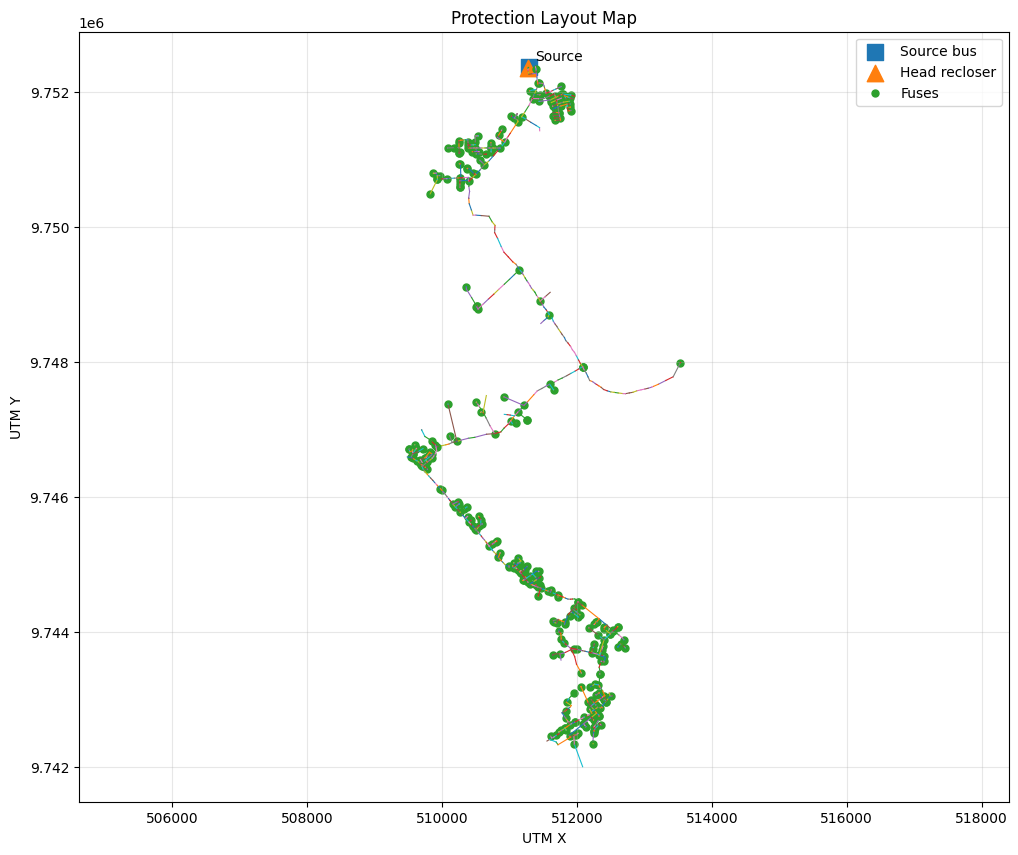

In [48]:
# ============================================================
# CELL 41 - PLOT 1: PROTECTION LAYOUT MAP
# ============================================================
# Shows:
# - MV feeder lines
# - head recloser
# - fuses
# - source bus
# ============================================================

import matplotlib.pyplot as plt

def plot_protection_layout(lines_xy_df, source_info, bus_coord_lookup, head_recloser_plot_df, fuse_plot_df):
    fig, ax = plt.subplots(figsize=(12, 10))

    # Base feeder lines
    for _, row in lines_xy_df.loc[lines_xy_df["has_coords"]].iterrows():
        ax.plot([row["x1"], row["x2"]], [row["y1"], row["y2"]], linewidth=0.8)

    # Source bus
    sx, sy = bus_coord_lookup.get(source_info["source_bus_base"], (np.nan, np.nan))
    if pd.notna(sx) and pd.notna(sy):
        ax.scatter([sx], [sy], s=120, marker="s", label="Source bus")
        ax.annotate("Source", (sx, sy), xytext=(5, 5), textcoords="offset points")

    # Head recloser
    if not head_recloser_plot_df.empty:
        ax.scatter(
            head_recloser_plot_df["x"], head_recloser_plot_df["y"],
            s=140, marker="^", label="Head recloser"
        )

    # Fuses
    if not fuse_plot_df.empty:
        ax.scatter(
            fuse_plot_df["x"], fuse_plot_df["y"],
            s=25, marker="o", label="Fuses"
        )

    ax.set_title("Protection Layout Map")
    ax.set_xlabel("UTM X")
    ax.set_ylabel("UTM Y")
    ax.axis("equal")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()


plot_protection_layout(
    lines_xy_df,
    source_info,
    bus_coord_lookup,
    head_recloser_plot_df,
    fuse_plot_df
)

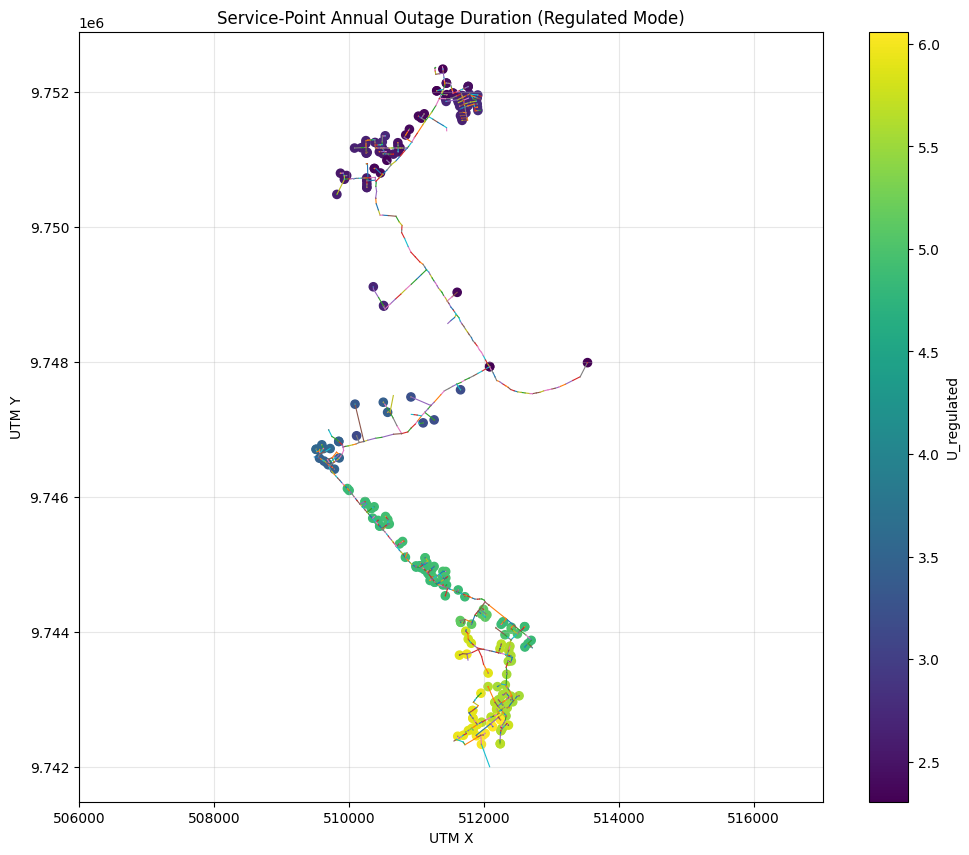

In [49]:
# ============================================================
# CELL 42 - PLOT 2: REGULATED ANNUAL OUTAGE DURATION MAP
# ============================================================
# Plots service points colored by U_regulated (hours/year).
# ============================================================

def plot_service_point_metric(lines_xy_df, sp_plot_df, metric_col, title):
    fig, ax = plt.subplots(figsize=(12, 10))

    # Base feeder
    for _, row in lines_xy_df.loc[lines_xy_df["has_coords"]].iterrows():
        ax.plot([row["x1"], row["x2"]], [row["y1"], row["y2"]], linewidth=0.8)

    df = sp_plot_df.loc[sp_plot_df["has_coords"] & sp_plot_df[metric_col].notna()].copy()

    sc = ax.scatter(
        df["x"], df["y"],
        s=35,
        c=df[metric_col]
    )

    ax.set_title(title)
    ax.set_xlabel("UTM X")
    ax.set_ylabel("UTM Y")
    ax.axis("equal")
    ax.grid(True, alpha=0.3)
    plt.colorbar(sc, ax=ax, label=metric_col)
    plt.show()


plot_service_point_metric(
    lines_xy_df,
    service_point_plot_df,
    metric_col="U_regulated",
    title="Service-Point Annual Outage Duration (Regulated Mode)"
)

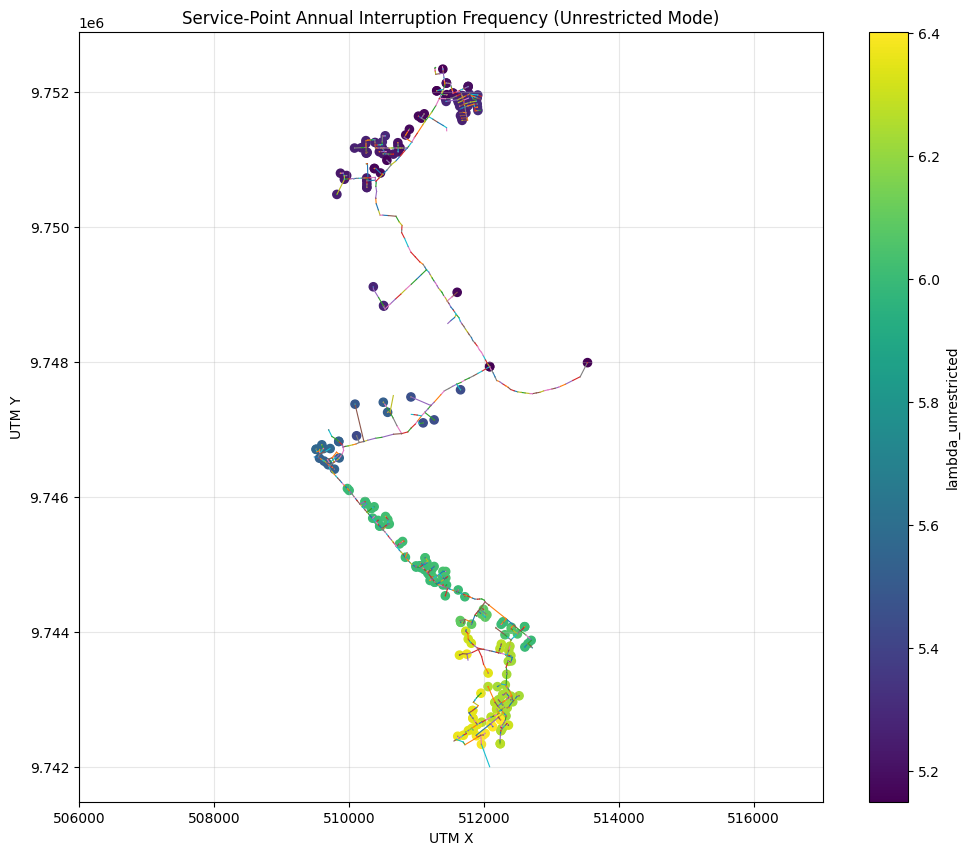

In [50]:
# ============================================================
# CELL 43 - PLOT 3: UNRESTRICTED ANNUAL INTERRUPTION FREQUENCY
# ============================================================
# Plots service points colored by lambda_unrestricted.
# ============================================================

plot_service_point_metric(
    lines_xy_df,
    service_point_plot_df,
    metric_col="lambda_unrestricted",
    title="Service-Point Annual Interruption Frequency (Unrestricted Mode)"
)

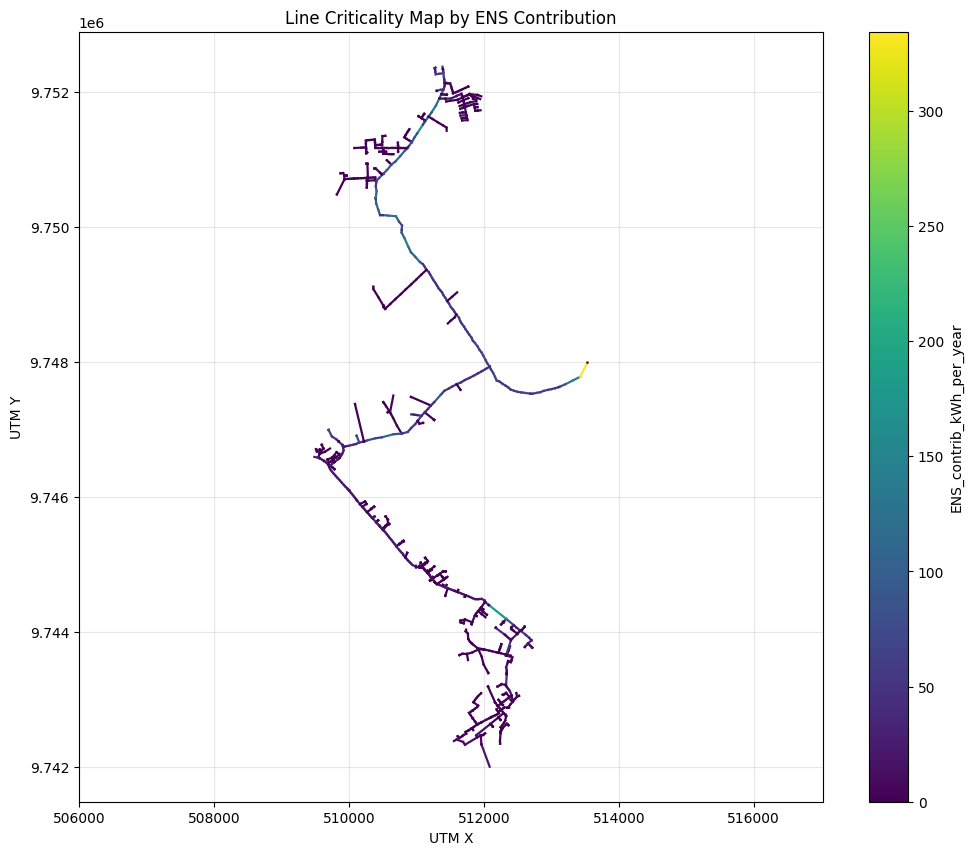

In [51]:
# ============================================================
# CELL 44 - PLOT 4: LINE CRITICALITY MAP BY ENS CONTRIBUTION
# ============================================================
# Colors line segments by annual ENS contribution.
# This is one of the most useful engineering plots because it
# shows which line sections matter most to reliability.
# ============================================================

def plot_line_metric(lines_metric_df, metric_col, title):
    fig, ax = plt.subplots(figsize=(12, 10))

    df = lines_metric_df.loc[lines_metric_df["has_coords"]].copy()

    values = df[metric_col].fillna(0.0).values

    # Avoid division by zero if everything is zero
    vmin = np.nanmin(values) if len(values) > 0 else 0.0
    vmax = np.nanmax(values) if len(values) > 0 else 1.0
    if vmax == vmin:
        vmax = vmin + 1.0

    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.viridis

    for _, row in df.iterrows():
        val = row[metric_col] if pd.notna(row[metric_col]) else 0.0
        ax.plot(
            [row["x1"], row["x2"]],
            [row["y1"], row["y2"]],
            linewidth=1.6,
            color=cmap(norm(val))
        )

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    ax.set_title(title)
    ax.set_xlabel("UTM X")
    ax.set_ylabel("UTM Y")
    ax.axis("equal")
    ax.grid(True, alpha=0.3)
    plt.colorbar(sm, ax=ax, label=metric_col)
    plt.show()


plot_line_metric(
    line_criticality_df,
    metric_col="ENS_contrib_kWh_per_year",
    title="Line Criticality Map by ENS Contribution"
)

### EXPLANATION OF RESULTS

1. Synthetic log vs analytical model

Classical method (what textbooks do): compute component failure rates $\lambda$, impact zones, and then derive: SAIFI, SAIDI, etc.

Regulatory method (what utilities report): We observe events: each interruption has location, duration, affected load/customers, and then, we compute FMIK, TTIK directly from logs.

We are generating a synthetic event log: each row in `event_impact_df` is effectively complying with the idea that “This type of failure occurs with frequency $\lambda_e$, and when it happens, it produces this impact.”

So instead of: observed events over a year, we have: expected events over a year.

2. Mathematical equivalence (key point)

Real logbook (utility reality): Over one year, suppose we observe events $e\in E$, so:
$$
\mathrm{FMIK}=\frac{\sum_{e\in E}{\mathrm{Interrupted\ kVA}}_e}{\mathrm{Total\ installed\ kVA}}
$$
$$
TTIK:
\mathrm{TTIK}=\frac{\sum_{e\in E}{\mathrm{Duration}}_e\cdot{\mathrm{Interrupted\ kVA}}_e}{\mathrm{Total\ installed\ kVA}}
$$

Analytical model: We do not have actual events. Instead, each event type $e$ has annual rate \lambda_e, impact P_e(kVA), duration t_e. So the expected annual contribution is:
$$
\mathrm{FMIK}=\sum_{e}\lambda_e\cdot\frac{P_e}{P_{\mathrm{total}}}
$$
$$
\mathrm{TTIK}=\sum_{e}\lambda_e\cdot t_e\cdot\frac{P_e}{P_{\mathrm{total}}}
$$

We are replacing “sum over observed events”, with “expected sum over events weighted by their probability”. This is exactly the same structure, just in expectation.

3. Why this ensures consistency with SAIFI/SAIDI

How do we know FMIK/TTIK relate consistently to SAIFI/SAIDI? Because both are derived from the same event set. In our model, every event $e$ contributes to customer-based indices:

* $SAIFI → \lambda_e\cdot N_e$,
* $SAIDI → \lambda_e\cdot t_e\cdot N_e$,

and to energy/power-based indices:

* $FMIK → \lambda_e\cdot P_e$,
* $TTIK → \lambda_e\cdot t_e\cdot P_e$

Then, same events → different weights.

Index type |    Weighting variable

SAIFI / SAIDI	|   number of customers

FMIK / TTIK	 | installed kVA

ENS	| connected kW

So, the relationship between indices is not arbitrary—it is driven by how each event is weighted.

4. What guarantees consistency in this notebook

This model enforces consistency because it is the same event universe (all indices use: `event_impact_df`), same failure rates (all events are generated from `failure_rate_per_year`) and use the same topology and protection logic. Then the impact zones are identical for SAIFI, SAIDI, FMIK, TTIK, ENS.

5. Inconsistency could appear

In real systems, inconsistencies arise when: a) logs vs models differ, logs include switching errors, human actions, model includes only component failures, b) weighting mismatch, customer counts can be inaccurate, transformer kVA database can be incomplete, c) filtering differences, FMIK/TTIK exclude short events, SAIFI includes them.

This notebook explicitly controls this via: `count_in_regulation`, `count_in_unrestricted`, brief interruption flag, so, indices differ not because physics is different, but because counting rules differ.

We can state that FMIK/TTIK and SAIFI/SAIDI are not fundamentally different metrics. They are projections of the same interruption process onto different weighting spaces:

* customers onto SAIFI/SAIDI
*	installed capacity onto FMIK/TTIK
*	energy onto ENS

In this study, the absence of a historical interruption log is addressed by constructing a synthetic event log derived from component failure rates, feeder topology, and protection coordination. Each modeled event represents an expected annual occurrence with an associated frequency, duration, and affected load.

This synthetic event set is then used consistently across all reliability indices. Classical indices (SAIFI, SAIDI, CAIFI, CAIDI) are obtained by weighting events according to affected customers, while regulatory indices (FMIK, TTIK) are obtained by weighting the same events according to interrupted installed transformer capacity.

As a result, all indices are internally consistent and represent different perspectives of the same underlying stochastic interruption process.

6. Conclusion

How are we sure FMIK/TTIK relate to SAIFI/SAIDI with the data we have?
Because we are not mixing methods, we are using a single coherent stochastic event model, and projecting it onto customers (SAIFI/SAIDI), capacity (FMIK/TTIK), and energy (ENS).  So the relationship is guaranteed by construction.
